# IRBF

## Imports, Definitions, and loading data

In [43]:
## Critical Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import cmasher as cmr

import scipy.constants as const
from scipy.stats import norm
import pandas as pd
from matplotlib.ticker import MultipleLocator, ScalarFormatter
from scipy.signal import find_peaks
from itertools import cycle

# Nested Sampling
import dynesty
import corner
import pickle
import os

#Aesthetics
import matplotlib as mpl
plt.style.use('style.mplstyle')

# My stuff
from TeraToptica import TeraFlashAnalyzer as TFA, TeraFlashConfig as TFC
from TeraToptica import TeraScanAnalyzer as TSA, TeraScanConfig as TSC

window = 'gaussian' # Smoothing window type in frequency domain
window_size  = 15 # Determines how many GHz to smooth the spectrum over (upper bound)

mask_bounds = (
              (0, 150), # mask low frequency HD30_batch2
              (545, 570), (740, 770), (1080, 1245), (1390, 1430), # mask waterlines
              (1585, 1810), (1855, 1950),
            #   (2025, 2075), (2100, 2275), (2325, 2500), (2600, 3000),
              (2000, 10000)
              )

f = np.arange(5, 2000.1, 1)

batches = {}

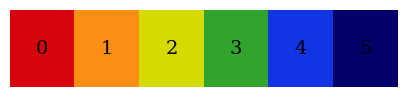

In [44]:
from cmap import Colormap
cmap = Colormap('colorcet:CET_R4')
cmap_array = cmap(np.linspace(0, 1, 256))[::-1]

entries = 6
indices = np.linspace(0, len(cmap_array)-1, entries).astype(int)
colors2 = cmap_array[indices]

# Display for visualization
large_font = 14  # font size for labels
plt.figure(figsize=(5, 1))
plt.imshow([colors2], aspect='auto')

for i in range(len(colors2)):  # one less because we skipped first color
    plt.annotate(i, (i, 0), color='k', fontsize=large_font, ha='center', va='center')

plt.gca().set_axis_off()

# =========================
# Colormap infrastructure
# =========================

# HD30 default colormaps (Batch1, Batch2, Batch3)
def apply_cmap(bname, cmap, lo=0.4, hi=0.85, mean_pos=0.6):
    sample_dict = batches[bname]

    keys = list(sample_dict.keys())
    cols = cmap(np.linspace(lo, hi, len(keys)))
    cols = cols[::-1]

    for s, c in zip(keys, cols):
        sample_dict[s]["color"] = c

In [45]:
from matplotlib.colors import to_rgb
import colorsys

# Linearly steps through value, works best with high saturation colors
def get_colors(N, stop_color, start_v=1, stop_v=0.5):
    r, g, b = to_rgb(stop_color)
    h, s, _ = colorsys.rgb_to_hsv(r, g, b)

    v_values = np.linspace(start_v, stop_v, N)
    colors = [colorsys.hsv_to_rgb(h, s, v) for v in v_values]
    return np.array(colors)

### Styrofoam batch
Now includes samples previously fielded in SO SATp2

In [46]:
tf_cfg = TFC(
    window=window,
    window_size=window_size,
    mask_bounds=mask_bounds,
    layout='reference_included'
)

tf_cfg2 = TFC(
    window=window,
    window_size=window_size,
    mask_bounds=mask_bounds,
    layout='separate_files'
)

#These were NOT cycled in a vacuum chamber

path = './data/20260630/' #Check the repeatability of the thin styrofoams

styro_1o4mm = TFA(path, 'styro_satp2_1o4mm_1800-2000ps_100avgs', config=tf_cfg)
styro_3o0mm = TFA(path, 'styro_satp2_3o0mm_1800-2000ps_100avgs', config=tf_cfg)
styro_5o8mm = TFA(path, 'styro_satp2_5o8mm_1800-2000ps_100avgs', config=tf_cfg)
styro_6o1mm = TFA(path, 'styro_ucsd_6o1mm_1800-2000ps_100avgs', config=tf_cfg)
styro_16o2mm = TFA(path, 'styro_satp2_16o2mm_1800-2000ps_100avgs', config=tf_cfg)
styro_42o3mm = TFA(path, 'styro_ucsd_42o3mm_1800-2000ps_100avgs', config=tf_cfg)


## Frequency domain data for Styrofoam

f_1o4mm,  t_1o4mm,  ut_1o4mm,  mask_1o4mm,  err_1o4mm,  boxnum_1o4mm  = styro_1o4mm.get_smoothed_spectra()
f_3o0mm,  t_3o0mm,  ut_3o0mm,  mask_3o0mm,  err_3o0mm,  boxnum_3o0mm  = styro_3o0mm.get_smoothed_spectra()
f_5o8mm,  t_5o8mm,  ut_5o8mm,  mask_5o8mm,  err_5o8mm,  boxnum_5o8mm  = styro_5o8mm.get_smoothed_spectra()
f_6o1mm,  t_6o1mm,  ut_6o1mm,  mask_6o1mm,  err_6o1mm,  boxnum_6o1mm  = styro_6o1mm.get_smoothed_spectra()
f_16o2mm, t_16o2mm, ut_16o2mm, mask_16o2mm, err_16o2mm, boxnum_16o2mm = styro_16o2mm.get_smoothed_spectra()
f_42o3mm, t_42o3mm, ut_42o3mm, mask_42o3mm, err_42o3mm, boxnum_42o3mm = styro_42o3mm.get_smoothed_spectra()

## Time domain data for Styrofoam
T_1o4mm,  pc_1o4mm  = styro_1o4mm.get_sample_pulse()
T_3o0mm,  pc_3o0mm  = styro_3o0mm.get_sample_pulse()
T_5o8mm,  pc_5o8mm  = styro_5o8mm.get_sample_pulse()
T_6o1mm,  pc_6o1mm  = styro_6o1mm.get_sample_pulse()
T_16o2mm, pc_16o2mm = styro_16o2mm.get_sample_pulse()
T_42o3mm, pc_42o3mm = styro_42o3mm.get_sample_pulse()

# Phase data for Styrofoam
theta_1o4mm,  theta_base_1o4mm  = styro_1o4mm.get_phases()
theta_3o0mm,  theta_base_3o0mm  = styro_3o0mm.get_phases()
theta_5o8mm,  theta_base_5o8mm  = styro_5o8mm.get_phases()
theta_6o1mm,  theta_base_6o1mm  = styro_6o1mm.get_phases()
theta_16o2mm, theta_base_16o2mm = styro_16o2mm.get_phases()
theta_42o3mm, theta_base_42o3mm = styro_42o3mm.get_phases()

Styrofoam_batch = {}

Styrofoam_batch["Styrofoam 0.14 cm"] = {'f': f_1o4mm,  't': t_1o4mm,  'ut': ut_1o4mm,  'mask': mask_1o4mm,  'err': err_1o4mm,  'boxnum': boxnum_1o4mm,  'T': T_1o4mm,  'pc': pc_1o4mm,  'theta': theta_1o4mm,  'theta_base': theta_base_1o4mm,  'width': 0.14}
Styrofoam_batch["Styrofoam 0.30 cm"] = {'f': f_3o0mm,  't': t_3o0mm,  'ut': ut_3o0mm,  'mask': mask_3o0mm,  'err': err_3o0mm,  'boxnum': boxnum_3o0mm,  'T': T_3o0mm,  'pc': pc_3o0mm,  'theta': theta_3o0mm,  'theta_base': theta_base_3o0mm,  'width': 0.30}
Styrofoam_batch["Styrofoam 0.58 cm"] = {'f': f_5o8mm,  't': t_5o8mm,  'ut': ut_5o8mm,  'mask': mask_5o8mm,  'err': err_5o8mm,  'boxnum': boxnum_5o8mm,  'T': T_5o8mm,  'pc': pc_5o8mm,  'theta': theta_5o8mm,  'theta_base': theta_base_5o8mm,  'width': 0.58}
Styrofoam_batch["Styrofoam 0.61 cm"] = {'f': f_6o1mm,  't': t_6o1mm,  'ut': ut_6o1mm,  'mask': mask_6o1mm,  'err': err_6o1mm,  'boxnum': boxnum_6o1mm,  'T': T_6o1mm,  'pc': pc_6o1mm,  'theta': theta_6o1mm,  'theta_base': theta_base_6o1mm,  'width': 0.61}
Styrofoam_batch["Styrofoam 1.62 cm"] = {'f': f_16o2mm, 't': t_16o2mm, 'ut': ut_16o2mm, 'mask': mask_16o2mm, 'err': err_16o2mm, 'boxnum': boxnum_16o2mm, 'T': T_16o2mm, 'pc': pc_16o2mm, 'theta': theta_16o2mm, 'theta_base': theta_base_16o2mm, 'width': 1.62}
Styrofoam_batch["Styrofoam 4.23 cm"] = {'f': f_42o3mm, 't': t_42o3mm, 'ut': ut_42o3mm, 'mask': mask_42o3mm, 'err': err_42o3mm, 'boxnum': boxnum_42o3mm, 'T': T_42o3mm, 'pc': pc_42o3mm, 'theta': theta_42o3mm, 'theta_base': theta_base_42o3mm, 'width': 4.23}

batches['Styrofoam_batch'] = Styrofoam_batch

### HD30_batch1

In [47]:
# TeraFlashAnalyzer Instances for HD30_batch1
path = './data/20251216/'
penn_3o47mm    = TFA(path, 'HD30_1x0o125in_3o47mm_penn_1675-1875ps_100avgs', config=tf_cfg)

path = './data/20260212'
penn_6o51mm  = TFA(path, 'hd30_penn_6o51mm_1400-1600ps_100avgs', config=tf_cfg) # 2x1/8"
penn_27o6mm  = TFA(path, 'hd30_penn_27o60mm_1400-1600ps_100avgs', config=tf_cfg) # 8x1/8"
penn_30o94mm = TFA(path, 'hd30_penn_30o94mm_1400-1600ps_100avgs', config=tf_cfg) # 10x1/8

# Frequency domain data for HD30_batch1
f_3o47mm,  t_3o47mm,  ut_3o47mm,  mask_3o47mm,  err_3o47mm,  boxnum_3o47mm  = penn_3o47mm.get_smoothed_spectra()
f_6o51mm,  t_6o51mm,  ut_6o51mm,  mask_6o51mm,  err_6o51mm,  boxnum_6o51mm  = penn_6o51mm.get_smoothed_spectra()
f_27o6mm,  t_27o6mm,  ut_27o6mm,  mask_27o6mm,  err_27o6mm,  boxnum_27o6mm  = penn_27o6mm.get_smoothed_spectra()
f_30o94mm, t_30o94mm, ut_30o94mm, mask_30o94mm, err_30o94mm, boxnum_30o94mm = penn_30o94mm.get_smoothed_spectra()

# Time domain data for HD30_batch1
T_3o47mm,  pc_3o47mm  = penn_3o47mm.get_sample_pulse()
T_6o51mm,  pc_6o51mm  = penn_6o51mm.get_sample_pulse()
T_27o6mm,  pc_27o6mm  = penn_27o6mm.get_sample_pulse()
T_30o94mm, pc_30o94mm = penn_30o94mm.get_sample_pulse()

# Phase data for HD30_batch1
theta_3o47mm,  theta_base_3o47mm  = penn_3o47mm.get_phases()
theta_6o51mm,  theta_base_6o51mm  = penn_6o51mm.get_phases()
theta_27o6mm,  theta_base_27o6mm  = penn_27o6mm.get_phases()
theta_30o94mm, theta_base_30o94mm = penn_30o94mm.get_phases()

HD30_batch1 = {}
HD30_batch1['HD30 batch1 0.35 cm'] = {'f': f_3o47mm,  't': t_3o47mm,  'ut': ut_3o47mm,  'mask': mask_3o47mm,  'err': err_3o47mm,  'boxnum': boxnum_3o47mm,  'T': T_3o47mm,  'pc': pc_3o47mm,  'theta_base': theta_base_3o47mm,  'theta': theta_3o47mm,  'width': 0.347}
HD30_batch1['HD30 batch1 0.65 cm'] = {'f': f_6o51mm,  't': t_6o51mm,  'ut': ut_6o51mm,  'mask': mask_6o51mm,  'err': err_6o51mm,  'boxnum': boxnum_6o51mm,  'T': T_6o51mm,  'pc': pc_6o51mm,  'theta_base': theta_base_6o51mm,  'theta': theta_6o51mm,  'width': 0.651}
HD30_batch1['HD30 batch1 2.76 cm'] = {'f': f_27o6mm,  't': t_27o6mm,  'ut': ut_27o6mm,  'mask': mask_27o6mm,  'err': err_27o6mm,  'boxnum': boxnum_27o6mm,  'T': T_27o6mm,  'pc': pc_27o6mm,  'theta_base': theta_base_27o6mm,  'theta': theta_27o6mm,  'width': 2.76}
HD30_batch1['HD30 batch1 3.09 cm'] = {'f': f_30o94mm, 't': t_30o94mm, 'ut': ut_30o94mm, 'mask': mask_30o94mm, 'err': err_30o94mm, 'boxnum': boxnum_30o94mm, 'T': T_30o94mm, 'pc': pc_30o94mm, 'theta_base': theta_base_30o94mm, 'theta': theta_30o94mm, 'width': 3.094}

batches['HD30_batch1'] = HD30_batch1

### HD30_batch2

In [48]:
path = './data/20251216/'

## TeraFlashAnalyzer Instances for HD30_batch2
cornell_3o65mm = TFA(path, 'hd30_1x0o125in_3o65mm_cornell_1675-1875ps_100avgs', config = tf_cfg)
cornell_7o3mm  = TFA(path, 'hd30_2x0o125in_7o3mm_cornell_1675-1875ps_100avgs',  config = tf_cfg)
cornell_25o4mm = TFA(path, 'hd30_1x1in_25o4mm_cornell2_1675-1875ps_100avgs',    config = tf_cfg)

## Frequency domain data for HD30_batch2
f_3o65mm, t_3o65mm,  ut_3o65mm,  mask_3o65mm,  err_3o65mm,  boxnum_3o65mm  = cornell_3o65mm.get_smoothed_spectra()
f_7o3mm,  t_7o3mm,   ut_7o3mm,   mask_7o3mm,   err_7o3mm,   boxnum_7o3mm   = cornell_7o3mm.get_smoothed_spectra()
f_25o4mm, t_25o4mm,  ut_25o4mm,  mask_25o4mm,  err_25o4mm,  boxnum_25o4mm  = cornell_25o4mm.get_smoothed_spectra()

## Time domain data for HD30_batch2
T_3o65mm,  pc_3o65mm  = cornell_3o65mm.get_sample_pulse()
T_7o3mm,   pc_7o3mm   = cornell_7o3mm.get_sample_pulse()
T_25o4mm,  pc_25o4mm  = cornell_25o4mm.get_sample_pulse()

## Phase data for HD30_batch2
theta_3o65mm, theta_base_3o65mm = cornell_3o65mm.get_phases()
theta_7o3mm,  theta_base_7o3mm  = cornell_7o3mm.get_phases()
theta_25o4mm, theta_base_25o4mm = cornell_25o4mm.get_phases()

HD30_batch2 = {}

HD30_batch2['HD30 batch2 0.37 cm'] = {'f': f_3o65mm, 't': t_3o65mm, 'ut': ut_3o65mm, 'mask': mask_3o65mm, 'err': err_3o65mm, 'boxnum': boxnum_3o65mm, 'T': T_3o65mm, 'pc': pc_3o65mm, 'theta_base': theta_base_3o65mm, 'theta': theta_3o65mm, 'width': 0.365}
HD30_batch2['HD30 batch2 0.73 cm'] = {'f': f_7o3mm,  't': t_7o3mm,  'ut': ut_7o3mm,  'mask': mask_7o3mm,  'err': err_7o3mm,  'boxnum': boxnum_7o3mm,  'T': T_7o3mm,  'pc': pc_7o3mm,  'theta_base': theta_base_7o3mm,  'theta': theta_7o3mm,  'width': 0.73}
HD30_batch2['HD30 batch2 2.54 cm'] = {'f': f_25o4mm, 't': t_25o4mm, 'ut': ut_25o4mm, 'mask': mask_25o4mm, 'err': err_25o4mm, 'boxnum': boxnum_25o4mm, 'T': T_25o4mm, 'pc': pc_25o4mm, 'theta_base': theta_base_25o4mm, 'theta': theta_25o4mm, 'width': 2.54}

batches['HD30_batch2'] = HD30_batch2

### HD30_batch3
Deployed for ASO

In [49]:
path = './data/20251216/'

site_3o58mm    = TFA(path, 'HD30_1x0o125in_3o58mm_site_1675-1875ps_100avgs',  config=tf_cfg)
site_7o18mm    = TFA(path, 'HD30_2x0o125in_7o18mm_site_1675-1875ps_100avgs',  config=tf_cfg)
site_10o86mm   = TFA(path, 'HD30_3x0o125in_10o86mm_site_1675-1875ps_100avgs', config=tf_cfg)
site_25o4mm    = TFA(path, 'HD30_1x1in_25o4mm_site_1675-1875ps_100avgs',      config=tf_cfg)
site_50o9mm    = TFA(path, 'HD30_2x1in_50o9mm_site_1675-1875ps_100avgs',      config=tf_cfg)

## Frequency domain data for HD30_batch3 
f_3o58mm,  t_3o58mm,  ut_3o58mm,  mask_3o58mm,  err_3o58mm,  boxnum_3o58mm  = site_3o58mm.get_smoothed_spectra()
f_7o18mm,  t_7o18mm,  ut_7o18mm,  mask_7o18mm,  err_7o18mm,  boxnum_7o18mm  = site_7o18mm.get_smoothed_spectra()
f_10o86mm, t_10o86mm, ut_10o86mm, mask_10o86mm, err_10o86mm, boxnum_10o86mm = site_10o86mm.get_smoothed_spectra()
f_25o4mm,  t_25o4mm,  ut_25o4mm,  mask_25o4mm,  err_25o4mm,  boxnum_25o4mm  = site_25o4mm.get_smoothed_spectra()
f_50o9mm,  t_50o9mm,  ut_50o9mm,  mask_50o9mm,  err_50o9mm,  boxnum_50o9mm  = site_50o9mm.get_smoothed_spectra()

## Time domain data for HD30_batch3 
T_3o58mm,  pc_3o58mm  = site_3o58mm.get_sample_pulse()
T_7o18mm,  pc_7o18mm  = site_7o18mm.get_sample_pulse()
T_10o86mm, pc_10o86mm = site_10o86mm.get_sample_pulse()
T_25o4mm,  pc_25o4mm  = site_25o4mm.get_sample_pulse()
T_50o9mm,  pc_50o9mm  = site_50o9mm.get_sample_pulse()

# Phase HD30_batch3
theta_3o58mm, theta_base_3o58mm   = site_3o58mm.get_phases()
theta_7o18mm, theta_base_7o18mm   = site_7o18mm.get_phases()
theta_10o86mm, theta_base_10o86mm = site_10o86mm.get_phases()
theta_25o4mm, theta_base_25o4mm   = site_25o4mm.get_phases()
theta_50o9mm, theta_base_50o9mm   = site_50o9mm.get_phases()

HD30_batch3 = {}

HD30_batch3['HD30 batch3 0.36 cm'] = {'f': f_3o58mm,  't': t_3o58mm,  'ut': ut_3o58mm,  'mask': mask_3o58mm,  'err': err_3o58mm,  'boxnum': boxnum_3o58mm,  'T': T_3o58mm,  'pc': pc_3o58mm,  'theta': theta_3o58mm,  'theta_base': theta_base_3o58mm,  'width': 0.358}
HD30_batch3['HD30 batch3 0.72 cm'] = {'f': f_7o18mm,  't': t_7o18mm,  'ut': ut_7o18mm,  'mask': mask_7o18mm,  'err': err_7o18mm,  'boxnum': boxnum_7o18mm,  'T': T_7o18mm,  'pc': pc_7o18mm,  'theta': theta_7o18mm,  'theta_base': theta_base_7o18mm,  'width': 0.718}
HD30_batch3['HD30 batch3 1.09 cm'] = {'f': f_10o86mm, 't': t_10o86mm, 'ut': ut_10o86mm, 'mask': mask_10o86mm, 'err': err_10o86mm, 'boxnum': boxnum_10o86mm, 'T': T_10o86mm, 'pc': pc_10o86mm, 'theta': theta_10o86mm, 'theta_base': theta_base_10o86mm, 'width': 1.086}
HD30_batch3['HD30 batch3 2.54 cm'] = {'f': f_25o4mm,  't': t_25o4mm,  'ut': ut_25o4mm,  'mask': mask_25o4mm,  'err': err_25o4mm,  'boxnum': boxnum_25o4mm,  'T': T_25o4mm,  'pc': pc_25o4mm,  'theta': theta_25o4mm,  'theta_base': theta_base_25o4mm,  'width': 2.54}
HD30_batch3['HD30 batch3 5.09 cm'] = {'f': f_50o9mm,  't': t_50o9mm,  'ut': ut_50o9mm,  'mask': mask_50o9mm,  'err': err_50o9mm,  'boxnum': boxnum_50o9mm,  'T': T_50o9mm,  'pc': pc_50o9mm,  'theta': theta_50o9mm,  'theta_base': theta_base_50o9mm,  'width': 5.09}

batches['HD30_batch3'] = HD30_batch3

### Alternative Zotefoams

In [50]:
path = './data/20251117/' #Path to the data directory

# Mask diffuse scatter regions in HD foams
mask_bounds_HD80 = ((0, 150), (545, 570), (740, 770), (1080, 1245), (1390, 10000))
mask_bounds_HD110 = ((0, 150), (500, 10000))

tf_cfg_HD80  = TFC(window=window, window_size=window_size, mask_bounds=mask_bounds_HD80,  layout='reference_included')
tf_cfg_HD110 = TFC(window=window, window_size=window_size, mask_bounds=mask_bounds_HD110, layout='reference_included')

LD15_1in  = TFA(path, 'LD15_1590-1790ps_1000avgs',  config=tf_cfg)
LD24_1in  = TFA(path, 'LD24_1590-1790ps_1000avgs',  config=tf_cfg)
HD80_1in  = TFA(path, 'HD80_1590-1790ps_1000avgs',  config=tf_cfg_HD80)
HD110_1in = TFA(path, 'HD110_1590-1790ps_1000avgs', config=tf_cfg_HD110)

path = './data/cornell/'

# We use a legacy TeraScan measurement for HD60, HD60 was firmly rejected before the TeraFlash was installed.
HD60_1in  = TSA(path,   
                'TestData_2050225_Zotefoam_HD60_0p8in_300K_Sample_100to1000GHz_Step200MHz_Scan_0001.dat',  
                'TestData_2050225_Zotefoam_HD60_0p8in_300K_ClrBg_100to1000GHz_Step200MHz_Scan_0001.dat',
                config=TSC(window=window, window_size=window_size, mask_bounds=mask_bounds, fiber_stretcher=True))

path = './data/20260612/'

LD15_ucsd_3o0mm = TFA(path, 'LD15_ucsd_1850-2050ps_100avgs', config=tf_cfg)
LD24_ucsd_3o4mm = TFA(path, 'LD24_ucsd_1850-2050ps_100avgs', config=tf_cfg)

## Frequency-domain data
f_LD15,      t_LD15,      ut_LD15,      mask_LD15,      err_LD15,      boxnum_LD15     = LD15_1in.get_smoothed_spectra()
f_LD24,      t_LD24,      ut_LD24,      mask_LD24,      err_LD24,      boxnum_LD24     = LD24_1in.get_smoothed_spectra()
f_HD60,      t_HD60,      ut_HD60,      mask_HD60,      err_HD60,      boxnum_HD60     = HD60_1in.get_smoothed_spectra()
f_HD80,      t_HD80,      ut_HD80,      mask_HD80,      err_HD80,      boxnum_HD80     = HD80_1in.get_smoothed_spectra()
f_HD110,     t_HD110,     ut_HD110,     mask_HD110,     err_HD110,     boxnum_HD110    = HD110_1in.get_smoothed_spectra()
f_LD15_ucsd, t_LD15_ucsd, ut_LD15_ucsd, mask_LD15_ucsd, err_LD15_ucsd, boxnum_LD15_ucsd = LD15_ucsd_3o0mm.get_smoothed_spectra()
f_LD24_ucsd, t_LD24_ucsd, ut_LD24_ucsd, mask_LD24_ucsd, err_LD24_ucsd, boxnum_LD24_ucsd = LD24_ucsd_3o4mm.get_smoothed_spectra()

## Time-domain data
T_LD15,     pc_LD15       = LD15_1in.get_sample_pulse()
T_LD24,     pc_LD24       = LD24_1in.get_sample_pulse()
T_HD80,     pc_HD80       = HD80_1in.get_sample_pulse()
T_HD110,    pc_HD110      = HD110_1in.get_sample_pulse()
T_LD15_ucsd, pc_LD15_ucsd = LD15_ucsd_3o0mm.get_sample_pulse()
T_LD24_ucsd, pc_LD24_ucsd = LD24_ucsd_3o4mm.get_sample_pulse()

##Phase data
theta_LD15,  theta_base_LD15  = LD15_1in.get_phases()
theta_LD24,  theta_base_LD24  = LD24_1in.get_phases()
theta_HD60,  theta_base_HD60  = HD60_1in.get_phases()
theta_HD80,  theta_base_HD80  = HD80_1in.get_phases()
theta_HD110, theta_base_HD110 = HD110_1in.get_phases()
theta_LD15_ucsd, theta_base_LD15_ucsd = LD15_ucsd_3o0mm.get_phases()
theta_LD24_ucsd, theta_base_LD24_ucsd = LD24_ucsd_3o4mm.get_phases()

## ACTIVE DATA DICTIONARY

other_zote_batches = {}

other_zote_batches['LD15 batch1 2.65 cm'] = {'f': f_LD15,      't': t_LD15,      'ut': ut_LD15,      'mask': mask_LD15,      'err': err_LD15,      'boxnum': boxnum_LD15,      'T': T_LD15,      'pc': pc_LD15,       'theta_base': theta_base_LD15,       'theta': theta_LD15,       'width': 2.65, 'color': colors2[0]}
other_zote_batches['LD15 batch2 0.30 cm'] = {'f': f_LD15_ucsd, 't': t_LD15_ucsd, 'ut': ut_LD15_ucsd, 'mask': mask_LD15_ucsd, 'err': err_LD15_ucsd, 'boxnum': boxnum_LD15_ucsd, 'T': T_LD15_ucsd,  'pc': pc_LD15_ucsd, 'theta_base': theta_base_LD15_ucsd,  'theta': theta_LD15_ucsd,  'width': 0.30, 'color': colors2[1]}
other_zote_batches['LD24 batch1 2.60 cm'] = {'f': f_LD24,      't': t_LD24,      'ut': ut_LD24,      'mask': mask_LD24,      'err': err_LD24,      'boxnum': boxnum_LD24,      'T': T_LD24,      'pc': pc_LD24,       'theta_base': theta_base_LD24,       'theta': theta_LD24,       'width': 2.60, 'color': colors2[2]}
other_zote_batches['LD24 batch2 0.34 cm'] = {'f': f_LD24_ucsd, 't': t_LD24_ucsd, 'ut': ut_LD24_ucsd, 'mask': mask_LD24_ucsd, 'err': err_LD24_ucsd, 'boxnum': boxnum_LD24_ucsd, 'T': T_LD24_ucsd,  'pc': pc_LD24_ucsd, 'theta_base': theta_base_LD24_ucsd,  'theta': theta_LD24_ucsd,  'width': 0.34, 'color': colors2[3]}
# other_zote_batches['HD60 2.03 cm']        = {'f': f_HD60,      't': t_HD60,      'ut': ut_HD60,      'mask': mask_HD60,      'err': err_HD60,      'boxnum': boxnum_HD60,      'T': None,        'pc': None,          'theta_base': theta_base_HD60,       'theta': theta_HD60,       'width': 2.03, 'color': 'magenta'}
other_zote_batches['HD80 2.58 cm']        = {'f': f_HD80,      't': t_HD80,      'ut': ut_HD80,      'mask': mask_HD80,      'err': err_HD80,      'boxnum': boxnum_HD80,      'T': T_HD80,      'pc': pc_HD80,       'theta_base': theta_base_HD80,       'theta': theta_HD80,       'width': 2.58, 'color': colors2[4]}
other_zote_batches['HD110 2.08 cm']       = {'f': f_HD110,     't': t_HD110,     'ut': ut_HD110,     'mask': mask_HD110,     'err': err_HD110,     'boxnum': boxnum_HD110,     'T': T_HD110,     'pc': pc_HD110,      'theta_base': theta_base_HD110,      'theta': theta_HD110,      'width': 2.08, 'color': colors2[5]}

for name, data in other_zote_batches.items():
    batches[name] = {name: data}

In [51]:
## Sort batches into the ideal order for tables and for loops, useful late
def sort_key(name):
    is_styrofoam = name.startswith("Styrofoam")

    if is_styrofoam:
        group     = 0
        density   = 0 #NA
        batch_num = 0
    
    else:
        group = 1
        density = int(name.split()[0][2:].split("_")[0])
        if 'batch' in name:
            batch_num = int(name.split('batch')[1][0])
        else:
            batch_num = 0 #NA

    if 'cm' in name:
        width = float(name.split('cm')[0].split()[-1])
    else:
        width = 0 #NA

    return(group, density, batch_num, width)

# Sort everything
for batch_name, batch_data in batches.items():
    batches[batch_name] = dict(sorted(batch_data.items(), key=lambda kv: sort_key(kv[0])))

batches = dict(sorted(batches.items(), key=lambda kv: sort_key(kv[0])))

# Time Domain

In [52]:
batches.keys()

dict_keys(['Styrofoam_batch', 'LD15 batch1 2.65 cm', 'LD15 batch2 0.30 cm', 'LD24 batch1 2.60 cm', 'LD24 batch2 0.34 cm', 'HD30_batch1', 'HD30_batch2', 'HD30_batch3', 'HD80 2.58 cm', 'HD110 2.08 cm'])

In [53]:
## Initial processing
DISPLAY_MAP = {
    "Styrofoam_batch": "Styrofoam batch",
    "HD30_batch1": "HD30 batch 1",
    "HD30_batch2": "HD30 batch 2",
    "HD30_batch3": "HD30 batch 3",
    "LD15 batch1 2.65 cm": "LD15 batch 1",
    "LD15 batch2 0.30 cm": "LD15 batch 2",
    "LD24 batch1 2.60 cm": "LD24 batch 1",
    "LD24 batch2 0.34 cm": "LD24 batch 2",
    "HD60 2.03 cm": "HD60",
    "HD80 2.58 cm": "HD80",
    "HD110 2.08 cm": "HD110",
}

mask_starts = np.array((mask_bounds))[:,0]
mask_stops = np.array((mask_bounds))[:,1]

for bname, b in batches.items():
    for sample in b:
        b[sample]['t'] = np.where((b[sample]['t'] < 0), np.nan, b[sample]['t'])  # Set negative transmission values to zero
        b[sample]['ut'] = np.where((b[sample]['ut'] < 0), np.nan, b[sample]['ut'])  # Set negative transmission values to zero

        b[sample]['alpha'] = -np.log(b[sample]['t'])/b[sample]['width']                  # Calculate attenuation
        b[sample]['alpha_unsmoothed'] = -np.log(b[sample]['ut'])/(1/b[sample]['width'])  # Calculate attenuation without smoothing

        b[sample]['f_binned']  = b[sample]['f'][~b[sample]['mask']][::b[sample]['boxnum']]
        b[sample]['t_binned']  = b[sample]['t'][~b[sample]['mask']][::b[sample]['boxnum']]
        b[sample]['alpha_binned'] = b[sample]['alpha'][~b[sample]['mask']][::b[sample]['boxnum']]
        b[sample]['err_binned'] = b[sample]['err'][~b[sample]['mask']][::b[sample]['boxnum']]
        b[sample]['width_masked'] = np.tile(b[sample]['width'], (len(b[sample]['f'][~b[sample]['mask']]))) #repeat the width for each b point

        if 'HD' in bname or 'LD' in bname:
            zote_type = bname.split('_')[0].split(' ')[0]
            b[sample]['density'] = np.float64(zote_type[2:])
        else:
            b[sample]['density'] = 25 # kg/m^3 for Styrofoam

## Prevent double counting of b points by sampling every nth point

zote_cmaps = cycle([cmr.gothic, cmr.sunburst, cmr.toxic])
styro_cmaps = cycle([cmr.freeze]) # Add more if more Styrofoam batches are added

styro_batches = [bname for bname in batches.keys() if "Styrofoam_batch" in bname]

HD30_batches  = [bname for bname in batches.keys() if "HD30_batch" in bname]
zote_keys  = [k for k in batches.keys() if not k.startswith("Styrofoam")]
other_zote_keys = [k for k in batches.keys() if not k.startswith("Styrofoam") and not k.startswith("HD30")]

for bname, b in batches.items():
    if bname in HD30_batches:
        cmap = next(zote_cmaps)
        apply_cmap(bname, cmap)

    elif bname in styro_batches:
        cmap = next(styro_cmaps)
        apply_cmap(bname, cmap)


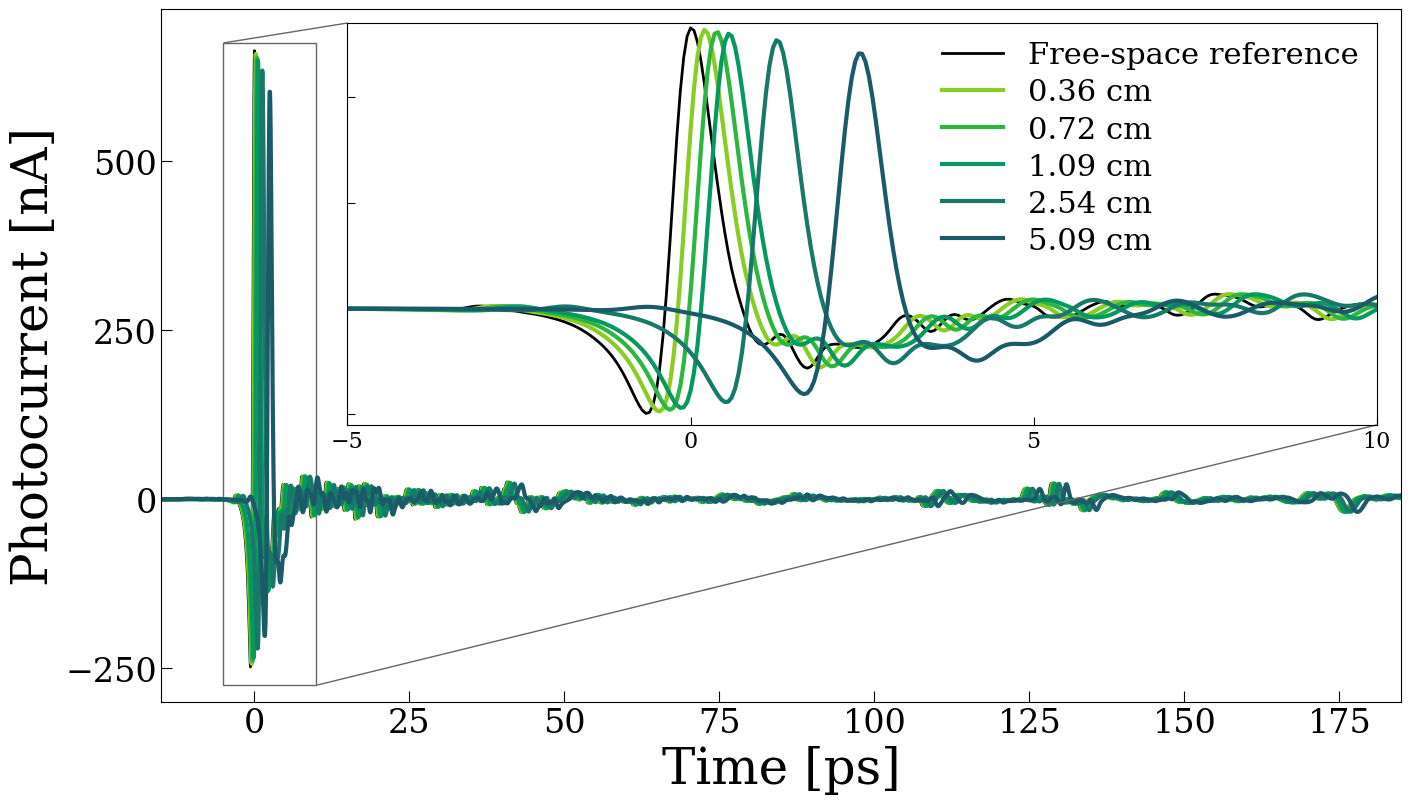

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(16, 9))

T_open,  pc_open  = site_25o4mm.get_base_pulse()

T0 = T_open[np.argmin(pc_open)]
t_ref = T_open - T0
y_ref = -pc_open

ax.set_xlim(-15, 185)

ylims = [-300, 725]
ax.set_ylim(ylims)
ax.set_yticks([-250, 0, 250, 500])
ax.xaxis.set_minor_locator(MultipleLocator(25))

ax.tick_params(axis="both", which='minor', size=4)
ax.tick_params(axis="both", which='major', size=8)

ax.set_xlabel("Time [ps]")
ax.set_ylabel("Photocurrent [nA]")

# ax.legend(frameon=False, loc="lower right", fontsize=22)

# inset
axins = inset_axes(ax, width="83%", height="58%", bbox_to_anchor=(0.15, 0.4, 1, 1), bbox_transform=ax.transAxes, loc="lower left", borderpad=0)

# plot references
ax.plot(t_ref, y_ref, color="k", lw=2, label="Free-space reference")
axins.plot(t_ref, y_ref, color="k", lw=2, label="Free-space reference")

# plot *all* samples in inset
for s in HD30_batch3.keys():
    width_cm = f"{HD30_batch3[s]['width']:.2f} cm"
    ax.plot(HD30_batch3[s]["T"] - T0, -HD30_batch3[s]["pc"], color=HD30_batch3[s]['color'], lw=3, label=width_cm)
    axins.plot(
        HD30_batch3[s]["T"] - T0,
        -HD30_batch3[s]["pc"],
        color=HD30_batch3[s]['color'],
        ls='-',
        lw=3,
        label=width_cm
    )

x1, x2 = -5, 10
axins.set_xlim(x1, x2)
axins.set_ylim([-275, 675])

axins.legend(frameon=False, loc="upper right", fontsize=22, handlelength=2.0, labelspacing=0.3, borderaxespad=0.2)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4", lw=1)

axins.set_xticks([-5, 0, 5, 10])
axins.set_yticks([-250, 0, 250, 500], labels=[])

axins.tick_params(axis="both", size=6, labelsize=16)

fig.patch.set_facecolor("white")
# plt.tight_layout()
# plt.savefig("HD30_time_domain_inset.pdf", bbox_inches="tight", facecolor="white")
plt.show()

## Phase

In [55]:
# These samples have easily fixable phase jumps at high frequencies that are visually confusing to readers
bugged_batches = ['HD30 batch3 5.09 cm', 'LD15 batch2 0.30 cm', 'LD24 batch2 0.34 cm']
peak_nums = [1, 0, 0] # The index of the peak corresponding to bug

i = 0
for bname, b in batches.items():
    for sample in b:
        if not isinstance(b[sample], dict):
            continue   # skip batch-level keys ('color', 'n_eff', …)

        if bname == 'HD60 2.03 cm':
            phase_diff = np.unwrap(np.unwrap(b[sample]['theta']) - np.unwrap(b[sample]['theta_base']))
            while phase_diff[0] < 0:
                phase_diff += 2*np.pi
            while phase_diff[0] >= 2*np.pi:
                phase_diff -= 2*np.pi
            phase_diff -= phase_diff[0]
        else:
            phase_diff = b[sample]['theta'] - b[sample]['theta_base']
            while phase_diff[20] < 0:
                phase_diff += 2*np.pi
            while phase_diff[20] >= 2*np.pi:
                phase_diff -= 2*np.pi

        b[sample]['phase_diff'] = phase_diff

        if sample in bugged_batches: # Manually correct an easily fixable phase jump at 1719.6 GHz in this sample
            dtheta = np.diff(b[sample]['phase_diff'])
            Abs_dtheta = np.abs(dtheta)
            peaks, props = find_peaks(Abs_dtheta, height=0.5, distance=10)

            peak_num = peak_nums[i]
            idxs = np.arange(len(b[sample]['phase_diff'])) > peaks[peak_num]
            b[sample]['phase_diff'][idxs] += 2*np.pi
            i += 1


        b[sample]['delta_L'] = phase_diff*const.c/(2*np.pi*b[sample]['f']*1e9)
        b[sample]['n'] = 1 + b[sample]['delta_L']/b[sample]['width']*100 # convert to cm

        # Mask diffuse scatter regions in dense foams
        if bname == 'HD80 1" (25.8 mm)':
            ulim = 1390
        elif bname == 'HD110 0.8" (20.8 mm)':
            ulim = 545
        else:
            ulim = 2000

        freq_mask = (b[sample]['f'] <= ulim) # Can change if phase errors occur at high frequencies
        mask_n = freq_mask & (~b[sample]['mask'])

        b[sample]['n_masked'] = b[sample]['n'][mask_n]

        if sample == 'HD30 Batch1 2x1/8" (6.83 mm)':
            continue # Exclude this outlier sample from averaging

        b[sample]['n_eff'] = np.average(b[sample]['n_masked'], weights=b[sample]['t'][mask_n])
        b[sample]['n_eff_err'] = np.sqrt(np.average((b[sample]['n_masked'] - b[sample]['n_eff'])**2, weights=b[sample]['t'][mask_n]))

    valid = [sample for sample in b if sample != 'HD30 Batch1 2x1/8" (6.83 mm)']


C:\Users\alexg\AppData\Local\Temp\ipykernel_37812\2346174044.py:38: RuntimeWarning: invalid value encountered in divide
  b[sample]['delta_L'] = phase_diff*const.c/(2*np.pi*b[sample]['f']*1e9)
C:\Users\alexg\AppData\Local\Temp\ipykernel_37812\2346174044.py:38: RuntimeWarning: divide by zero encountered in divide
  b[sample]['delta_L'] = phase_diff*const.c/(2*np.pi*b[sample]['f']*1e9)


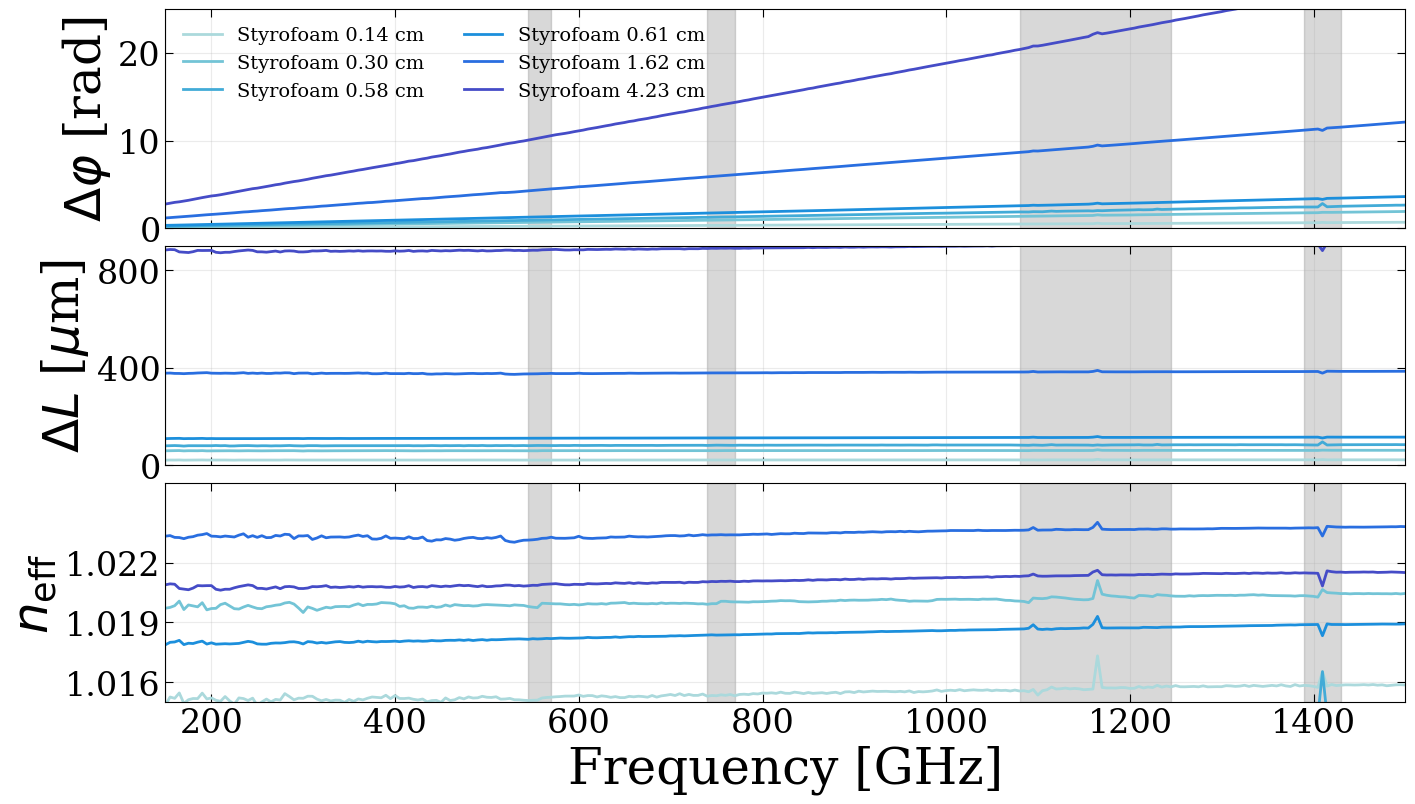

In [56]:
fig, axs = plt.subplots(
    3, 1, sharex=True, figsize=(16, 9),
    gridspec_kw=dict(height_ratios=[1, 1, 1], hspace=0.08)
)

for bname, b in batches.items():
    if "Styrofoam" not in bname:
        continue
    for sample in b:
        axs[0].plot(b[sample]['f'], b[sample]['phase_diff'], color=b[sample]['color'], lw=2, label=sample)
        axs[1].plot(b[sample]['f'], b[sample]['delta_L']*1e6, color=b[sample]['color'], lw=2, label=sample)
        axs[2].plot(b[sample]['f'], b[sample]['n'], lw=2, color=b[sample]['color'], label=sample)

# Axis labels
axs[0].set_ylabel(r'$\Delta \varphi$ [rad]')
axs[1].set_ylabel(r'$\Delta L$ [$\mu$m]')
axs[2].set_ylabel(r'$n_{\rm eff}$')
axs[2].set_xlabel('Frequency [GHz]')

# Limits / ticks
for ax in axs:
    for i, j in zip(mask_starts, mask_stops):
        ax.axvspan(i, j, color='gray', alpha=0.3)
    ax.set_xlim(150, 1500)
    # ax.set_xlim(0, 200)
    ax.grid(True, alpha=0.25)
    ax.tick_params(direction='in', length=6, top=True, right=True)

for i, j in zip(mask_starts, mask_stops):
    if ((i == 0) or (j >= 1500)):
        continue
    # else:
    #     axs[0].text((i+j)/2, 25, 'H$_2$O', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')

axs[0].set_ylim(0, 25)
axs[1].set_ylim(0, 900)
axs[2].set_ylim(1.015, 1.026)
axs[1].set_yticks([0, 400, 800])
axs[2].set_yticks([1.016, 1.019, 1.022])
# Legend (single, clean)
axs[0].legend(loc='upper left', fontsize=14, edgecolor='k', frameon=False, ncol=2)

# Remove x tick labels on upper panels (sharex already, but makes it cleaner)
plt.subplots_adjust(hspace=0.08)
axs[0].label_outer()
axs[1].label_outer()
plt.show()


In [57]:
b.keys()

dict_keys(['HD110 2.08 cm'])

LD15 batch1 2.65 cm
LD15 batch2 0.30 cm
LD24 batch1 2.60 cm
LD24 batch2 0.34 cm
HD80 2.58 cm
HD110 2.08 cm


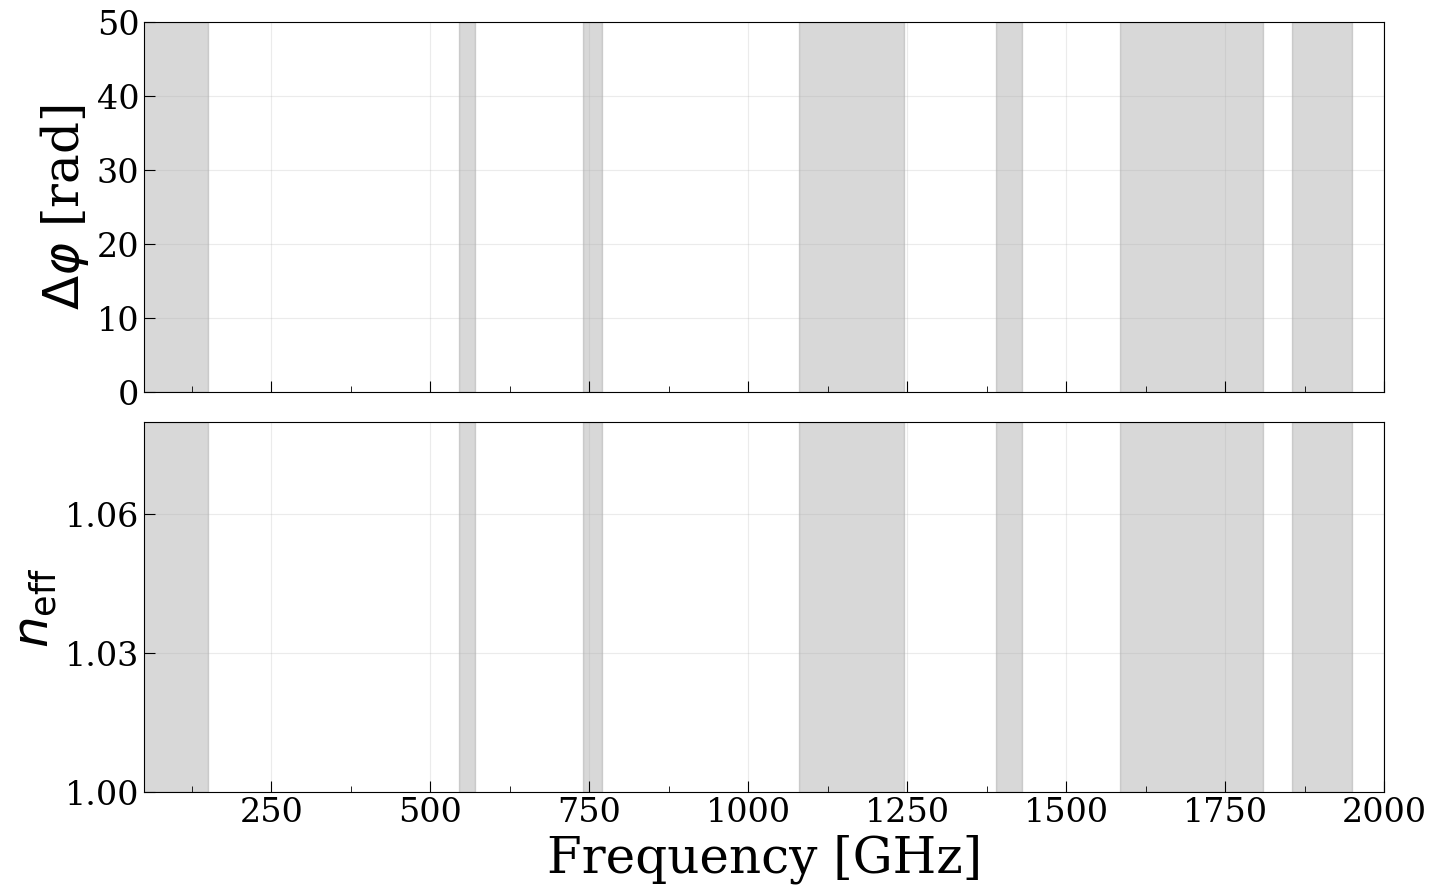

In [58]:
fig, axs = plt.subplots(
    2, 1, sharex=True, figsize=(16, 10),
    gridspec_kw=dict(height_ratios=[1, 1], hspace=0.08)
)

for bname, b in batches.items():
    if bname not in other_zote_keys or bname == 'HD60 2.03 cm':
        continue
    for sample in b:
        print(sample)
        # color = b['color']

        # axs[0].plot(b[sample]['f'], b[sample]['phase_diff'],  color=color, lw=2, label=sample)
        # axs[1].plot(b[sample]['f'], b[sample]['n'],           color=color, lw=2, label=sample)

# Axis labels
axs[0].set_ylabel(r'$\Delta \varphi$ [rad]')
axs[1].set_ylabel(r'$n_{\rm eff}$')
axs[1].set_xlabel('Frequency [GHz]')

# Limits / ticks
for ax in axs:
    for i, j in zip(mask_starts, mask_stops):
        ax.axvspan(i, j, color='gray', alpha=0.3)
    ax.set_xlim(50, 2000)
    # ax.set_xlim(0, 200)
    ax.grid(True, alpha=0.25)
axs[1].xaxis.set_major_locator(MultipleLocator(250))
axs[1].xaxis.set_minor_locator(MultipleLocator(125))

for i, j in zip(mask_starts, mask_stops):
    if ((i == 0) or (j >= 1500)):
        continue

axs[0].set_ylim(0, 50)
axs[1].set_ylim(1, 1.08)
axs[1].set_yticks([1, 1.03, 1.06])

# Remove x tick labels on upper panels (sharex already, but makes it cleaner)
plt.subplots_adjust(hspace=0.08)
axs[0].label_outer()
axs[1].label_outer()

plt.show()

## Frequency Domain

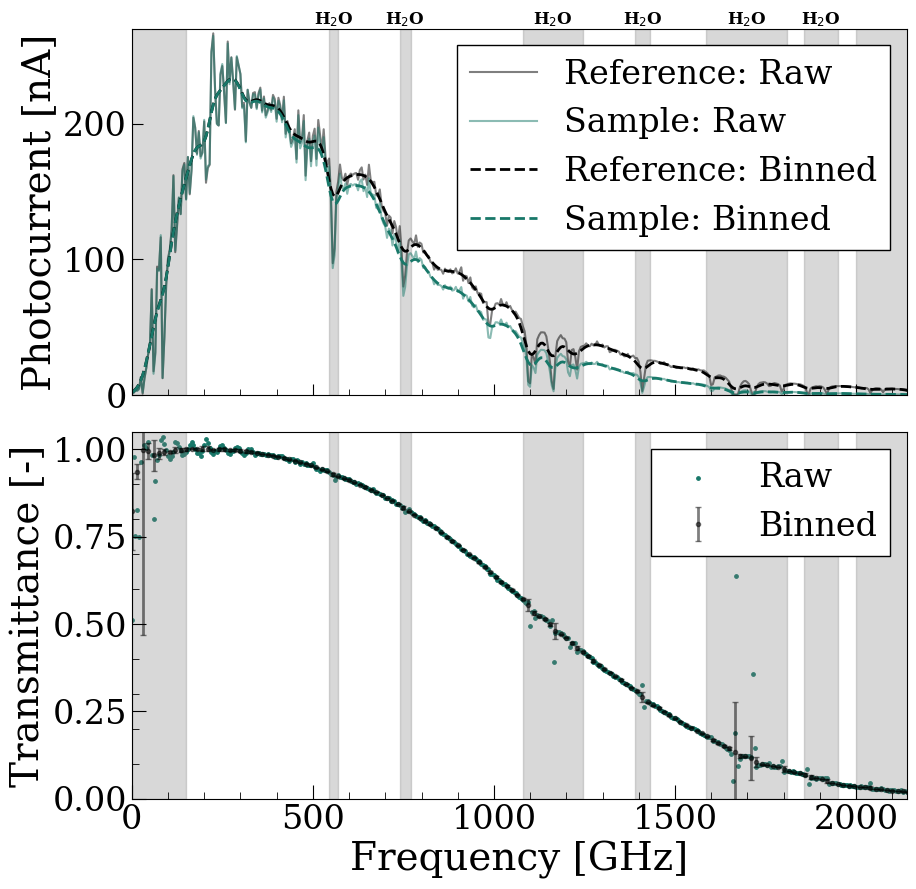

In [ ]:
_, samp_amp = site_25o4mm.get_sample_current()
_, ref_amp  = site_25o4mm.get_base_current()

samp_amp_smoothed = getattr(site_25o4mm, 'bcsamp')
ref_amp_smoothed  = getattr(site_25o4mm, 'bcbase')
mes_err           = getattr(site_25o4mm, 'mes_err')

# Plot measurements and fits
sample = 'HD30 batch3 2.54 cm'
data = HD30_batch3[sample]

color = data['color']

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

ax0, ax1 = axs

ax0.plot(data['f'], ref_amp, color='k', alpha=0.5, label='Reference: Raw')
ax0.plot(data['f'], samp_amp, color=color, alpha=0.5, label='Sample: Raw')
ax0.plot(data['f'], ref_amp_smoothed, color='k', linestyle='--', linewidth=2, label='Reference: Binned')
ax0.plot(data['f'], samp_amp_smoothed, color=color, linestyle='--', linewidth=2, label='Sample: Binned')
# ax1.plot(data['f'], mes_err, color='cyan', linestyle='-', linewidth=2, label='Photon noise floor', zorder=10)

ax1.scatter(data['f'], data['ut'], color=color, s=6, label='Raw')
ax1.errorbar(data['f'][::data['boxnum']], data['t'][::data['boxnum']], yerr=data['err'][::data['boxnum']],
        fmt='o', markersize=3, linewidth=2, capsize=2, color='k', alpha=0.5, label='Binned')
    # plt.plot(data[sample]['f'], data[sample]['cf'], color='k', linestyle='--', linewidth=2, alpha=0.7, zorder=10, label=r'Rayleigh $\times$ Mie Model' if i == len(data)-1 else None)
data_handles, data_labels = plt.gca().get_legend_handles_labels()

xlims = (0, 2140)

for i, j in zip(mask_starts, mask_stops):
    for ax in axs:
        ax.axvspan(i, j, color='gray', alpha=0.3)
    if (i == 0):
        # ax0.text((xlims[0]+j)/2, 270, 'Instr.\nLimit', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')
        continue
    elif (j == 10000):
        # ax0.text((i+xlims[1])/2, 270, 'Instr.\nLimit', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')
        continue
    else:
        ax0.text((i+j)/2, 270, 'H$_2$O', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')


handles, labels = plt.gca().get_legend_handles_labels()
misc_handles = [handle for handle in handles if handle not in data_handles]
custom_line = [mpl.lines.Line2D([0], [1], color='lime', linestyle='--', label='Fitted data')]

# plt.legend(handles=data_handles + custom_line + misc_handles, edgecolor='black', fontsize=16, loc='upper right')
ax0.legend(fontsize=24, loc='upper right', framealpha=1, edgecolor='black', facecolor='white', fancybox=False)
ax1.legend(fontsize=24, loc='upper right', framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

ax1.set_xlim(xlims)
# ax0.set_yscale('log')
# ax1.set_yscale('log')
ax0.set_ylim(0, 270)
ax1.set_ylim(0, 1.05)
# ax1.set_ylim(1e-4, 1e0)
# ax1.set_ylim(0, 1.02)
ax1.yaxis.set_minor_locator(MultipleLocator(0.1))
ax0.xaxis.set_minor_locator(MultipleLocator(100))
plt.tick_params(axis='both', which='major', size=10)
plt.tick_params(axis='both', which='minor', size=5)
ax1.set_xlabel('Frequency [GHz]', fontsize=28)
ax0.set_ylabel('Photocurrent [nA]', fontsize=28)
ax1.set_ylabel('Transmittance [-]', fontsize=28)
plt.gcf().set_facecolor('white')
plt.subplots_adjust(hspace=0.1)

# plt.savefig('ut_vs_t_example.pdf', bbox_inches='tight', facecolor='white')
plt.show()

# Model functions

In [60]:
## We use @njit to speed up the fitting process
# def IRBF(f, params, width, n):
#     lt, C, K_Ray, K_Mie, a_RM = params
#     Ray       = C*(f/K_Ray)**4
#     Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
#     loss      = 2e7*np.pi*n*lt*f/const.c # GHz -> Hz, cm -> m
#     res_RM   = 2*a_RM*Ray*Mie/C
#     return np.exp(-width*(loss + Ray + Mie - res_RM))

# def IRBF_alpha(f, params, n):
#     lt, C, K_Ray, K_Mie, a_RM = params
#     Ray       = C*(f/K_Ray)**4
#     Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
#     loss      = 2e7*np.pi*n*lt*f/const.c
#     res_RM   = 2*a_RM*Ray*Mie/C
#     return loss + Ray + Mie - res_RM

def IRBF_comp(f, params, width, n):
    lt, C, K_Ray, K_Mie, a_RM = params
    Ray       = C*(f/K_Ray)**4
    Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
    loss      = 2e7*np.pi*n*lt*f/const.c
    res_RM   = 2*a_RM*Ray*Mie/C
    return np.exp(-width*loss), np.exp(-width*Ray), np.exp(-width*Mie), np.exp(width*res_RM)

def IRBF_components(f, params, width, n):
    lt, C, K_Ray, K_Mie, a_RM = params
    Ray       = C*(f/K_Ray)**4
    Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
    loss      = 2e7*np.pi*n*lt*f/const.c
    Abs_perc = 100*(1 - np.exp(-width*loss))
    Ray_perc  = 100*(1 - np.exp(-width*Ray))
    Mie_perc  = 100*(1 - np.exp(-width*Mie))
    res_RM   = (np.exp(width*2*a_RM*Ray*Mie/C))
    return Abs_perc, Ray_perc, Mie_perc, res_RM

def IRBF_abs(f, lt, width, n):
    loss      = 2e7*np.pi*n*lt*f/const.c
    Abs_perc = 100*(1 - np.exp(-width*loss))
    return Abs_perc

def chi2_dof(f, t, C, IRBF, len_params):
    chi2 = np.sum(((t - IRBF)/C)**2)
    dof  = len(f) - len_params
    return chi2/dof

Numba just in time (`njit`) version for efficient sampling

In [61]:
from numba import njit, prange

c = float(const.c)

@njit(fastmath=True)
def IRBF_njit(f, params, width, n):
    """
    f:      (Nf,) frequencies (GHz or whatever you're using; just be consistent)
    params: (5,)  [lt, C, K_Ray, K_Mie, a_RM]
    width:  scalar sample width (cm)
    n:      scalar refractive index
    returns (Nf,)
    """
    lt, C, K_Ray, K_Mie, a_RM = params

    # Rayleigh ~ C * (f / K_Ray)^4
    f2  = f * f
    f4  = f2 * f2
    KR4 = K_Ray**4
    Ray = C * f4 / KR4

    # Mie term: C * (2 - 4/(f / K_Mie) sin(f / K_Mie) + 4/(f / K_Mie)^2 (1 - cos(f / K_Mie)))
    f_over_k   = f / K_Mie
    sin_ = np.sin(f_over_k)
    cos_ = np.cos(f_over_k)
    inv  = 1.0 / (f_over_k)
    inv2 = inv * inv
    Mie  = C * (2.0 - 4.0 * (sin_ * inv) + 4.0 * ((1.0 - cos_) * inv2))

    # dielectric loss: 2e7 * pi * n * lt * f / c
    loss = (2.0e7 * np.pi * n * lt / c) * f

    res_RM = 2.0 * a_RM * Ray * Mie / C

    return np.exp(-width*(loss + Ray + Mie - res_RM))

@njit(fastmath=True)
def IRBF_alpha_njit(f, params, n):
    lt, C, K_Ray, K_Mie, a_RM = params

    # Rayleigh ~ (f / K_Ray)^4
    f2  = f * f
    f4  = f2 * f2
    KR4 = K_Ray**4
    Ray = C * f4 / KR4

    # Mie term: C * (2 - 4/(f / K_Mie) sin(f / K_Mie) + 4/(f / K_Mie)^2 (1 - cos(f / K_Mie)))
    f_over_k   = f / K_Mie
    sin_ = np.sin(f_over_k)
    cos_ = np.cos(f_over_k)
    inv  = 1.0 / (f_over_k)
    inv2 = inv * inv
    Mie  = C * (2.0 - 4.0 * (sin_ * inv) + 4.0 * ((1.0 - cos_) * inv2))

    # dielectric loss: 2e7 * pi * n * lt * f / c
    loss = (2.0e7 * np.pi * n * lt / c) * f

    res_RM = 2.0 * a_RM * Ray * Mie / C

    return loss + Ray + Mie - res_RM

## Nested Sampling

In [62]:
from fitting_funcs import IRBF_njit, IRBF_alpha_njit, fitting

def IRBF_comp(f, params, width, n):
    lt, C, K_Ray, K_Mie, a_RM = params
    Ray       = C*(f/K_Ray)**4
    Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
    loss      = 2e7*np.pi*n*lt*f/const.c
    res_RM   = 2*a_RM*Ray*Mie/C
    return np.exp(-width*loss), np.exp(-width*Ray), np.exp(-width*Mie), np.exp(width*res_RM)

def IRBF_components(f, params, width, n):
    lt, C, K_Ray, K_Mie, a_RM = params
    Ray       = C*(f/K_Ray)**4
    Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
    loss      = 2e7*np.pi*n*lt*f/const.c
    Abs_perc = 100*(1 - np.exp(-width*loss))
    Ray_perc  = 100*(1 - np.exp(-width*Ray))
    Mie_perc  = 100*(1 - np.exp(-width*Mie))
    res_RM   = (np.exp(width*2*a_RM*Ray*Mie/C))
    return Abs_perc, Ray_perc, Mie_perc, res_RM

def IRBF_abs(f, lt, width, n):
    loss      = 2e7*np.pi*n*lt*f/const.c
    Abs_perc = 100*(1 - np.exp(-width*loss))
    return Abs_perc

def chi2_dof(f, t, C, IRBF, len_params):
    chi2 = np.sum(((t - IRBF)/C)**2)
    dof  = len(f) - len_params
    return chi2/dof

############# Configure to adjust the nested sampling #############
nlive = 10000
dlogz = 0.01
ncpu  = 16

In [63]:
for bname, b in batches.items():
    for sample in b:
        bname_cleaned = bname.replace(" ", "_").replace('"', 'in')
        sample_cleaned = sample.replace(" ", "_").replace('"', 'in')

        if bname == 'Styrofoam_batch':
            fpath = f'pkls/{bname_cleaned}_{sample_cleaned}_model.pkl2'
        else:
            fpath = f'pkls/{bname_cleaned}_{sample_cleaned}_model.pkl'

        if os.path.exists(fpath):
            with open(fpath, 'rb') as file:
                results = pickle.load(file)
                if results.nlive >= nlive:
                    b[sample]['weights'] = np.exp(results['logwt'] - results['logz'][-1])
                    b[sample]['samples'] = dynesty.utils.resample_equal(results.samples, b[sample]['weights'])
                    print(f'Number of posterior {bname} samples:', len(b[sample]['samples']))
                    continue

        f_      = b[sample]['f_binned']
        t       = b[sample]['t_binned']
        width   = b[sample]['width']
        err     = b[sample]['err_binned']
        n_eff   = b[sample]['n_eff']
        results = fitting(f_, t, width, err, n_eff, nlive, dlogz, ncpu=ncpu) 

        results.summary()

        b[sample]['weights'] = np.exp(results['logwt'] - results['logz'][-1])
        b[sample]['samples'] = dynesty.utils.resample_equal(results.samples, b[sample]['weights'])
        print(f'Number of posterior {bname} samples:', len(b[sample]['samples']))

        # Save the results
        with open(fpath, 'wb') as file:
            pickle.dump(results, file)

Number of posterior Styrofoam_batch samples: 279439
Running Nested Sampling...


416453it [05:09, 1343.73it/s, +10000 | bound: 122 | nc: 1 | ncall: 17799058 | eff(%):  2.397 | loglstar:   -inf < 261.782 <    inf | logz: 224.746 +/-    nan | dlogz:  0.000 >  0.010]


Summary
nlive: 10000
niter: 416453
ncall: 17789058
eff(%):  2.397
logz: 224.746 +/-  0.061
Number of posterior Styrofoam_batch samples: 426453
Running Nested Sampling...


366741it [05:12, 1171.86it/s, +10000 | bound: 135 | nc: 1 | ncall: 16360975 | eff(%):  2.304 | loglstar:   -inf < 370.606 <    inf | logz: 338.542 +/-    nan | dlogz:  0.000 >  0.010]


Summary
nlive: 10000
niter: 366741
ncall: 16350975
eff(%):  2.304
logz: 338.542 +/-  0.056
Number of posterior Styrofoam_batch samples: 376741
Running Nested Sampling...


...

Summary
nlive: 10000
niter: 447122
ncall: 19020175
eff(%):  2.403
logz: -505.503 +/-  0.063
Number of posterior HD30_batch3 samples: 457122
Running Nested Sampling...


440160it [04:04, 1798.50it/s, +10000 | bound: 119 | nc: 1 | ncall: 18198479 | eff(%):  2.475 | loglstar:   -inf < -2381.075 <    inf | logz: -2420.482 +/-    nan | dlogz:  0.000 >  0.010]


Summary
nlive: 10000
niter: 440160
ncall: 18188479
eff(%):  2.475
logz: -2420.482 +/-  0.062
Number of posterior HD80 2.58 cm samples: 450160
Running Nested Sampling...


366118it [03:37, 1682.99it/s, +10000 | bound: 116 | nc: 1 | ncall: 15786478 | eff(%):  2.384 | loglstar:   -inf < 105.931 <    inf | logz: 73.927 +/-    nan | dlogz:  0.000 >  0.010]


Summary
nlive: 10000
niter: 366118
ncall: 15776478
eff(%):  2.384
logz: 73.927 +/-  0.055
Number of posterior HD110 2.08 cm samples: 376118


In [64]:
@njit(parallel=True, fastmath=True)
def IRBF_batch_params(f, samples, width, n):
    Ns = samples.shape[0]
    Nf = f.size
    out = np.empty((Ns, Nf), dtype=np.float64)
    for i in prange(Ns):
        out[i, :] = IRBF_njit(f, samples[i, :], width, n)
    return out

@njit(parallel=True, fastmath=True)
def alpha_batch_params(f, samples, n):
    Ns = samples.shape[0]
    Nf = f.size
    out = np.empty((Ns, Nf), dtype=np.float64)
    for i in prange(Ns):
        out[i, :] = IRBF_alpha_njit(f, samples[i, :], n)
    return out

for bname, b in batches.items():
    print(bname)
    bname_cleaned = bname.replace(" ", "_").replace('"', 'in')

    for sample, sdata in b.items():
        n_eff = sdata['n_eff']
        sample_cleaned = sample.replace(" ", "_").replace('"', 'in')

        if bname == 'Styrofoam_batch':
            fpath = f'pkls/{bname_cleaned}_{sample_cleaned}_alpha.pkl2'
        else:
            fpath = f'pkls/{bname_cleaned}_{sample_cleaned}_alpha.pkl'

        if os.path.exists(fpath):
            with open(fpath, 'rb') as file:
                sdata['alpha_lower'], sdata['ns_alpha'], sdata['alpha_upper'] = pickle.load(file)
        else:
            print(sample)
            alpha = alpha_batch_params(f, sdata['samples'], n_eff)
            sdata['alpha_lower'], sdata['ns_alpha'], sdata['alpha_upper'] = np.percentile(alpha, [16, 50, 84], axis=0)
            with open(fpath, 'wb') as file:
                pickle.dump((sdata['alpha_lower'], sdata['ns_alpha'], sdata['alpha_upper']), file)


Styrofoam_batch
Styrofoam 0.14 cm
Styrofoam 0.30 cm
Styrofoam 0.58 cm
Styrofoam 0.61 cm
Styrofoam 1.62 cm
Styrofoam 4.23 cm
LD15 batch1 2.65 cm
LD15 batch1 2.65 cm
LD15 batch2 0.30 cm
LD15 batch2 0.30 cm
LD24 batch1 2.60 cm
LD24 batch1 2.60 cm
LD24 batch2 0.34 cm
LD24 batch2 0.34 cm
HD30_batch1
HD30 batch1 0.35 cm
HD30 batch1 0.65 cm
HD30 batch1 2.76 cm
HD30 batch1 3.09 cm
HD30_batch2
HD30 batch2 0.37 cm
HD30 batch2 0.73 cm
HD30 batch2 2.54 cm
HD30_batch3
HD30 batch3 0.36 cm
HD30 batch3 0.72 cm
HD30 batch3 1.09 cm
HD30 batch3 2.54 cm
HD30 batch3 5.09 cm
HD80 2.58 cm
HD80 2.58 cm
HD110 2.08 cm
HD110 2.08 cm


In [65]:
w = 5  # 5 cm assembly example

for bname, b in batches.items():
    for sample, sdata in b.items():
        if not isinstance(sdata, dict) or 'samples' not in sdata:
            continue

        q = np.percentile(sdata['samples'], [16, 50, 84], axis=0)

        sdata['params']       = q[1]
        sdata['upper_params'] = q[2] - q[1]
        sdata['lower_params'] = q[1] - q[0]
        sdata['C_params']     = (q[2] - q[0]) / 2

        # We use the 95th percentile, the 2 sigma UL if the posterior is gaussian
        q = np.percentile(sdata['samples'], 95, axis=0)
    
        sdata['upper_params'][0] = q[0]
        sdata['lower_params'][0] = 0

        width = sdata['width']
        sdata['T_upper'], sdata['ns_T'], sdata['T_lower'] = (
            np.exp(-width * sdata['alpha_upper']),
            np.exp(-width * sdata['ns_alpha']),
            np.exp(-width * sdata['alpha_lower']),
        )
        sdata['T_upper_5cm'], sdata['ns_T_5cm'], sdata['T_lower_5cm'] = (
            np.exp(-w * sdata['alpha_upper']),
            np.exp(-w * sdata['ns_alpha']),
            np.exp(-w * sdata['alpha_lower']),
        )


## Combined Sampling Results

In [66]:
def round_uncertainty(x):
    """Return (rounded_value, decimal_places_for_round())."""
    x = float(x)
    if x == 0.0:
        return 0.0, 0

    exponent = int(np.floor(np.log10(abs(x))))

    # first_digit = abs(x) / 10**exponent
    # sigfigs = 2 if first_digit < 1.95 else 1
    sigfigs = 1
    
    decimals = int(sigfigs - 1 - exponent)  # can be negative!

    return round(x, decimals), decimals

def sci_scale(x):
    """
    Return (scaled_x, exponent) such that:
    x = scaled_x * 10**exponent
    """
    if x == 0:
        return 0.0, 0
    exponent = int(np.floor(np.log10(abs(x))))
    return x / 10**exponent, exponent

def format_unc(mu, C_minus, C_plus, sci_thresh=1e-3):
    mu = float(mu)
    C_minus = float(C_minus)
    C_plus  = float(C_plus)

    use_sci = abs(mu) < sci_thresh and mu != 0

    if use_sci:
        mu_s, exp = sci_scale(mu)
        sm_s = C_minus / 10**exp
        sp_s = C_plus  / 10**exp
    else:
        mu_s, sm_s, sp_s = mu, C_minus, C_plus
        exp = None

    # Determine rounding from uncertainties
    _, d1 = round_uncertainty(sm_s)
    _, d2 = round_uncertainty(sp_s)
    decimals = max(d1, d2)

    mu_r = round(mu_s, decimals)
    sm_r = round(sm_s, decimals)
    sp_r = round(sp_s, decimals)

    prec = max(decimals, 0)
    fmt = f"{{:.{prec}f}}"

    core = rf"{fmt.format(mu_r)}^{{+{fmt.format(sp_r)}}}_{{-{fmt.format(sm_r)}}}"

    if use_sci:
        return rf"${core}\times10^{{{exp}}}$"
    else:
        return rf"${core}$"
    
def format_unc_1sided(mu, C, sci_thresh=1e-3, shorthand=True):
    mu = float(mu)
    C = float(C)

    use_sci = abs(mu) < sci_thresh and mu != 0

    if use_sci:
        mu_s, exp = sci_scale(mu)
        C_s = C / 10**exp
    else:
        mu_s, C_s = mu, C
        exp = None

    _, decimals = round_uncertainty(C_s)
    mu_r = round(mu_s, decimals)
    C_r = round(C_s, decimals)

    prec = max(decimals, 0)
    fmt = f"{{:.{prec}f}}"

    if shorthand and not use_sci:
        ### e.g. 1.013(1) for 1.013 ± 0.001
        C_int = round(C_r * 10**prec)
        core = rf"{fmt.format(mu_r)}({C_int})"
        return rf"${core}$"

    core = rf"{fmt.format(mu_r)} \pm {fmt.format(C_r)}"

    if use_sci:
        return rf"${core}\times10^{{{exp}}}$"
    else:
        return rf"${core}$"
    
def format_val(val, sci_thresh=1e-2):
    val = float(val)
    
    use_sci = abs(val) < sci_thresh and val != 0

    if use_sci:
        exp = int(np.floor(np.log10(abs(val))))
        core = val / 10**exp
        return rf"${core:.1f}\times10^{{{exp}}}$"
    else: 
        return rf"${val:.2f}$"


def get_corner_handles(bname, bs, type=None):
    handles = []
    
    for b in bs:
        if type == None:
            sample_cleaned = b.replace('_', ' ')
        elif type == 'HD30':
            sample_cleaned = b.replace('_', ' ').replace('HD30 ', '').replace('batch', 'Batch ')
        elif type == 'Styrofoam':
            sample_cleaned = b.replace('_', ' ').replace('Styrofoam', '').replace('batch', 'Batch ')
        else:
            raise ValueError("type must be None, 'HD30', or 'Styrofoam'")
        base = batches[bname][b]['color']

        # Convert to RGBA and make a lighter facecolor (blend with white)
        r, g, b, a = mcolors.to_rgba(base)
        light = (0.5 + 0.5*r, 0.5 + 0.5*g, 0.5 + 0.5*b, 0.9)
        dark  = (r, g, b, 1.0)                             

        # Zero-size Rectangle proxy like anesthetic (width/height don't matter for legend)
        patch = mpatches.Rectangle(
            (0, 0), 0, 0,
            facecolor=dark,
            edgecolor=light,
            linewidth=4,
            label=sample_cleaned,
        )
        handles.append(patch)

    return handles

Get band averages from the estimates

In [67]:
def f_p_from_rho(rho_eff, rho_p, rho_m=1.25):
    """Matrix volume fraction from density mixing: rho_eff = f_p rho_p + (1-f_p) rho_m."""
    return (rho_eff - rho_m) / (rho_p - rho_m)

def lt_eff(f_p, n_p, tan_delta_p, n_eff, n_m=1.0003):
    """
    Maxwell–Garnett (dilute polymer inclusions in gas host) effective loss tangent.
    tanδ_eff = n_p^2 * (n_n_eff^2 + 2n_m^2)^2 / [n_eff^2 * (n_p^2 + 2n_m^2)^2] * f_p tanδ_p
    """
    num = n_p**2*(n_eff**2 + 2*n_m**2)**2
    den = n_eff**2*(n_p**2   + 2*n_m**2)**2
    return (num / den) * f_p * tan_delta_p

for bname, b in batches.items():
    for sample in b:

        ## Estimate the loss tangent
        if "HD" in bname:
            b[sample]['rho_p'] = 950
            lt_p = 2.5e-4   # HDPE loss tangent from literature
            b[sample]['n_p'] = 1.54
            
        elif "LD" in bname:
            b[sample]['rho_p'] = 925
            lt_p  = 2.7e-4
            b[sample]['n_p']   = 1.514  # Literature estimates this value as slightly lower...
            
        elif "Styrofoam" in bname:
            b[sample]['rho_p'] = 1050
            lt_p = 6.9e-3       # Polystyrene loss tangent from literature
            b[sample]['n_p']   = 1.59
        else:
            raise ValueError(f"Unknown material type: {bname}")

        b[sample]['f_p'] = f_p_from_rho(b[sample]['density'], b[sample]['rho_p'])
        b[sample]['lt']  = lt_eff(b[sample]['f_p'], b[sample]['n_p'], lt_p, b[sample]['n_eff'])

In [68]:
band_windows_full = {
    "30":  (24, 30),
    "40":  (30, 47),
    "90":  (75, 110),
    "150": (120, 165),
    "220": (195, 255),
    "280": (260, 305),
    "350": (330, 370),
    "850": (850, 890)
}

for bname, b in batches.items():
    for sample in b:
    ## Constrain the components
        params       = b[sample]["params"]
        upper_params = b[sample]["upper_params"]
        lower_params = b[sample]["lower_params"]
        n_eff        = b[sample]["n_eff"]
        lt           = b[sample]["lt"]

        Abs,       Ray,       Mie,       res       = IRBF_components(f, params, w, n_eff)
        Abs_upper, Ray_upper, Mie_upper, res_upper = IRBF_components(f, params + upper_params, w, n_eff)
        Abs_lower, Ray_lower, Mie_lower, res_lower = IRBF_components(f, params - lower_params, w, n_eff)

        # Abs_lower = np.zeros_like(Abs_lower)
        # Abs = IRBF_abs(f, lt, w, n_eff)
        # Abs_upper = 2*Abs

        estimates = {
            "Abs": dict(arr=Abs, upper=Abs_upper, lower=Abs_lower, color='tab:red',    ls='-'),
            "Ray":  dict(arr=Ray,  upper=Ray_upper,  lower=Ray_lower,  color='tab:blue',   ls='--'),
            "Mie":  dict(arr=Mie,  upper=Mie_upper,  lower=Mie_lower,  color='tab:orange', ls=':'),
            "res": dict(arr=res, upper=res_upper, lower=res_lower, color='tab:green',  ls='-.'),
        }

        b[sample]["estimates"] = estimates

        band_avgs = {}
        for band, (lo_f, hi_f) in band_windows_full.items():
            sel = (f > lo_f) & (f < hi_f)
            
            for comp, est_data in estimates.items():
                val       = np.mean(est_data['arr'][sel])
                upper_val = np.mean(est_data['upper'][sel])
                lower_val = np.mean(est_data['lower'][sel])

                up = upper_val - val
                lo = val - lower_val

                band_avgs[(band, comp)]            = val
                band_avgs[(band, f"{comp}_upper")] = up
                band_avgs[(band, f"{comp}_lower")] = lo

        b[sample]["band_avgs"] = band_avgs

        ## Band averaged transmission with uncertainties
        T_lower, ns_T, T_upper = b[sample]['T_lower_5cm'], b[sample]['ns_T_5cm'], b[sample]['T_upper_5cm']
        for band_name, (lo_f, hi_f) in band_windows_full.items():
            sel = (f > lo_f) & (f < hi_f)
            val = float(np.mean(ns_T[sel]))
            upper_val = float(np.mean(T_upper[sel]))
            lower_val = float(np.mean(T_lower[sel]))

            up = upper_val - val
            lo = val - lower_val

            b[sample][f"T{band_name}"] = format_unc(val, lo, up)

C:\Users\alexg\AppData\Local\Temp\ipykernel_37812\3689290789.py:19: RuntimeWarning: overflow encountered in exp
  res_RM   = (np.exp(width*2*a_RM*Ray*Mie/C))


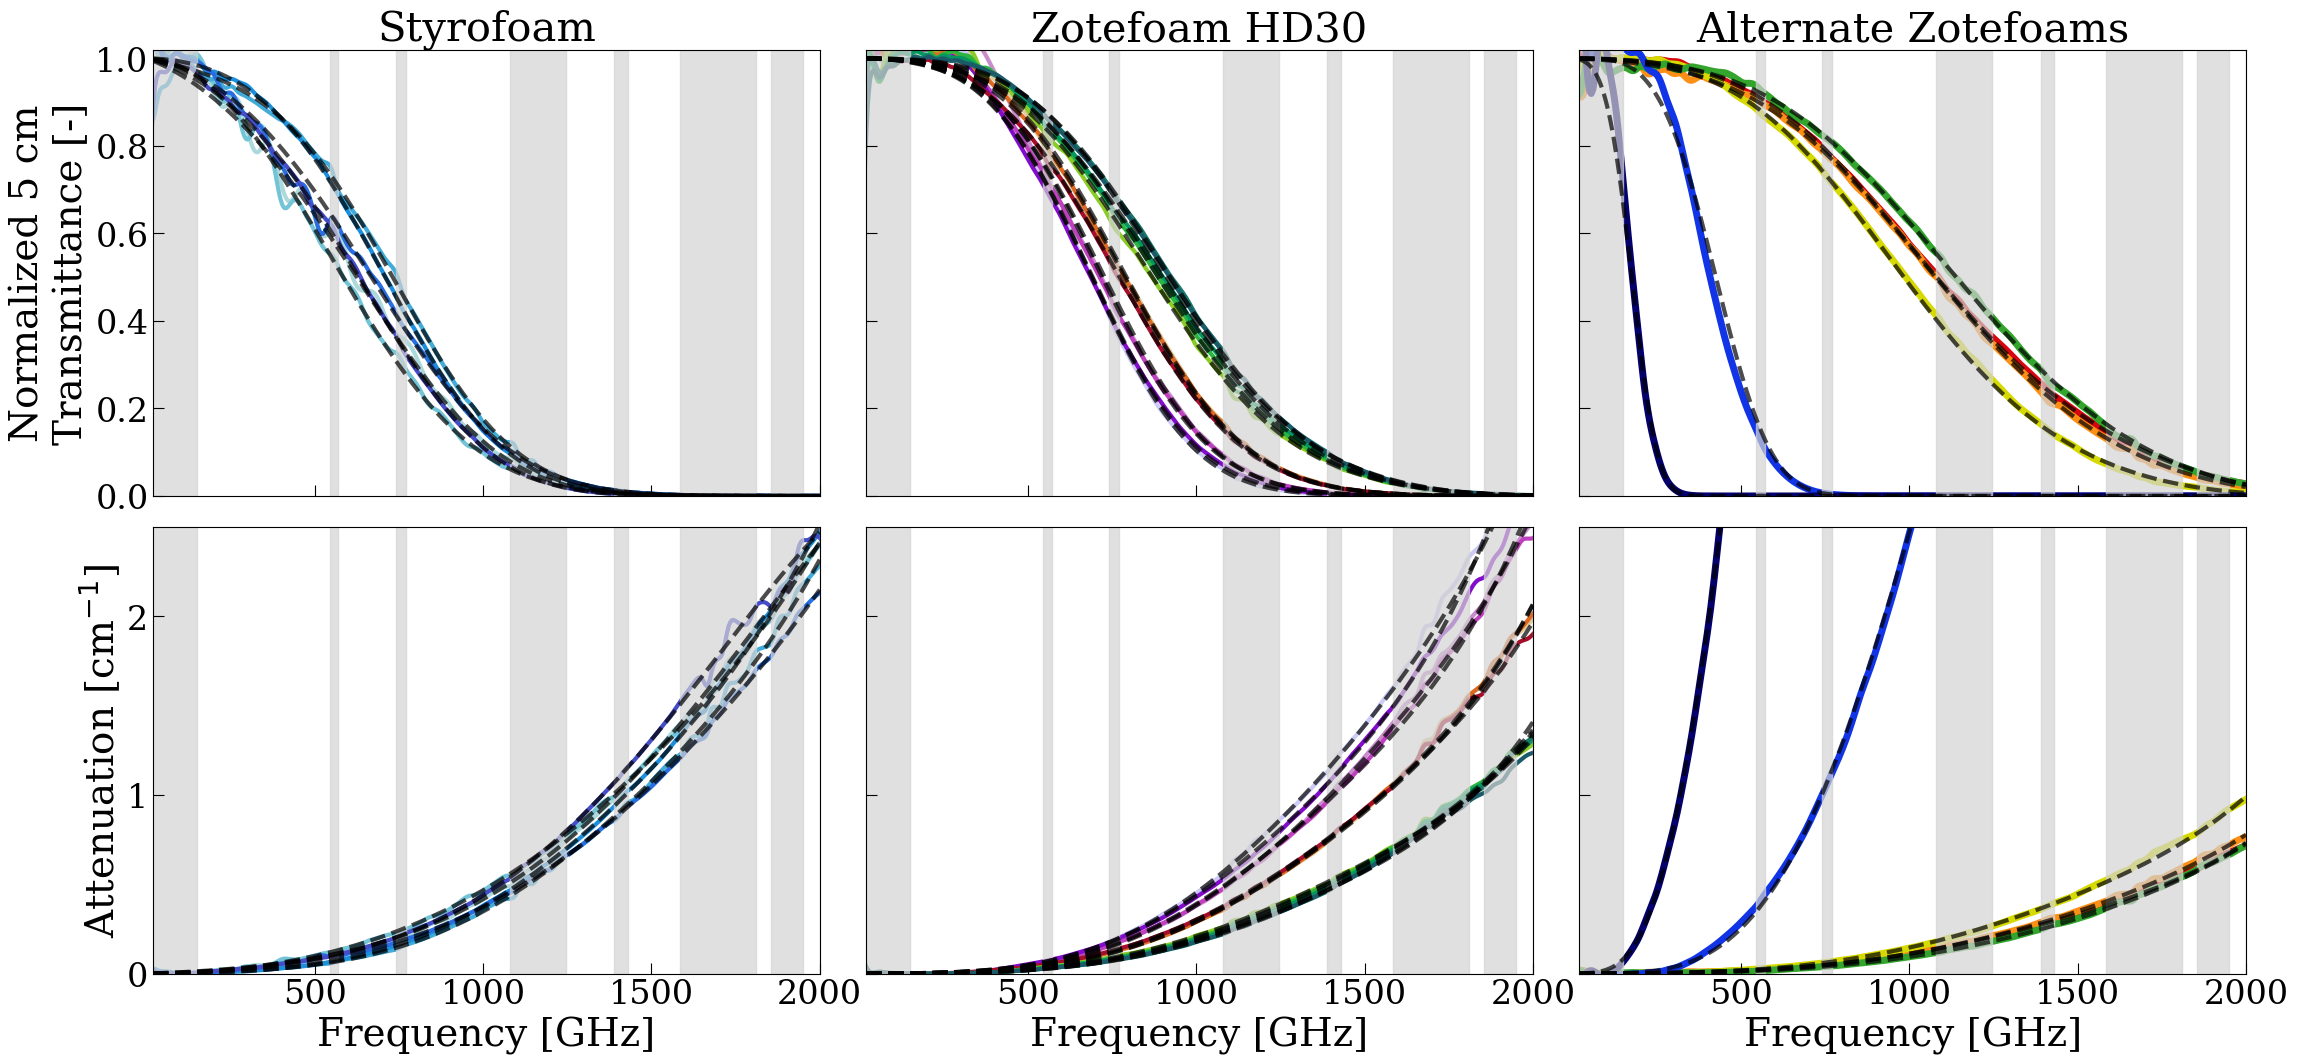

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(27, 12), sharex=True, sharey='row')

plt.xlim(20, 2000)
axes[0, 0].set_ylim(0, 1.02)
axes[1, 0].set_ylim(0, 2.5)
axes[0, 0].set_ylabel('Normalized 5 cm\nTransmittance [-]', fontsize=28)
axes[1, 0].set_ylabel(r'Attenuation [cm$^{-1}$]', fontsize=28)

for ax in axes[1, :]:
    ax.set_xlabel('Frequency [GHz]', fontsize=28)

for bname, b in batches.items():
    i = 0
    if bname in styro_batches:
        ax1 = axes[0, 0]
        ax2 = axes[1, 0]
        lw = 3
    elif bname in HD30_batches:
        ax1 = axes[0, 1]
        ax2 = axes[1, 1]
        lw = 3
    elif bname in other_zote_keys and bname != 'HD60 2.03 cm':
        ax1 = axes[0, 2]
        ax2 = axes[1, 2]
        lw = 5
    else:
        continue

    for j, sample in enumerate(b):
        if ax == ax2:
            sample_cleaned = DISPLAY_MAP[sample]
            width = b[sample]['width']
            label = sample_cleaned
        else:
            label = sample.split(' ', 1)[1].replace('batch', 'Batch ').replace('combined', 'comb.')
        
        f_    = b[sample]['f']
        t     = b[sample]['t']
        alpha = b[sample]['alpha']
        err   = b[sample]['err']
        color = b[sample]['color']

        ns_T = b[sample]['ns_T']
        ns_alpha = b[sample]['ns_alpha']
        width = b[sample]['width']
        ns_T_5cm = ns_T**(5/width)

        ax1.plot(f_, t**(5/width), color=color, lw=lw, label=label, zorder=-10)
        ax2.plot(f_, alpha, color=color, lw=lw, label=label, zorder=-10)

        # transform to display coordinates

        ax2.plot(f, ns_alpha, color='k', linestyle='--', lw=3, zorder=10, alpha=0.7)
        ax1.plot(f, ns_T_5cm, color='k', linestyle='--', lw=3, zorder=10, alpha=0.7)

        i += 1


for ax in axes.flatten():
    for i, j in zip(mask_starts, mask_stops):
        ax.axvspan(i, j, color='lightgray', alpha=0.7)

# custom_line = mpl.lines.Line2D([0], [1], color='k', linestyle='--', lw=3, label='Model Best Fit')

# styro_line  = mpl.lines.Line2D([0], [1], color=batches['Styrofoam_batch']['color'], lw=3, label='Single styrofoam batch')

# hd30_line1 = mpl.lines.Line2D([0], [1], color=comb_batches['HD30_batch1']['color'], lw=3, label='HD30 batch 1')
# hd30_line2 = mpl.lines.Line2D([0], [1], color=comb_batches['HD30_batch2']['color'], lw=3, label='HD30 batch 2')
# hd30_line3 = mpl.lines.Line2D([0], [1], color=comb_batches['HD30_batch3']['color'], lw=3, label='HD30 batch 3')

# handles = [custom_line, styro_line]

# axes[0, 0].legend(handles=handles, loc='upper right', fontsize=20, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

# handles = [custom_line, hd30_line1, hd30_line2, hd30_line3]
# axes[0, 1].legend(handles=handles, loc='upper right', fontsize=20, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

# handles = axes[0, 2].get_legend_handles_labels()[0]
# handles.insert(0, custom_line)
# axes[0, 2].legend(handles=handles, loc='upper right', fontsize=16, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

axes[0, 0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[1, 0].set_yticks([0, 1, 2])
axes[0, 0].set_title('Styrofoam', fontsize=30)
axes[0, 1].set_title('Zotefoam HD30', fontsize=30)
axes[0, 2].set_title('Alternate Zotefoams', fontsize=30)

plt.gcf().set_facecolor('white')
plt.subplots_adjust(wspace=0.07, hspace=0.07)
# plt.savefig('spectras.pdf', bbox_inches='tight', facecolor='white')
plt.show()

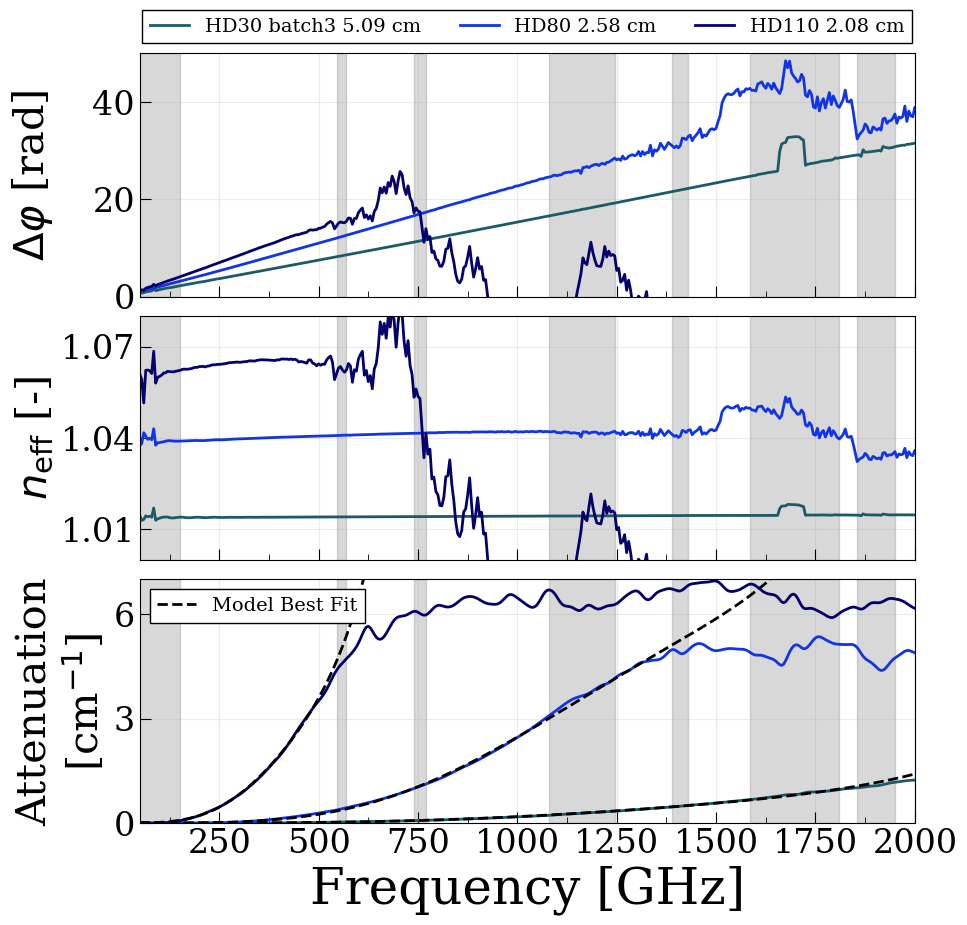

In [ ]:
fig, axs = plt.subplots(
    3, 1, sharex=True, figsize=(10, 10),
    gridspec_kw=dict(height_ratios=[1, 1, 1], hspace=0.08)
)

i = 0
for bname, b in batches.items():
    for sample in b:
        if bname not in ['HD80 2.58 cm', 'HD110 2.08 cm'] and sample != 'HD30 batch3 5.09 cm':
            continue

        color = b[sample]['color']

        axs[0].plot(f_, b[sample]['phase_diff'],  color=color, lw=2)
        axs[1].plot(f_, b[sample]['n'],           color=color, lw=2)
        axs[2].plot(f_, b[sample]['alpha'],       color=color, lw=2, label=sample)
        axs[2].plot(f,  b[sample]['ns_alpha'],    color='k', linestyle='--', lw=2)
        i += 1

# Axis labels
axs[0].set_ylabel(r'$\Delta \varphi$ [rad]', fontsize=30)
axs[1].set_ylabel(r'$n_{\rm eff}$ [-]', fontsize=30)
axs[2].set_ylabel(f'Attenuation\n'+r'[cm$^{-1}$]', fontsize=30)
axs[2].set_xlabel('Frequency [GHz]')

# Limits / ticks
for ax in axs:
    for i, j in zip(mask_starts, mask_stops):
        ax.axvspan(i, j, color='gray', alpha=0.3)
    ax.set_xlim(50, 2000)
    # ax.set_xlim(0, 200)
    ax.grid(True, alpha=0.25)
axs[1].xaxis.set_major_locator(MultipleLocator(250))
axs[1].xaxis.set_minor_locator(MultipleLocator(125))

for i, j in zip(mask_starts, mask_stops):
    if ((i == 0) or (j >= 1500)):
        continue

style_handles = [Line2D([0], [0], color='k', lw=2, linestyle='--', label='Model Best Fit')]

axs[0].set_ylim(0, 50)
axs[1].set_ylim(1, 1.08)
axs[1].set_yticks([1.01, 1.04, 1.07])
axs[2].set_ylim(0, 7)
axs[2].set_yticks([0, 3, 6])
# Legend (single, clean)

handles, labels = axs[2].get_legend_handles_labels()

axs[0].legend(handles, labels, fontsize=14, loc='lower center', 
               bbox_to_anchor=(0.5, 1), ncol=3, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

axs[2].legend(handles=style_handles, fontsize=14, loc='upper left', framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

# Remove x tick labels on upper panels (sharex already, but makes it cleaner)
plt.subplots_adjust(hspace=0.08)
axs[0].label_outer()
axs[1].label_outer()

fig.align_ylabels([axs[0], axs[1]])
# plt.savefig("phase_plot-d.pdf", bbox_inches='tight', facecolor='white')
plt.show()

# bookmark

In [71]:
for bname, b in batches.items():
    if bname != 'Styrofoam_batch':
        continue
    for sample in b:
        print(sample, b[sample]['params'][0])

Styrofoam 0.14 cm 0.00026280895877102677
Styrofoam 0.30 cm 3.403956891740264e-06
Styrofoam 0.58 cm 0.00014939189761735582
Styrofoam 0.61 cm 6.444537917636166e-06
Styrofoam 1.62 cm 0.0001065096888946985
Styrofoam 4.23 cm 0.00017583558905256245


In [72]:
rows = []

param_names = ["Loss tangent", "C", "K_ray", "K_Mie", "a_RM"]

# fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey='row')

for bname, b in batches.items():
    lts    = []
    Cs     = []
    K_rays = []
    K_Mies = []
    a_RMs  = []

    if 'HD60' in bname:
        continue

    if len(b.keys()) == 1:
         continue

    for sample in b:

        row = {"Sample": f"{sample}"}

        # Get the parameters and uncertainties from the appropriate fit

        for i, pname in enumerate(param_names):
            val = float(b[sample]['params'][i])
            up  = float(b[sample]['upper_params'][i])
            lo  = float(b[sample]['lower_params'][i])

            if pname == 'Loss tangent':
                    row[pname] = format_val(val+up)
            else:
                row[pname] = format_unc(val, lo, up)

        val = b[sample]['n_eff']
        sig = b[sample]['n_eff_err']

        row["n_eff^2"] = format_unc_1sided(val, sig)

        rows.append(row)

        lts.append(b[sample]['params'][0])
        Cs.append(b[sample]['params'][1])
        K_rays.append(b[sample]['params'][2])
        K_Mies.append(b[sample]['params'][3])
        a_RMs.append(b[sample]['params'][4])

    lt_mean, lt_std = np.mean(lts), np.std(lts)
    C_mean,  C_std  = np.mean(Cs),  np.std(Cs)
    K_ray_mean, K_ray_std = np.mean(K_rays), np.std(K_rays)
    K_Mie_mean, K_Mie_std = np.mean(K_Mies), np.std(K_Mies)
    a_RM_mean, a_RM_std = np.mean(a_RMs), np.std(a_RMs)
    params_mean = [lt_mean, C_mean, K_ray_mean, K_Mie_mean, a_RM_mean]
    
    print(f"Batch: {bname}")
    print(f"Loss tangent: {lt_mean:.3e} ± {lt_std:.3e}")
    print(f"C: {C_mean:.3e} ± {C_std:.3e}")
    print(f"K_ray: {K_ray_mean:.3e} ± {K_ray_std:.3e}")
    print(f"K_Mie: {K_Mie_mean:.3e} ± {K_Mie_std:.3e}")
    print(f"a_RM: {a_RM_mean:.3e} ± {a_RM_std:.3e}", end="\n\n")

    ## Make a plot
#     plt.xlim(20, 2000)
#     axes[0, 0].set_ylim(0, 1.02)
#     axes[1, 0].set_ylim(0, 2.5)
#     axes[0, 0].set_ylabel('Normalized 5 cm\nTransmittance [-]', fontsize=28)
#     axes[1, 0].set_ylabel(r'Attenuation [cm$^{-1}$]', fontsize=28)

#     if bname in styro_batches:
#         ax1 = axes[0, 0]
#         ax2 = axes[1, 0]
#         lw = 3
#     elif bname in HD30_batches:
#         ax1 = axes[0, 1]
#         ax2 = axes[1, 1]
#         lw = 3
#     elif bname in other_zote_keys and bname != 'HD60 2.03 cm':
#         ax1 = axes[0, 2]
#         ax2 = axes[1, 2]
#         lw = 5
#     else:
#         continue

#     for j, sample in enumerate(b):
#         if ax == ax2:
#             sample_cleaned = DISPLAY_MAP[sample]
#             width = b[sample]['width']
#             label = sample_cleaned
#         else:
#             label = sample.split(' ', 1)[1].replace('batch', 'Batch ').replace('combined', 'comb.')
        
#         f_    = b[sample]['f']
#         t     = b[sample]['t']
#         alpha = b[sample]['alpha']
#         err   = b[sample]['err']
#         color = b[sample]['color']

#         ns_alpha = IRBF_alpha_njit(f, params_mean, b[sample]['n_eff'])
#         ns_T_5cm = np.exp(-5*ns_alpha)

#         ax1.plot(f_, t**(5/width), color=color, lw=lw, label=label, zorder=-10)
#         ax2.plot(f_, alpha, color=color, lw=lw, label=label, zorder=-10)

#         ax2.plot(f, ns_alpha, color='k', linestyle='--', lw=3, zorder=10, alpha=0.7)
#         ax1.plot(f, ns_T_5cm, color='k', linestyle='--', lw=3, zorder=10, alpha=0.7)

# for ax in axes[1, :]:
#     ax.set_xlabel('Frequency [GHz]', fontsize=28)

# for ax in axes.flatten():
#     for i, j in zip(mask_starts, mask_stops):
#         ax.axvspan(i, j, color='lightgray', alpha=0.7)

# axes[0, 0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
# axes[1, 0].set_yticks([0, 1, 2])
# axes[0, 0].set_title('Styrofoam', fontsize=30)
# axes[0, 1].set_title('Zotefoam HD30', fontsize=30)

# plt.gcf().set_facecolor('white')
# plt.subplots_adjust(wspace=0.07, hspace=0.07)
# plt.savefig('spectras.pdf', bbox_inches='tight', facecolor='white')
# plt.show()

    # df = pd.DataFrame(rows)

    # for _, row in df.iterrows():
    #     cells = [row["Sample"]] + [row[p] for p in param_names] + [row["n_eff^2"]]
        # print(" & ".join(cells) + r" \\")

Batch: Styrofoam_batch
Loss tangent: 1.174e-04 ± 9.220e-05
C: 8.046e-01 ± 9.554e-01
K_ray: 1.125e+03 ± 4.955e+02
K_Mie: 1.170e+03 ± 8.285e+02
a_RM: 3.178e-01 ± 3.150e-01

Batch: HD30_batch1
Loss tangent: 2.680e-07 ± 1.416e-07
C: 2.803e-02 ± 5.113e-03
K_ray: 4.706e+02 ± 3.020e+01
K_Mie: 5.068e+02 ± 2.773e+01
a_RM: 1.100e-01 ± 9.684e-04

Batch: HD30_batch2
Loss tangent: 2.981e-07 ± 1.211e-07
C: 2.775e-02 ± 1.117e-02
K_ray: 5.150e+02 ± 5.925e+01
K_Mie: 5.204e+02 ± 1.104e+01
a_RM: 1.072e-01 ± 7.543e-04

Batch: HD30_batch3
Loss tangent: 3.008e-07 ± 1.711e-07
C: 1.842e-02 ± 7.669e-03
K_ray: 5.146e+02 ± 6.757e+01
K_Mie: 5.127e+02 ± 1.682e+01
a_RM: 1.058e-01 ± 3.650e-03



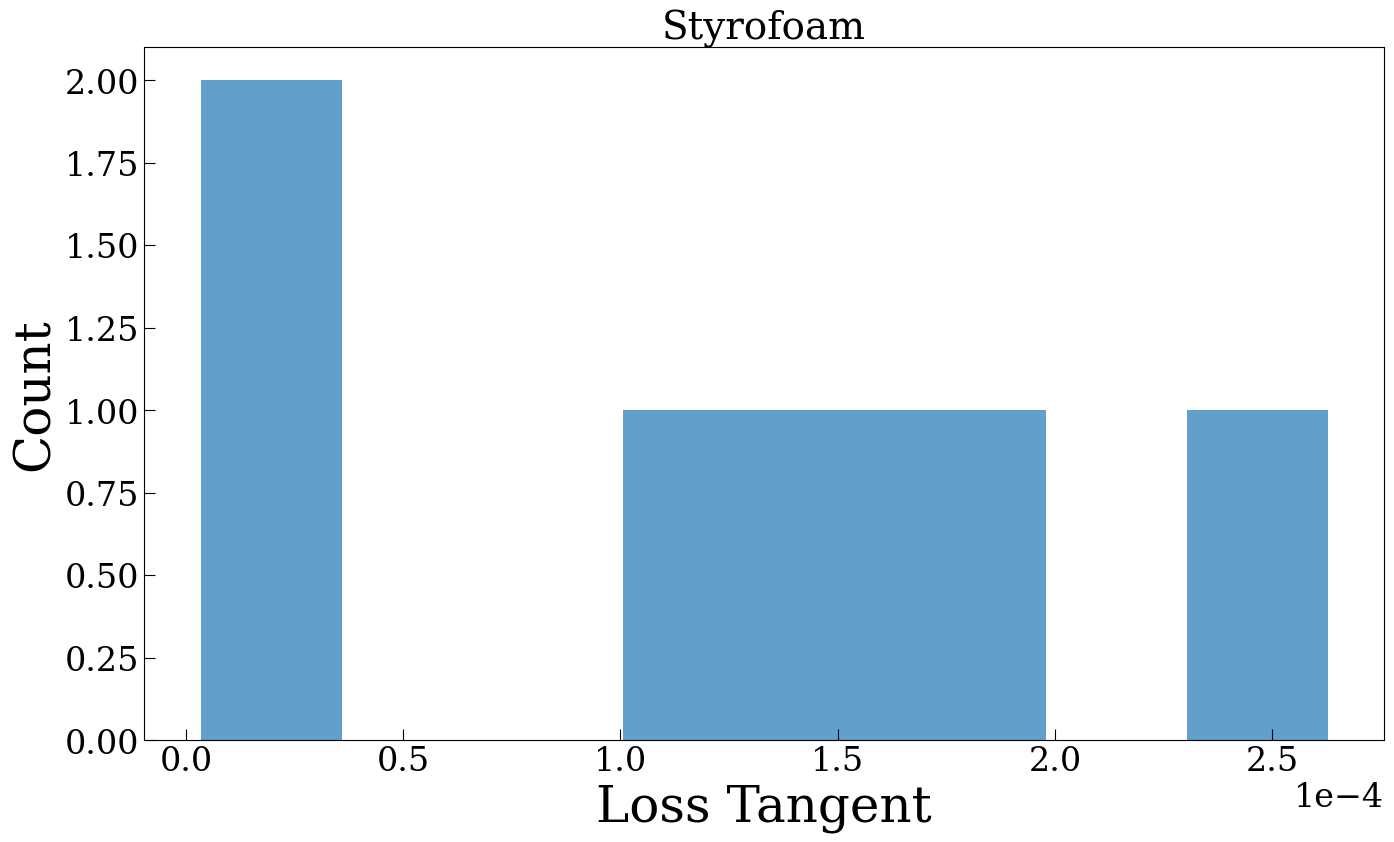

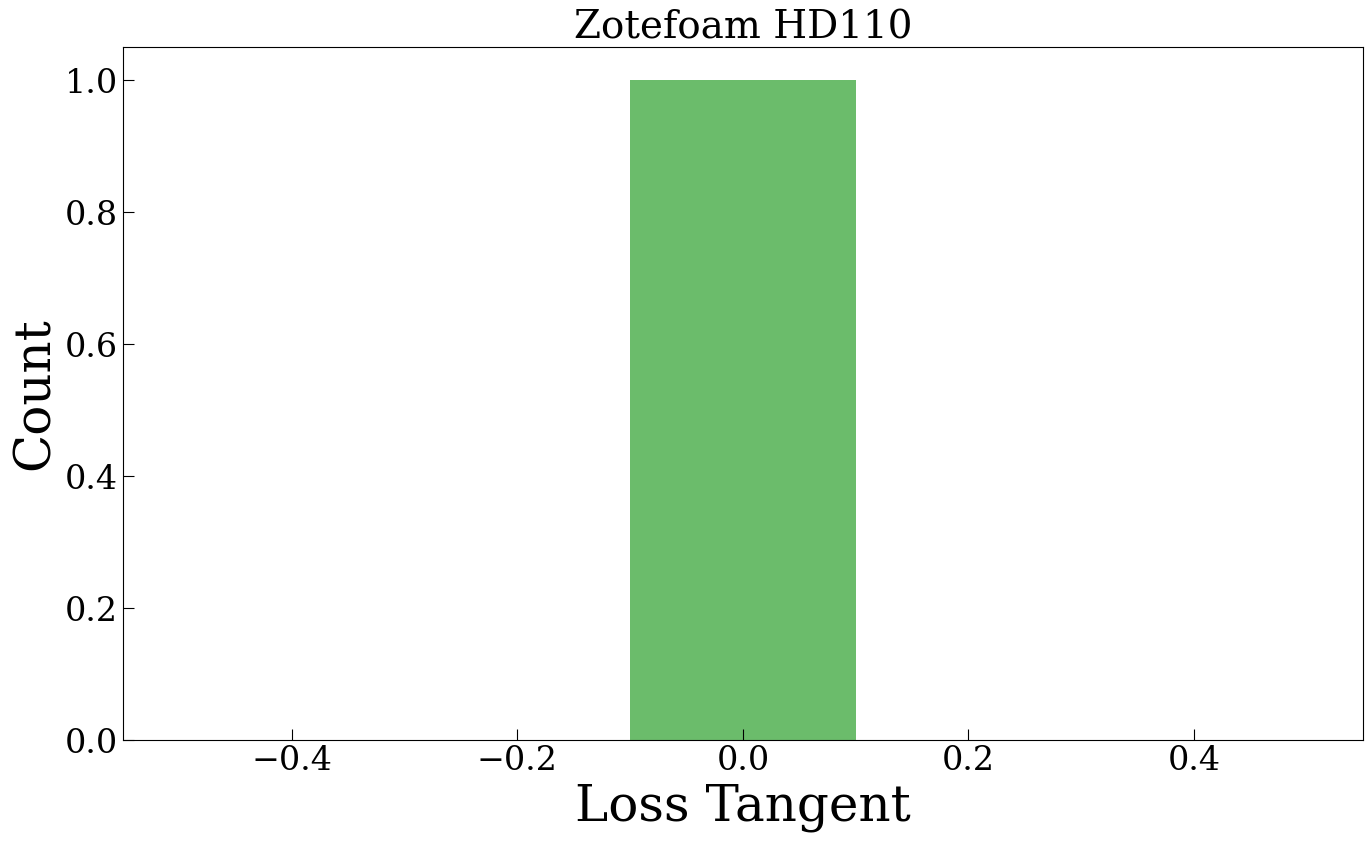

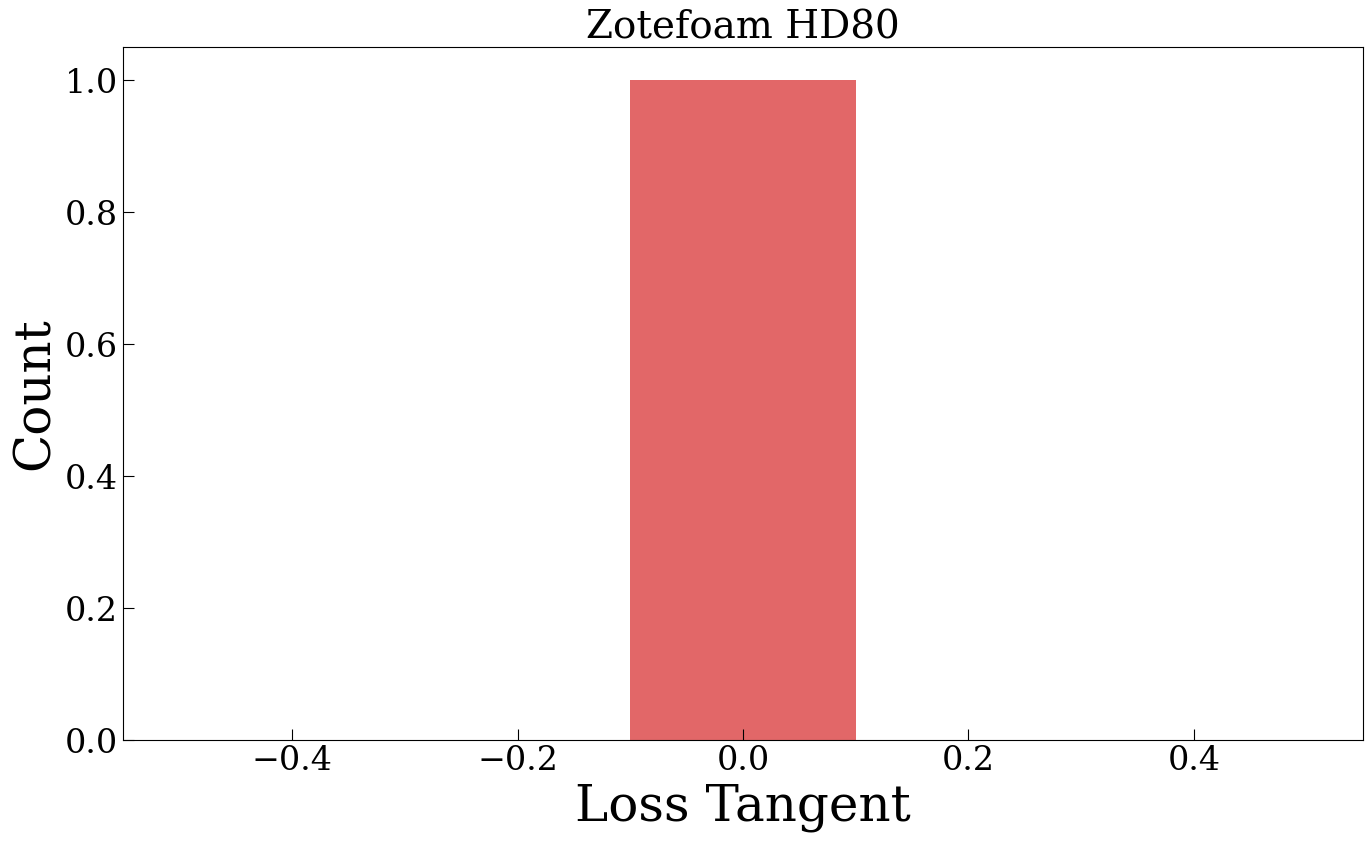

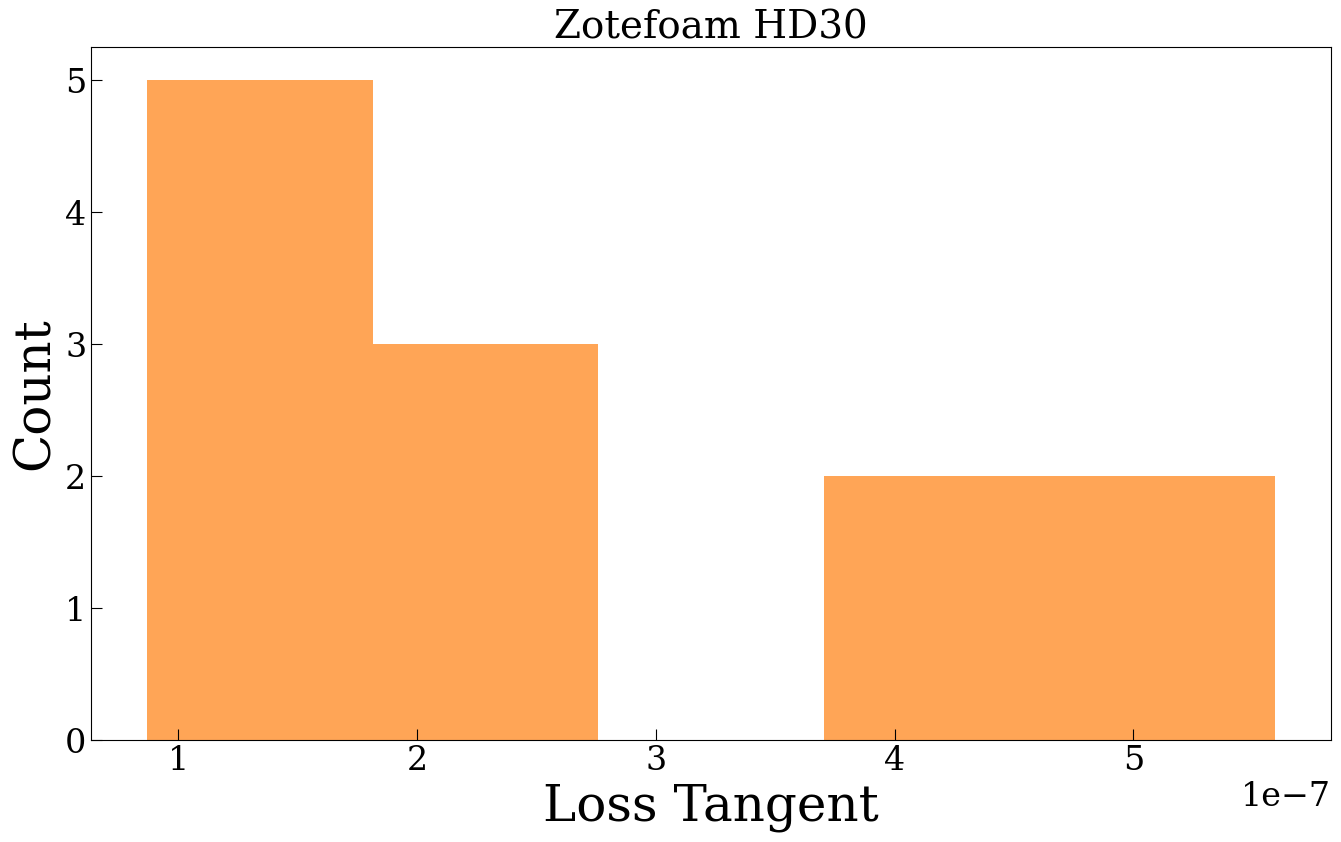

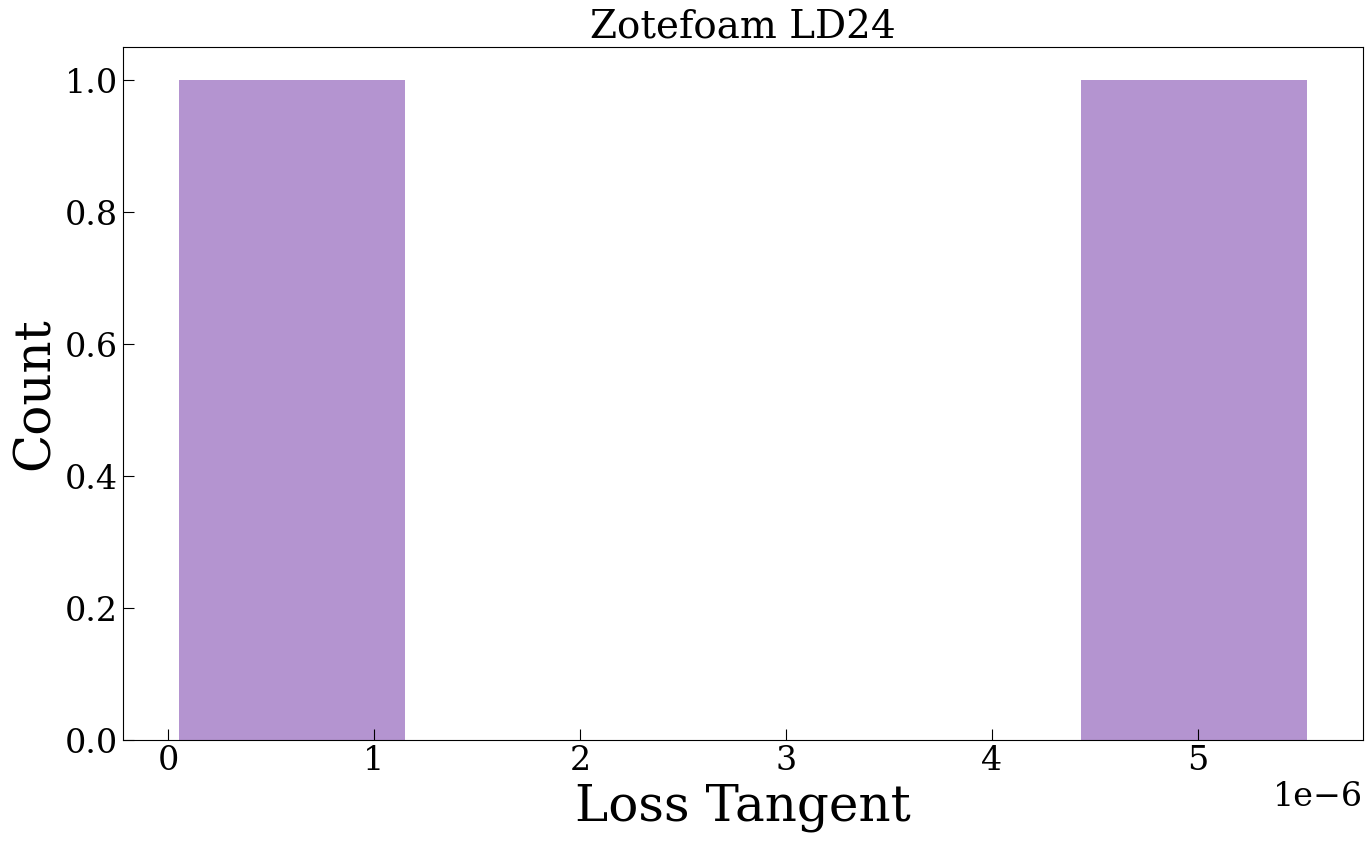

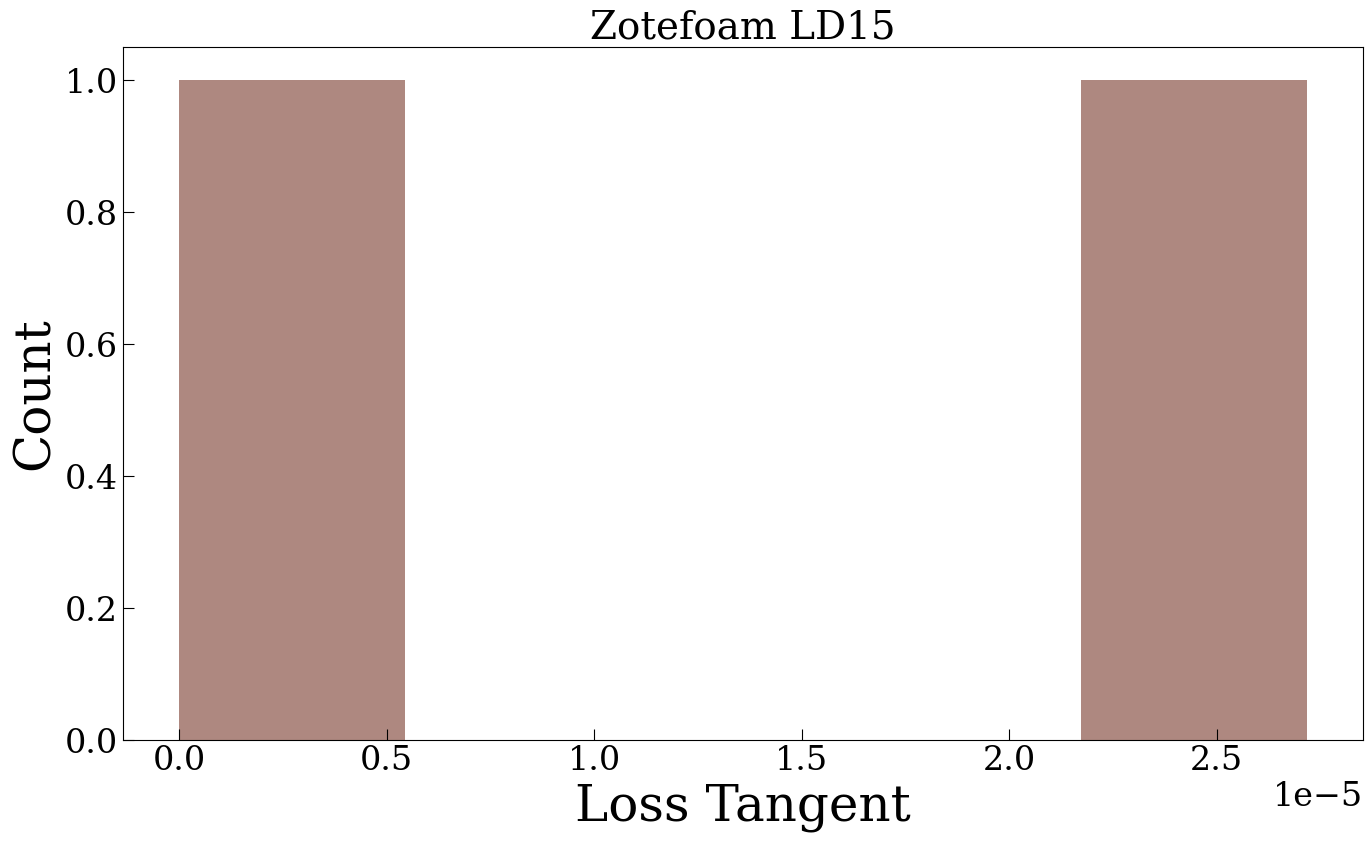

In [73]:
styro_lts = []
HD110_lts = []
HD80_lts = []
HD30_lts = []
LD24_lts = []
LD15_lts = []

for bname, b in batches.items():
    for sample in b:
        lt = b[sample]['params'][0]  # Loss tangent is the first parameter

        if bname in styro_batches:
            styro_lts.append(lt)

        if bname == 'HD110 2.08 cm':
            HD110_lts.append(lt)
        
        if bname == 'HD80 2.58 cm':
            HD80_lts.append(lt)

        if bname in HD30_batches:
            HD30_lts.append(lt)

        if bname in ['LD24 batch1 2.60 cm', 'LD24 batch2 0.34 cm']:
            LD24_lts.append(lt)

        if bname in ['LD15 batch1 2.65 cm', 'LD15 batch2 0.30 cm']:
            LD15_lts.append(lt)

plt.hist(styro_lts, bins=8, color='tab:blue', alpha=0.7)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.title('Styrofoam')
plt.xlabel('Loss Tangent')
plt.ylabel('Count')
plt.show()

plt.hist(HD110_lts, bins=5, color='tab:green', alpha=0.7)
plt.title('Zotefoam HD110')
plt.xlabel('Loss Tangent')
plt.ylabel('Count')
plt.show()

plt.hist(HD80_lts, bins=5, color='tab:red', alpha=0.7)
plt.title('Zotefoam HD80')
plt.xlabel('Loss Tangent')
plt.ylabel('Count')
plt.show()

plt.hist(HD30_lts, bins=5, color='tab:orange', alpha=0.7)
plt.title('Zotefoam HD30')
plt.xlabel('Loss Tangent')
plt.ylabel('Count')
plt.show()

plt.hist(LD24_lts, bins=5, color='tab:purple', alpha=0.7)
plt.title('Zotefoam LD24')
plt.xlabel('Loss Tangent')
plt.ylabel('Count')
plt.show()

plt.hist(LD15_lts, bins=5, color='tab:brown', alpha=0.7)
plt.title('Zotefoam LD15')
plt.xlabel('Loss Tangent')
plt.ylabel('Count')
plt.show()

Styrofoam 0.14 cm
Styrofoam 0.58 cm
Styrofoam 1.62 cm
Styrofoam 4.23 cm


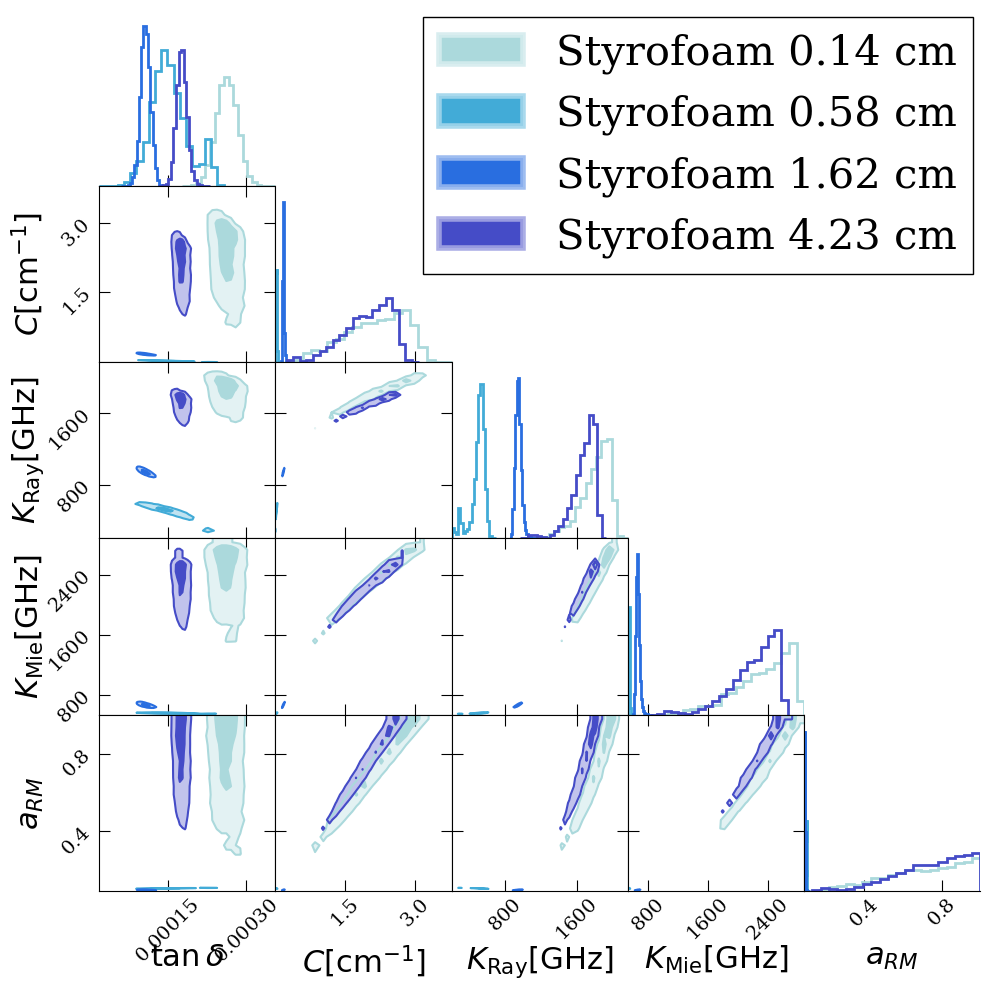

In [74]:
param_names = [r'$\tan\delta$', r'$C [\mathrm{cm}^{-1}]$', r'$K_{\mathrm{Ray}} [\mathrm{GHz}]$', r'$K_{\mathrm{Mie}} [\mathrm{GHz}]$', r'$a_{RM}$']

plot_batches = [batch for batch in batches['Styrofoam_batch'] if batches['Styrofoam_batch'][batch]['params'][0] > 1e-4]

figure = plt.figure(figsize=(10,10))

bname = 'Styrofoam_batch'
b = batches[bname]
for sample in b:
    if sample not in plot_batches:
        continue

    print(sample)

    samples      = b[sample]['samples']
    color        = b[sample]['color']

    fig = corner.corner(samples, 
                    show_titles=False, 
                    labels = param_names,            
                    use_math_text = True,
                    label_kwargs={"fontsize": 22},
                    max_n_ticks=3,
                    plot_datapoints=False,
                    show_median=False,
                    show_mean=False,
                    plot_density=False,
                    levels=[0.393, 0.864],
                    fill_contours=True,
                    color=color,
                    hist_kwargs={"linewidth": 2},
                    fig=figure)

for i, ax in enumerate(fig.axes):
    ax.tick_params(axis='both', labelsize=14)
    if i == 0:
        ax.spines['left'].set_visible(False)
    row, col = divmod(i, len(param_names))
    if col < row:
        ax.xaxis.set_tick_params(which='both', direction='in', top=True)
        ax.yaxis.set_tick_params(which='both', direction='in', right=True)
    if col == row:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_facecolor('white')

figure.canvas.draw()

for ax in figure.get_axes():
    if ax.xaxis.get_offset_text().get_text() != '':
        offset = ax.xaxis.get_offset_text().get_text()
        ax.set_xlabel(ax.get_xlabel() + f' {offset}', fontsize=22)
        ax.xaxis.get_offset_text().set_visible(False)
        
    if ax.yaxis.get_offset_text().get_text() != '':
        offset = ax.yaxis.get_offset_text().get_text()
        ax.set_ylabel(ax.get_ylabel() + f' {offset}', fontsize=22)
        ax.yaxis.get_offset_text().set_visible(False)

handles = get_corner_handles(bname, plot_batches)

fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=30, edgecolor='black', facecolor='white', framealpha=1, fancybox=False)

fig.subplots_adjust(hspace=0, wspace=0)
plt.gcf().set_facecolor('white')
# plt.savefig('styro_params-b.pdf', bbox_inches='tight', facecolor='white')
plt.show()

Styrofoam 0.30 cm
Styrofoam 0.61 cm


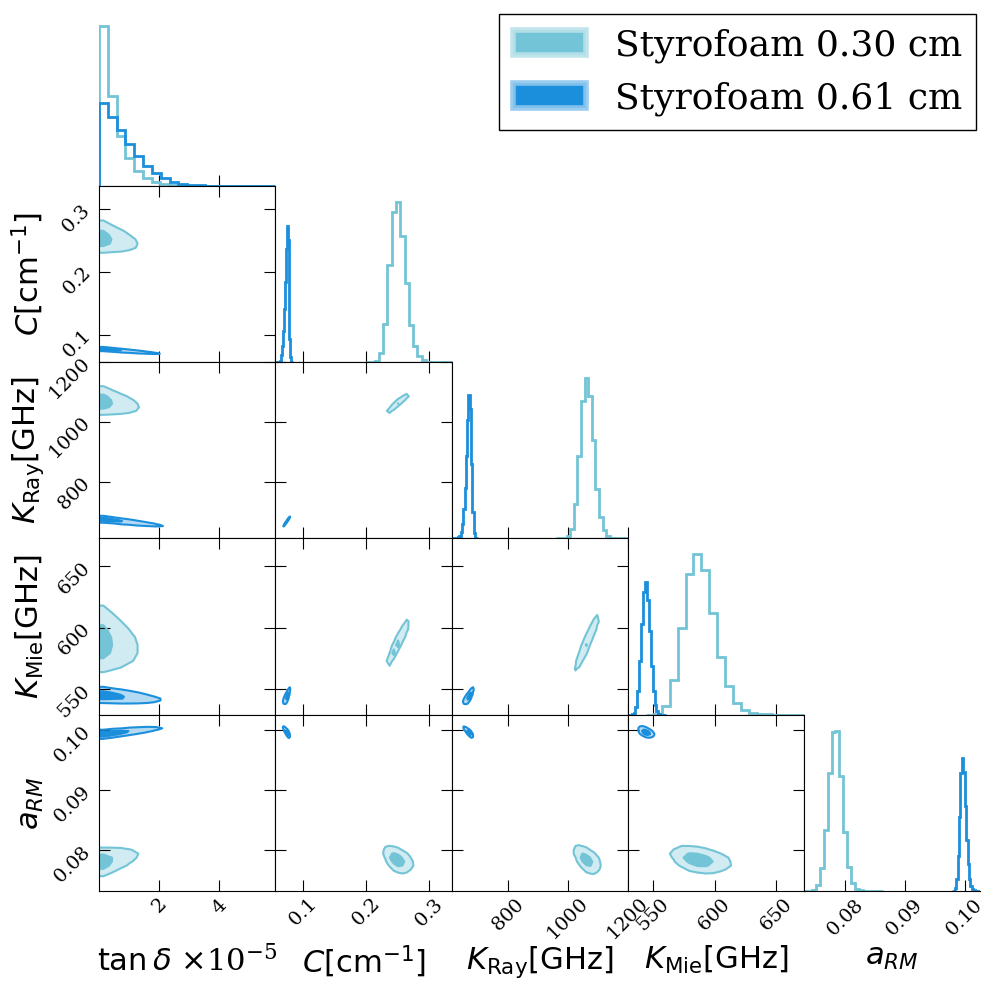

In [75]:
param_names = [r'$\tan\delta$', r'$C [\mathrm{cm}^{-1}]$', r'$K_{\mathrm{Ray}} [\mathrm{GHz}]$', r'$K_{\mathrm{Mie}} [\mathrm{GHz}]$', r'$a_{RM}$']

plot_batches = [batch for batch in batches['Styrofoam_batch'] if batches['Styrofoam_batch'][batch]['params'][0] <= 1e-4]

figure = plt.figure(figsize=(10,10))

bname = 'Styrofoam_batch'
b = batches[bname]
for sample in b:
    if sample not in plot_batches:
        continue

    print(sample)

    samples      = b[sample]['samples']
    color        = b[sample]['color']

    fig = corner.corner(samples, 
                    show_titles=False, 
                    labels = param_names,            
                    use_math_text = True,
                    label_kwargs={"fontsize": 22},
                    max_n_ticks=3,
                    plot_datapoints=False,
                    show_median=False,
                    show_mean=False,
                    plot_density=False,
                    levels=[0.393, 0.864],
                    fill_contours=True,
                    color=color,
                    hist_kwargs={"linewidth": 2},
                    fig=figure)

for i, ax in enumerate(fig.axes):
    ax.tick_params(axis='both', labelsize=14)
    if i == 0:
        ax.spines['left'].set_visible(False)
    row, col = divmod(i, len(param_names))
    if col < row:
        ax.xaxis.set_tick_params(which='both', direction='in', top=True)
        ax.yaxis.set_tick_params(which='both', direction='in', right=True)
    if col == row:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_facecolor('white')

figure.canvas.draw()

for ax in figure.get_axes():
    if ax.xaxis.get_offset_text().get_text() != '':
        offset = ax.xaxis.get_offset_text().get_text()
        ax.set_xlabel(ax.get_xlabel() + f' {offset}', fontsize=22)
        ax.xaxis.get_offset_text().set_visible(False)
        
    if ax.yaxis.get_offset_text().get_text() != '':
        offset = ax.yaxis.get_offset_text().get_text()
        ax.set_ylabel(ax.get_ylabel() + f' {offset}', fontsize=22)
        ax.yaxis.get_offset_text().set_visible(False)

handles = get_corner_handles(bname, plot_batches)

fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=26, edgecolor='black', facecolor='white', framealpha=1, fancybox=False)

fig.subplots_adjust(hspace=0, wspace=0)
plt.gcf().set_facecolor('white')
# plt.savefig('styro_params-b.pdf', bbox_inches='tight', facecolor='white')
plt.show()

HD30 batch1 0.35 cm
HD30 batch1 0.65 cm
HD30 batch1 2.76 cm
HD30 batch1 3.09 cm


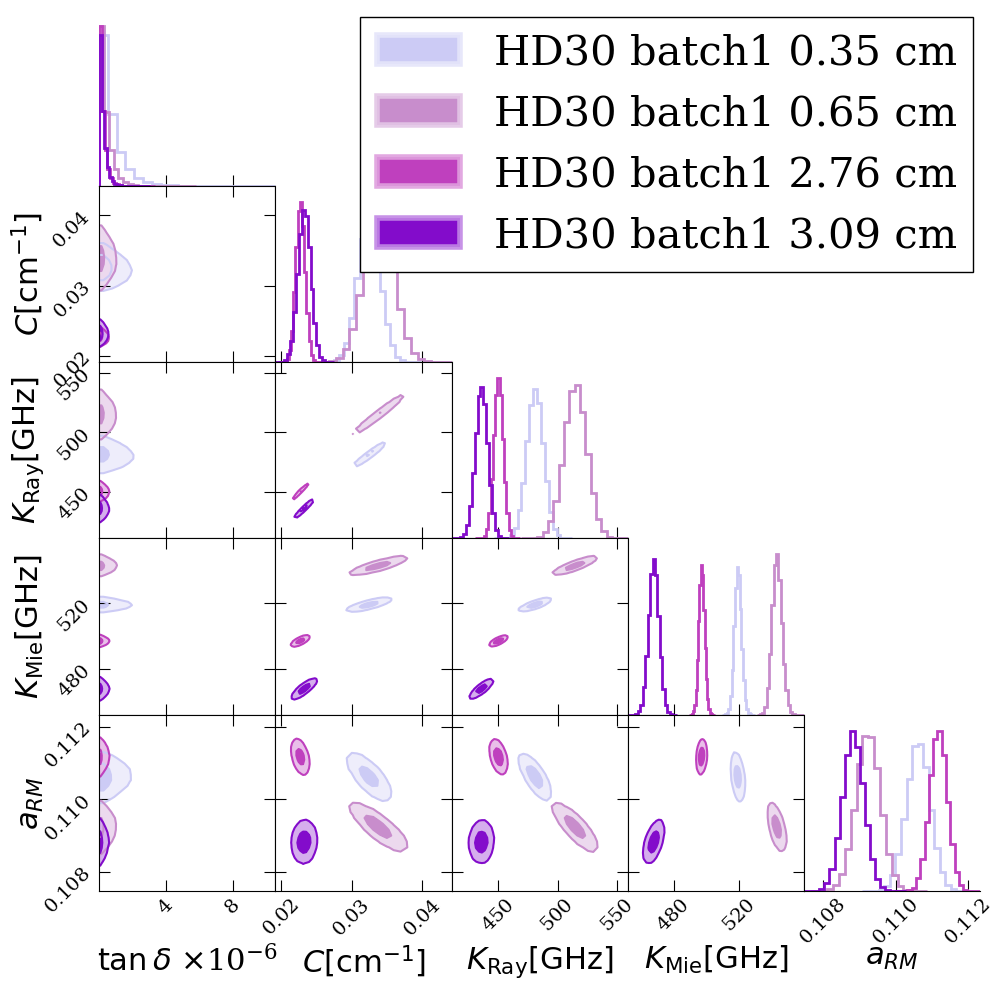

In [93]:
param_names = [r'$\tan\delta$', r'$C [\mathrm{cm}^{-1}]$', r'$K_{\mathrm{Ray}} [\mathrm{GHz}]$', r'$K_{\mathrm{Mie}} [\mathrm{GHz}]$', r'$a_{RM}$']

bname = 'HD30_batch1'
plot_batches = [batch for batch in batches[bname]]

figure = plt.figure(figsize=(10,10))

b = batches[bname]
for sample in b:
    if sample not in plot_batches:
        continue

    print(sample)

    samples      = b[sample]['samples']
    color        = b[sample]['color']

    fig = corner.corner(samples, 
                    show_titles=False, 
                    labels = param_names,            
                    use_math_text = True,
                    label_kwargs={"fontsize": 22},
                    max_n_ticks=3,
                    plot_datapoints=False,
                    show_median=False,
                    show_mean=False,
                    plot_density=False,
                    levels=[0.393, 0.864],
                    fill_contours=True,
                    color=color,
                    hist_kwargs={"linewidth": 2},
                    fig=figure)

for i, ax in enumerate(fig.axes):
    ax.tick_params(axis='both', labelsize=14)
    if i == 0:
        ax.spines['left'].set_visible(False)
    row, col = divmod(i, len(param_names))
    if col < row:
        ax.xaxis.set_tick_params(which='both', direction='in', top=True)
        ax.yaxis.set_tick_params(which='both', direction='in', right=True)
    if col == row:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_facecolor('white')

figure.canvas.draw()

for ax in figure.get_axes():
    if ax.xaxis.get_offset_text().get_text() != '':
        offset = ax.xaxis.get_offset_text().get_text()
        ax.set_xlabel(ax.get_xlabel() + f' {offset}', fontsize=22)
        ax.xaxis.get_offset_text().set_visible(False)
        
    if ax.yaxis.get_offset_text().get_text() != '':
        offset = ax.yaxis.get_offset_text().get_text()
        ax.set_ylabel(ax.get_ylabel() + f' {offset}', fontsize=22)
        ax.yaxis.get_offset_text().set_visible(False)

handles = get_corner_handles(bname, plot_batches)

fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=30, edgecolor='black', facecolor='white', framealpha=1, fancybox=False)

fig.subplots_adjust(hspace=0, wspace=0)
plt.gcf().set_facecolor('white')
# plt.savefig('styro_params-b.pdf', bbox_inches='tight', facecolor='white')
plt.show()

HD30 batch2 0.37 cm
HD30 batch2 0.73 cm
HD30 batch2 2.54 cm


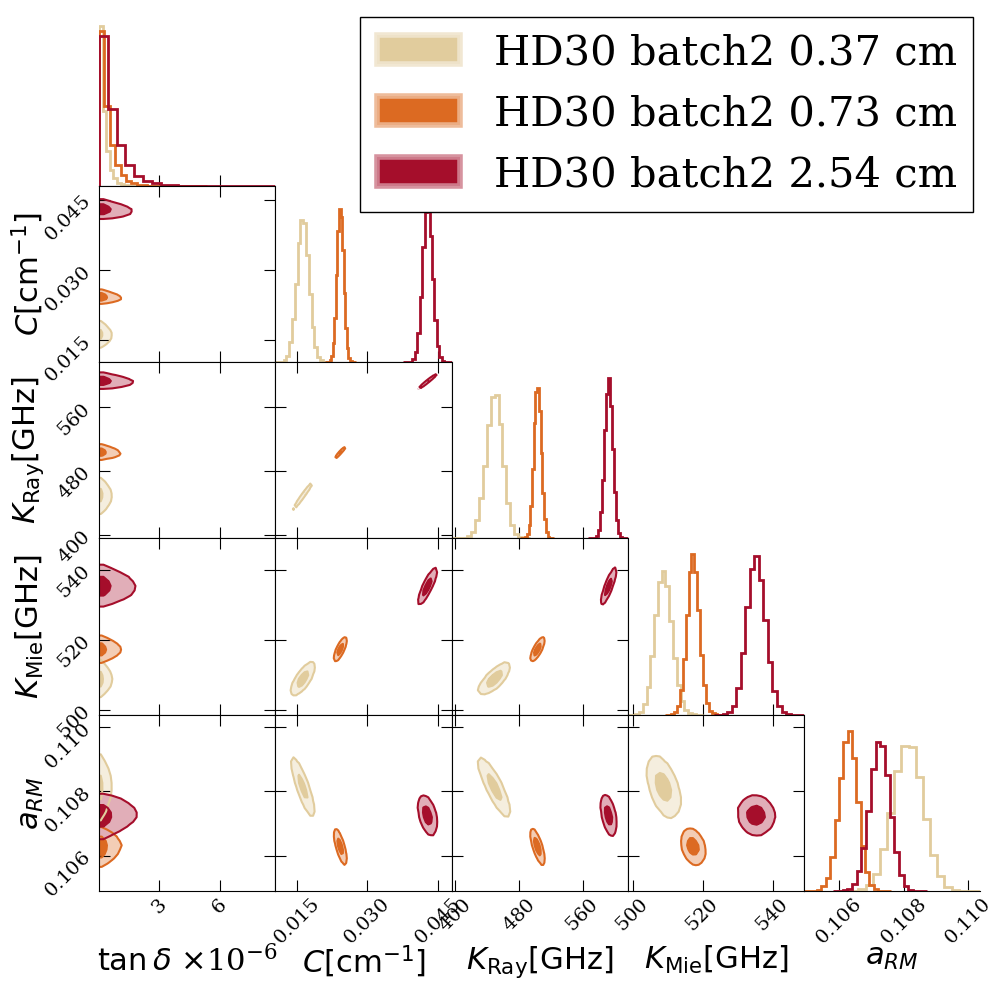

In [94]:
param_names = [r'$\tan\delta$', r'$C [\mathrm{cm}^{-1}]$', r'$K_{\mathrm{Ray}} [\mathrm{GHz}]$', r'$K_{\mathrm{Mie}} [\mathrm{GHz}]$', r'$a_{RM}$']

bname = 'HD30_batch2'
plot_batches = [batch for batch in batches[bname]]

figure = plt.figure(figsize=(10,10))

b = batches[bname]
for sample in b:
    if sample not in plot_batches:
        continue

    print(sample)

    samples      = b[sample]['samples']
    color        = b[sample]['color']

    fig = corner.corner(samples, 
                    show_titles=False, 
                    labels = param_names,            
                    use_math_text = True,
                    label_kwargs={"fontsize": 22},
                    max_n_ticks=3,
                    plot_datapoints=False,
                    show_median=False,
                    show_mean=False,
                    plot_density=False,
                    levels=[0.393, 0.864],
                    fill_contours=True,
                    color=color,
                    hist_kwargs={"linewidth": 2},
                    fig=figure)

for i, ax in enumerate(fig.axes):
    ax.tick_params(axis='both', labelsize=14)
    if i == 0:
        ax.spines['left'].set_visible(False)
    row, col = divmod(i, len(param_names))
    if col < row:
        ax.xaxis.set_tick_params(which='both', direction='in', top=True)
        ax.yaxis.set_tick_params(which='both', direction='in', right=True)
    if col == row:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_facecolor('white')

figure.canvas.draw()

for ax in figure.get_axes():
    if ax.xaxis.get_offset_text().get_text() != '':
        offset = ax.xaxis.get_offset_text().get_text()
        ax.set_xlabel(ax.get_xlabel() + f' {offset}', fontsize=22)
        ax.xaxis.get_offset_text().set_visible(False)
        
    if ax.yaxis.get_offset_text().get_text() != '':
        offset = ax.yaxis.get_offset_text().get_text()
        ax.set_ylabel(ax.get_ylabel() + f' {offset}', fontsize=22)
        ax.yaxis.get_offset_text().set_visible(False)

handles = get_corner_handles(bname, plot_batches)

fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=30, edgecolor='black', facecolor='white', framealpha=1, fancybox=False)

fig.subplots_adjust(hspace=0, wspace=0)
plt.gcf().set_facecolor('white')
# plt.savefig('styro_params-b.pdf', bbox_inches='tight', facecolor='white')
plt.show()

HD30 batch3 0.36 cm
HD30 batch3 0.72 cm
HD30 batch3 1.09 cm
HD30 batch3 2.54 cm
HD30 batch3 5.09 cm


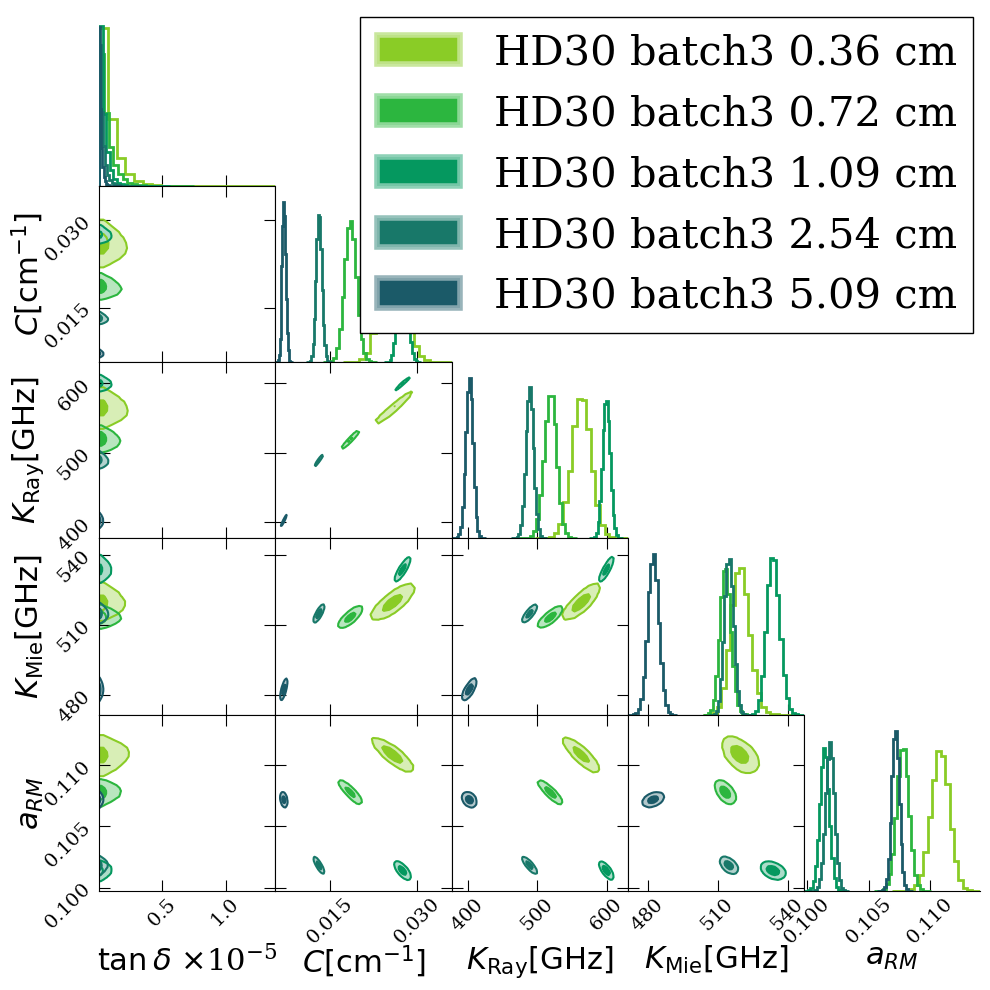

In [76]:
param_names = [r'$\tan\delta$', r'$C [\mathrm{cm}^{-1}]$', r'$K_{\mathrm{Ray}} [\mathrm{GHz}]$', r'$K_{\mathrm{Mie}} [\mathrm{GHz}]$', r'$a_{RM}$']

bname = 'HD30_batch3'
plot_batches = [batch for batch in batches[bname]]

figure = plt.figure(figsize=(10,10))

b = batches[bname]
for sample in b:
    if sample not in plot_batches:
        continue

    print(sample)

    samples      = b[sample]['samples']
    color        = b[sample]['color']

    fig = corner.corner(samples, 
                    show_titles=False, 
                    labels = param_names,            
                    use_math_text = True,
                    label_kwargs={"fontsize": 22},
                    max_n_ticks=3,
                    plot_datapoints=False,
                    show_median=False,
                    show_mean=False,
                    plot_density=False,
                    levels=[0.393, 0.864],
                    fill_contours=True,
                    color=color,
                    hist_kwargs={"linewidth": 2},
                    fig=figure)

for i, ax in enumerate(fig.axes):
    ax.tick_params(axis='both', labelsize=14)
    if i == 0:
        ax.spines['left'].set_visible(False)
    row, col = divmod(i, len(param_names))
    if col < row:
        ax.xaxis.set_tick_params(which='both', direction='in', top=True)
        ax.yaxis.set_tick_params(which='both', direction='in', right=True)
    if col == row:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_facecolor('white')

figure.canvas.draw()

for ax in figure.get_axes():
    if ax.xaxis.get_offset_text().get_text() != '':
        offset = ax.xaxis.get_offset_text().get_text()
        ax.set_xlabel(ax.get_xlabel() + f' {offset}', fontsize=22)
        ax.xaxis.get_offset_text().set_visible(False)
        
    if ax.yaxis.get_offset_text().get_text() != '':
        offset = ax.yaxis.get_offset_text().get_text()
        ax.set_ylabel(ax.get_ylabel() + f' {offset}', fontsize=22)
        ax.yaxis.get_offset_text().set_visible(False)

handles = get_corner_handles(bname, plot_batches)

fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=30, edgecolor='black', facecolor='white', framealpha=1, fancybox=False)

fig.subplots_adjust(hspace=0, wspace=0)
plt.gcf().set_facecolor('white')
# plt.savefig('styro_params-b.pdf', bbox_inches='tight', facecolor='white')
plt.show()

In [104]:
plot_batches

['LD15 batch1 2.65 cm',
 'LD15 batch2 0.30 cm',
 'LD24 batch1 2.60 cm',
 'LD24 batch2 0.34 cm',
 'HD80 2.58 cm',
 'HD110 2.08 cm']

LD15 batch1 2.65 cm
LD15 batch2 0.30 cm
LD24 batch1 2.60 cm
LD24 batch2 0.34 cm
HD80 2.58 cm
HD110 2.08 cm


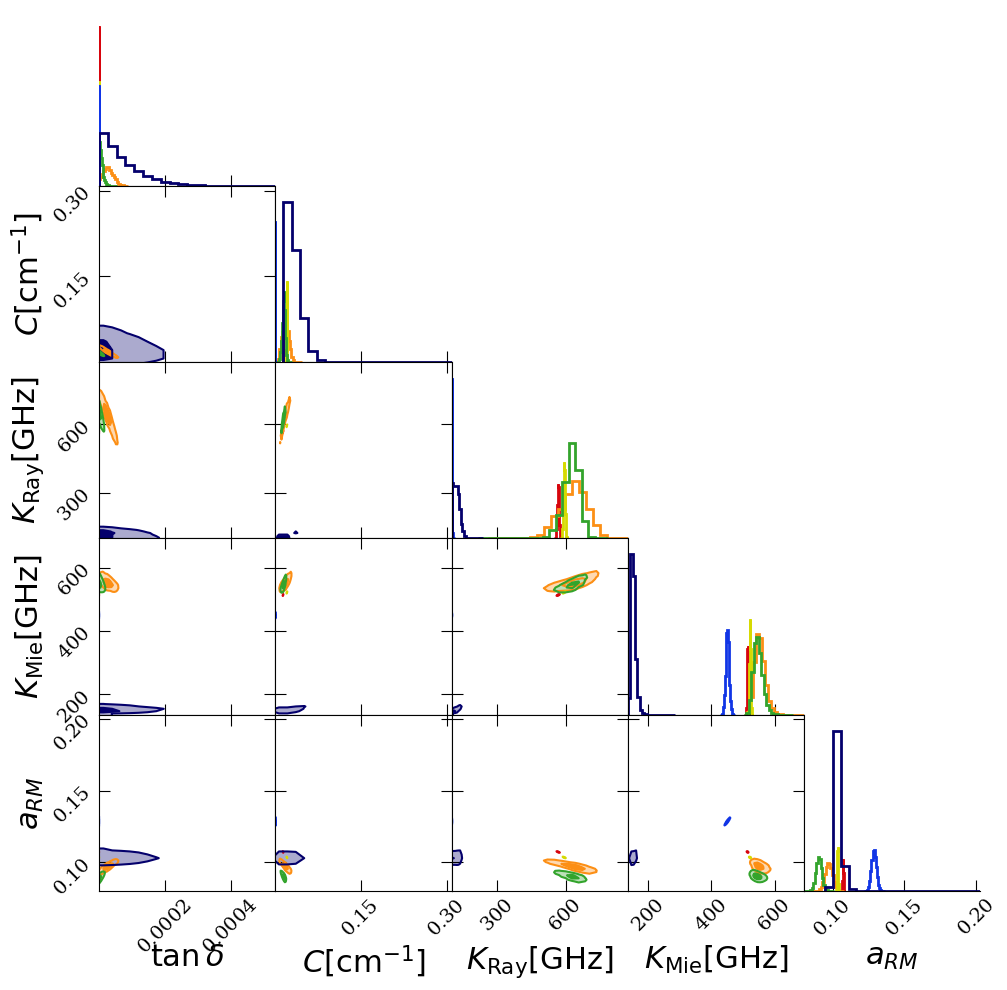

In [108]:
param_names = [r'$\tan\delta$', r'$C [\mathrm{cm}^{-1}]$', r'$K_{\mathrm{Ray}} [\mathrm{GHz}]$', r'$K_{\mathrm{Mie}} [\mathrm{GHz}]$', r'$a_{RM}$']



# plot_batches = [sample for sample in batches[bname] for bname in batches.keys() if bname in other_zote_batches.keys()]

## make plot_batches ONLY include other_zote_batches keys
plot_batches = [sample for sample in other_zote_batches.keys()]


figure = plt.figure(figsize=(10,10))

for bname in plot_batches:
    b = batches[bname]
    for sample in b:
        if sample not in plot_batches:
            continue

        print(sample)

        samples      = b[sample]['samples']
        color        = b[sample]['color']

        fig = corner.corner(samples, 
                        show_titles=False, 
                        labels = param_names,            
                        use_math_text = True,
                        label_kwargs={"fontsize": 22},
                        max_n_ticks=3,
                        plot_datapoints=False,
                        show_median=False,
                        show_mean=False,
                        plot_density=False,
                        levels=[0.393, 0.864],
                        fill_contours=True,
                        color=color,
                        hist_kwargs={"linewidth": 2},
                        fig=figure)

    for i, ax in enumerate(fig.axes):
        ax.tick_params(axis='both', labelsize=14)
        if i == 0:
            ax.spines['left'].set_visible(False)
        row, col = divmod(i, len(param_names))
        if col < row:
            ax.xaxis.set_tick_params(which='both', direction='in', top=True)
            ax.yaxis.set_tick_params(which='both', direction='in', right=True)
        if col == row:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_facecolor('white')

    figure.canvas.draw()

    for ax in figure.get_axes():
        if ax.xaxis.get_offset_text().get_text() != '':
            offset = ax.xaxis.get_offset_text().get_text()
            ax.set_xlabel(ax.get_xlabel() + f' {offset}', fontsize=22)
            ax.xaxis.get_offset_text().set_visible(False)
            
        if ax.yaxis.get_offset_text().get_text() != '':
            offset = ax.yaxis.get_offset_text().get_text()
            ax.set_ylabel(ax.get_ylabel() + f' {offset}', fontsize=22)
            ax.yaxis.get_offset_text().set_visible(False)

    # handles = get_corner_handles(bname, plot_batches)

    # fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=30, edgecolor='black', facecolor='white', framealpha=1, fancybox=False)

    fig.subplots_adjust(hspace=0, wspace=0)
    plt.gcf().set_facecolor('white')
    # plt.savefig('styro_params-b.pdf', bbox_inches='tight', facecolor='white')
    # plt.show()

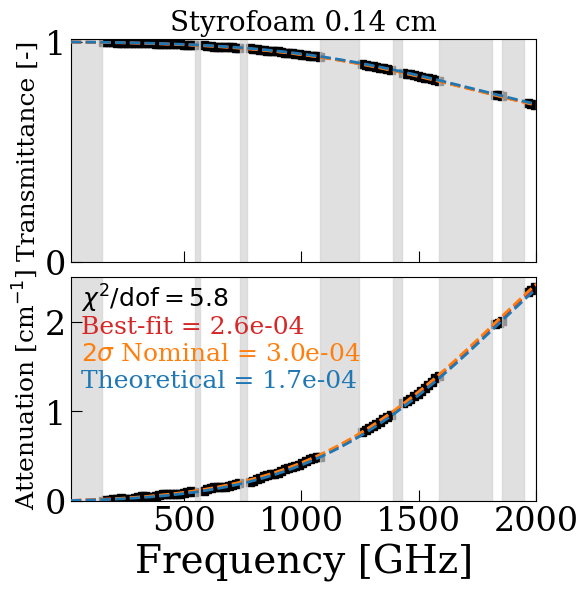

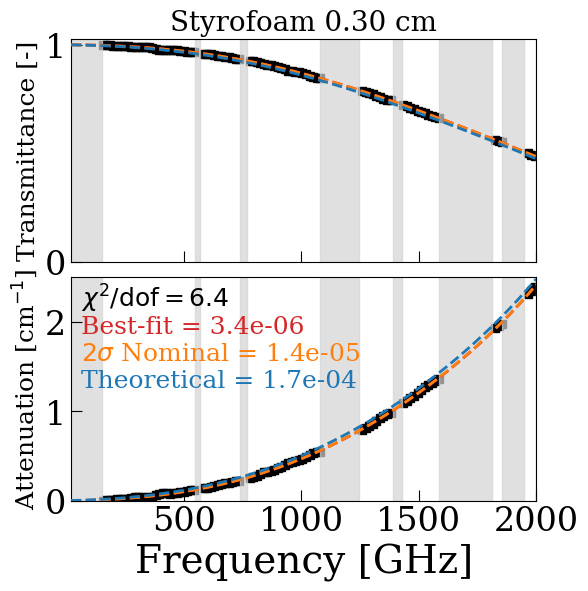

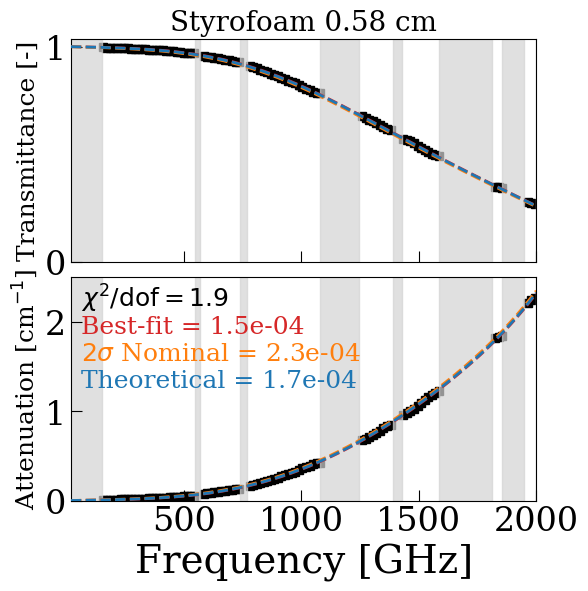

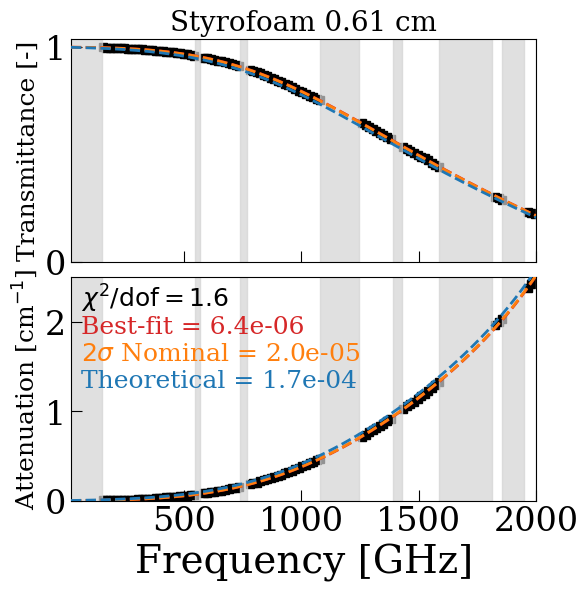

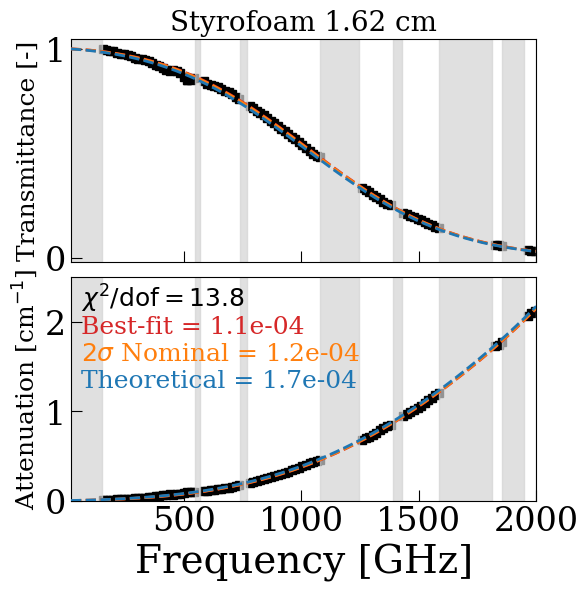

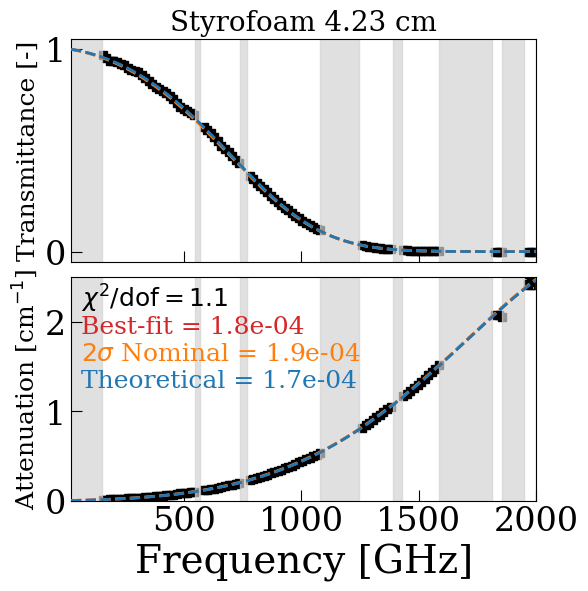

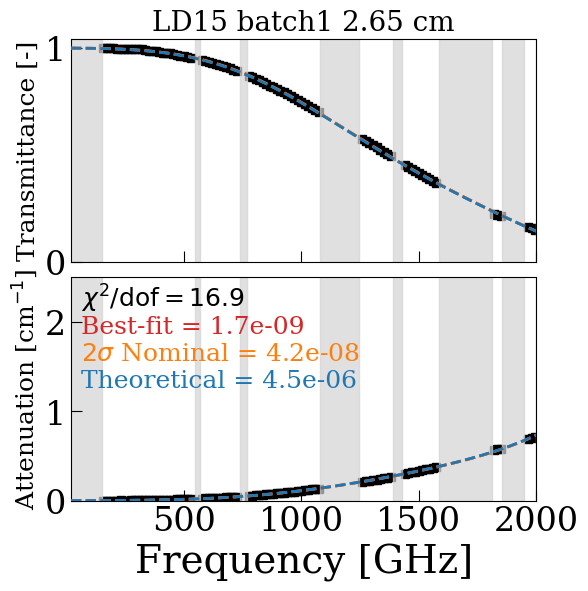

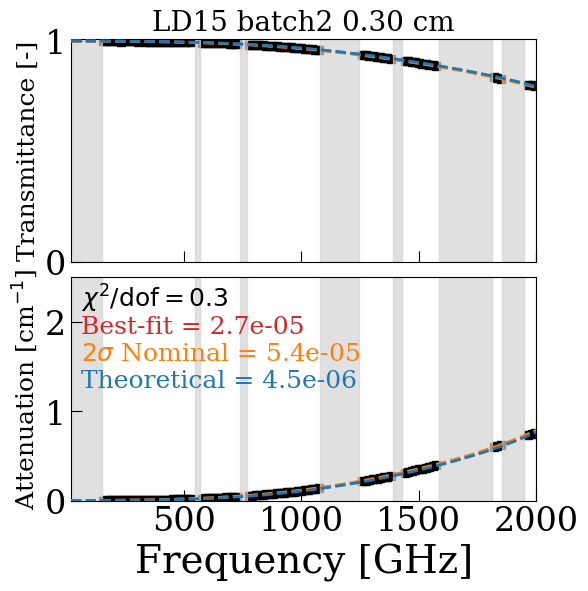

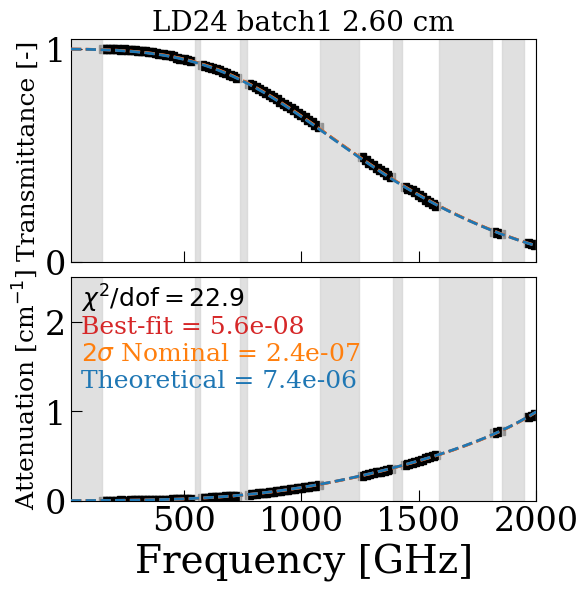

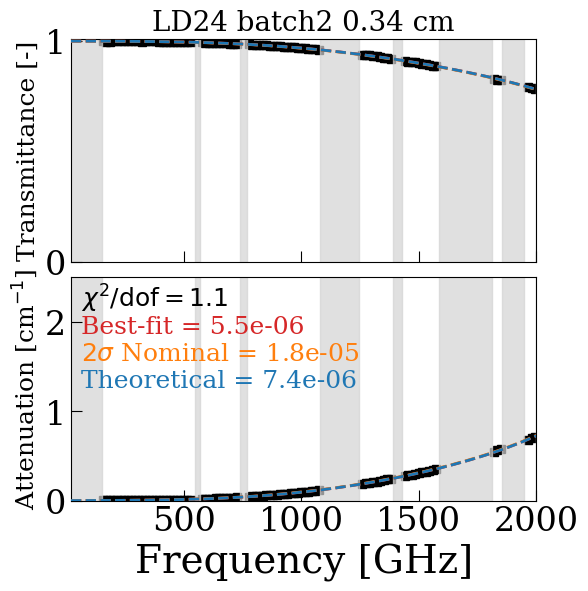

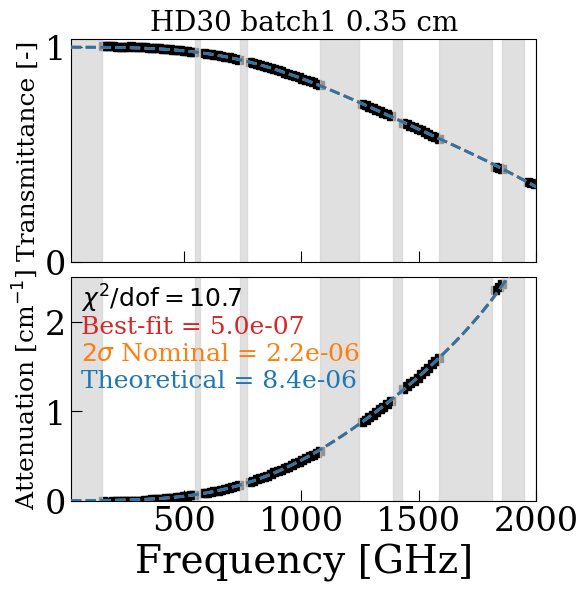

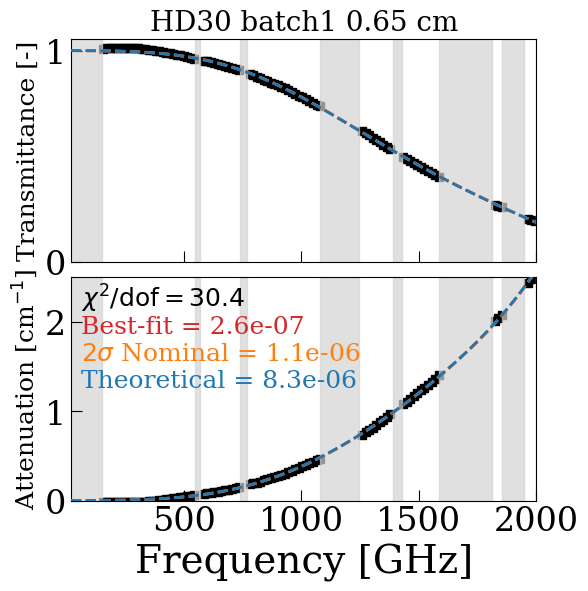

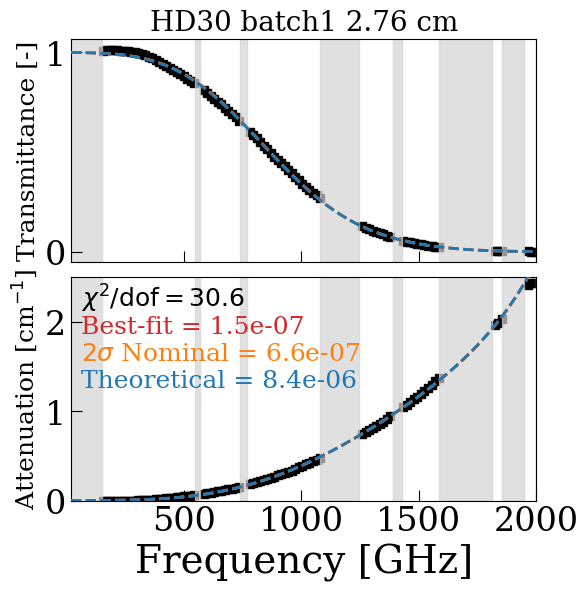

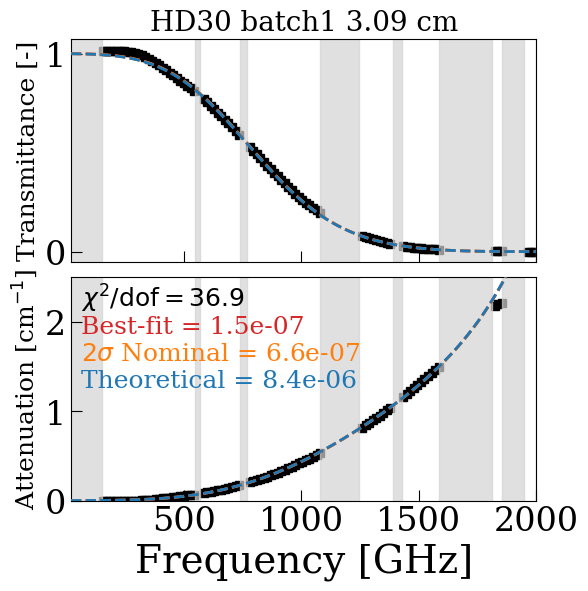

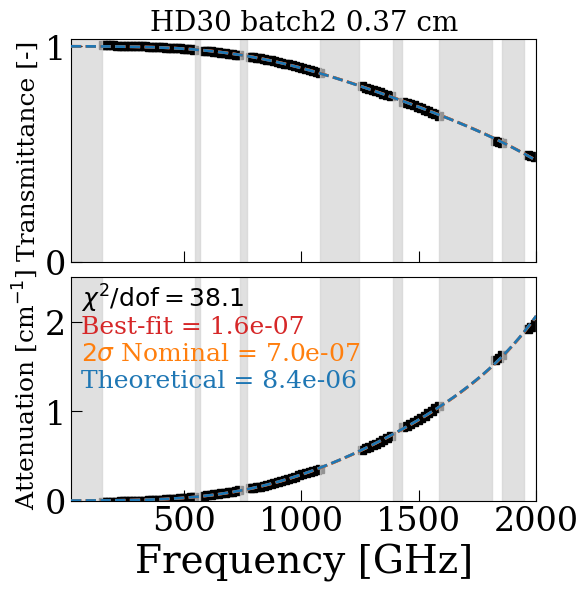

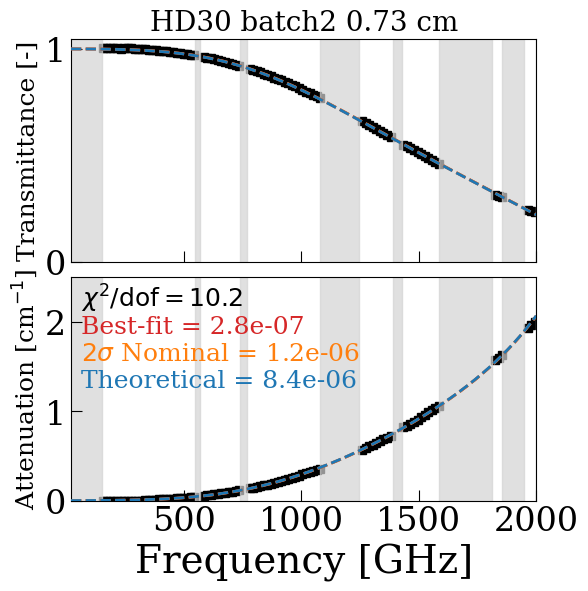

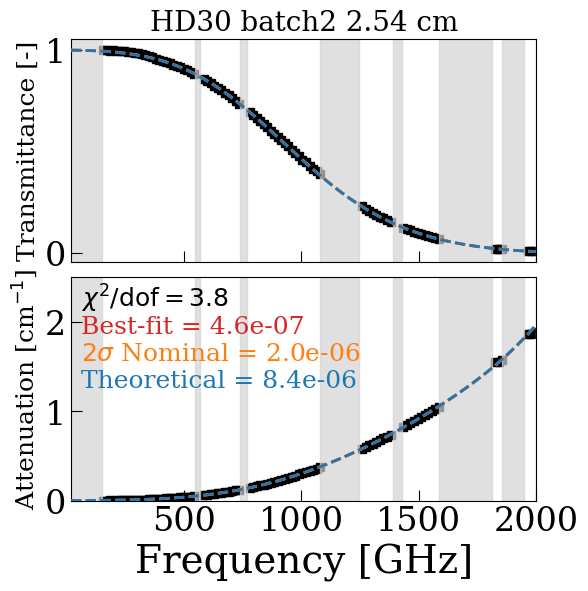

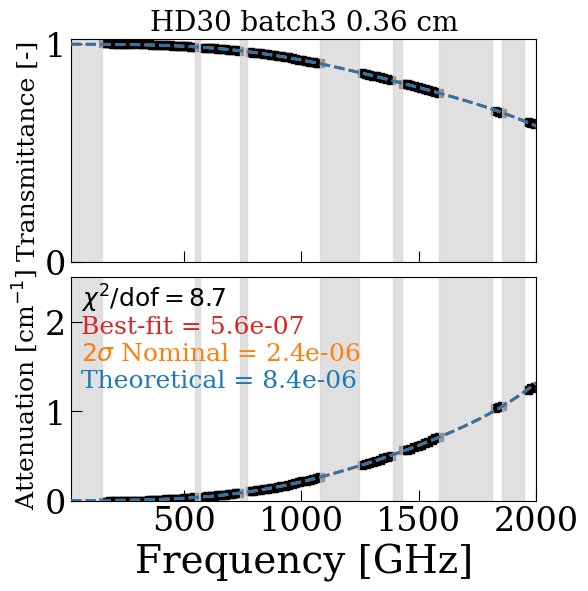

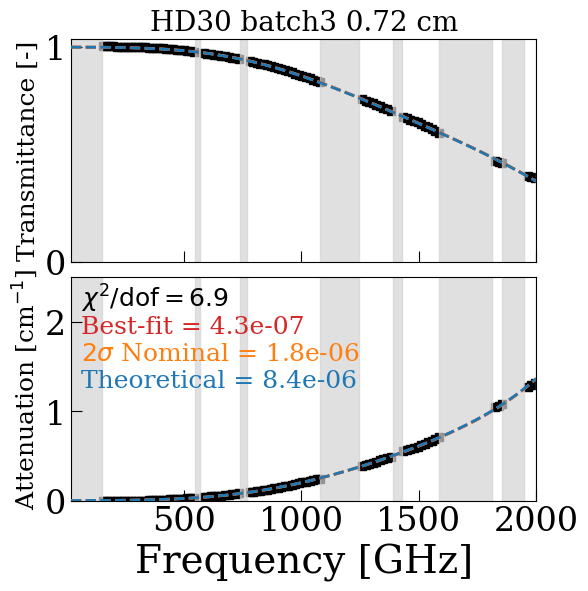

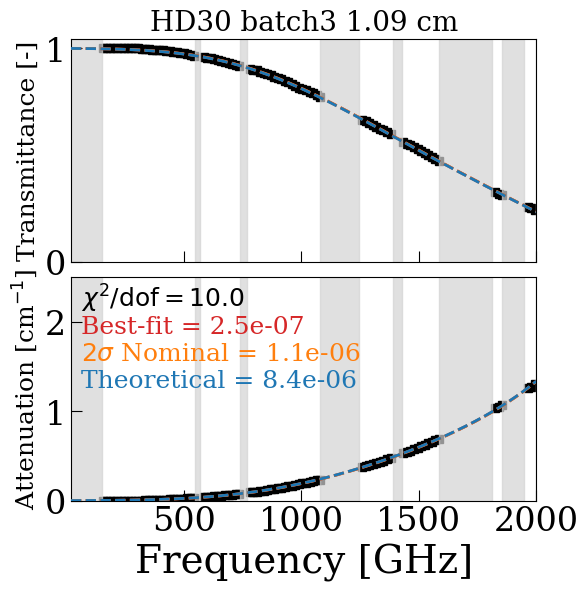

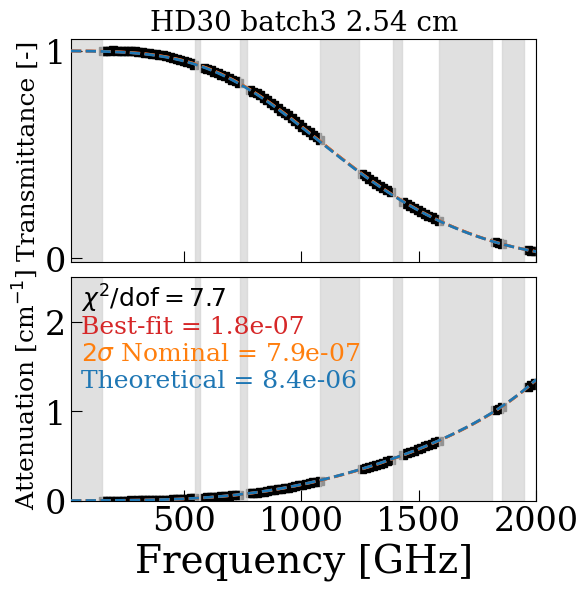

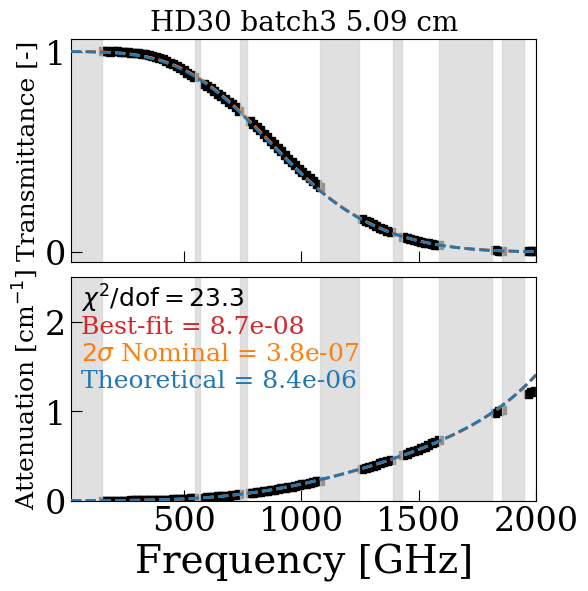

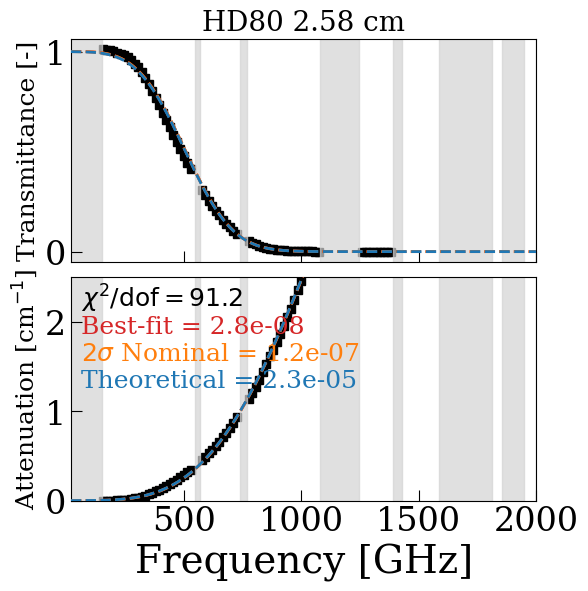

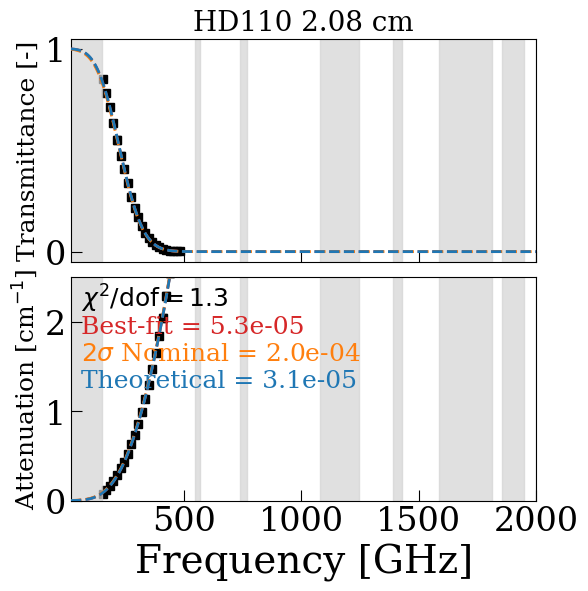

In [ ]:
for bname, b in batches.items():
    for j, sample in enumerate(b):
        fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True, sharey='row')
        ax0, ax1 = axes

        plt.xlim(20, 2000)
        ax1.set_ylim(0, 1.02)
        ax1.set_ylim(0, 2.5)

        ax0.set_ylabel('Transmittance [-]', fontsize=18)
        ax1.set_ylabel('Attenuation [cm$^{-1}$]', fontsize=18)

        lw = 3

        ax1.set_xlabel('Frequency [GHz]', fontsize=28)

        f_          = b[sample]['f_binned']
        t           = b[sample]['t_binned']
        alpha       = b[sample]['alpha_binned']
        err         = b[sample]['err_binned']
        width       = b[sample]['width']
        alpha_err   = err/(width * t)
        color       = b[sample]['color']


        mask   = b[sample]['mask']
        boxnum = b[sample]['boxnum']

        params = batches[bname][sample]['params']

        ns_T = IRBF_njit(f_, params, width, n_eff)
        redchi2 = float(np.sum((ns_T - t) ** 2 / err ** 2)) / (len(f_) - 5)

        ax0.errorbar(f_, t, yerr=err, color='k', fmt='s', ms=6, capsize=3, zorder=-10)
        ax1.errorbar(f_, alpha, yerr=alpha_err, color='k', fmt='s', ms=6, capsize=3, label='Data', zorder=-10)

        ns_alpha = batches[bname][sample]['ns_alpha']
        ns_T     = np.exp(-width*ns_alpha)

        ax0.plot(f, ns_T, color='tab:red', linestyle='--', label='Best fit', lw=2, zorder=10)

        ax1.plot(f, ns_alpha, color='tab:red', linestyle='--', label='Best fit', lw=2, zorder=10)

        n_eff      = batches[bname][sample]['n_eff']
        lt_nominal = batches[bname][sample]['upper_params'][0]
        lt_est     = batches[bname][sample]['lt']

        alpha_nominal   = IRBF_alpha_njit(f, [lt_nominal, *params[1:]], n_eff)
        alpha_est       = IRBF_alpha_njit(f, [lt_est, *params[1:]], n_eff)

        T_nominal       = np.exp(-width*alpha_nominal)
        T_est           = np.exp(-width*alpha_est)

        ax0.plot(f, T_nominal, color='tab:orange', linestyle='--', label=r'$2\sigma$ nominal $\tan\delta$', lw=2, zorder=10)
        ax0.plot(f, T_est, color='tab:blue', linestyle='--', label=r'theoretical $\tan\delta$', lw=2, zorder=10)

        ax1.plot(f, alpha_nominal, color='tab:orange', linestyle='--', label=r'$2\sigma$ nominal $\tan\delta$', lw=2, zorder=10)
        ax1.plot(f, alpha_est, color='tab:blue', linestyle='--', label=r'Theoretical $\tan\delta$', lw=2, zorder=10)

        for ax in axes:
            for i, j in zip(mask_starts, mask_stops):
                ax.axvspan(i, j, color='lightgray', alpha=0.7)

        handles = ax1.get_legend_handles_labels()[0]

        # fig.legend(handles=handles, fontsize=20, frameon=True, bbox_to_anchor=(0.9, 0.5), loc='center left', ncol=1)

        ax0.set_yticks([0, 1])
        ax1.set_yticks([0, 1, 2])
        
        ax0.set_title(rf'{sample}', fontsize=20)
        ax1.annotate(rf'$\chi^2/{{\rm dof}}={redchi2:.1f}$', xy=(0.02, 0.87), ha='left', xycoords='axes fraction', fontsize=18)
        ax1.annotate(f'Best-fit = {params[0]:.1e}', xy=(0.02, 0.75), ha='left', color='tab:red', xycoords='axes fraction', fontsize=18)
        ax1.annotate(rf'$2\sigma$ Nominal = {lt_nominal:.1e}', xy=(0.02, 0.63), ha='left', color='tab:orange', xycoords='axes fraction', fontsize=18)
        ax1.annotate(rf'Theoretical = {lt_est:.1e}', xy=(0.02, 0.51), ha='left', color='tab:blue', xycoords='axes fraction', fontsize=18)

        plt.gcf().set_facecolor('white')
        plt.subplots_adjust(wspace=0.07, hspace=0.07)
        plt.show()

In [78]:
# bname = 'Styrofoam_batch'

# ns_params = comb_batches[bname]['params']
# n_eff     = comb_batches[bname]['n_eff']
# alpha16, alpha50, alpha84 = comb_batches[bname]['alpha_lower'], comb_batches[bname]['ns_alpha'], comb_batches[bname]['alpha_upper']
# lt = comb_batches[bname]['lt']

# idx = np.argmin(np.abs(f - 200))
# mu = np.exp(-0.1*alpha50[idx])
# low = np.exp(-0.1*alpha84[idx])
# up = np.exp(-0.1*alpha16[idx])
# sig = (up - low)/2
# print(f"Styrofoam per mm Tranmission @ 200 GHz: {mu:.6f}±{sig:.6f}")

# idx = np.argmin(np.abs(f - 280))
# loss = IRBF_abs(280, lt, 5, n_eff)
# print(f"For a {w} cm filter\n-----")
# print(f"loss @ 280 GHz: {loss:.5f}%")
# mu = np.exp(-w * alpha50[idx])
# low = np.exp(-w * alpha84[idx])
# up = np.exp(-w * alpha16[idx])
# sig = (up - low)/2
# print(f"Tranmission @ 280 GHz: {mu:.5f}±{sig:.5f}")

# bname = 'HD30_batch1'

# ns_params = comb_batches[bname]['params']
# n_eff     = comb_batches[bname]['n_eff']
# alpha16, alpha50, alpha84 = comb_batches[bname]['alpha_lower'], comb_batches[bname]['ns_alpha'], comb_batches[bname]['alpha_upper']
# lt = comb_batches[bname]['lt']

# idx = np.argmin(np.abs(f - 280))
# loss = IRBF_abs(280, lt, 5, n_eff)
# print(f"For a {w} cm HD30 filter\n-----")
# print(f"loss @ 280 GHz: {loss:.5f}%")
# mu = np.exp(-w * alpha50[idx])
# low = np.exp(-w * alpha84[idx])
# up = np.exp(-w * alpha16[idx])
# sig = (up - low)/2
# print(f"Tranmission @ 280 GHz: {mu:.5f}±{sig:.5f}")

In [79]:
# bname = 'Styrofoam_batch'
# Mie_lower, Mie, Mie_upper = float(comb_batches[bname]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie_upper')])
# Ray_lower, Ray, Ray_upper = float(comb_batches[bname]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray_upper')])

# Scatter = Mie + Ray
# Scatter_lower = np.sqrt(Mie_lower**2 + Ray_lower**2)
# Scatter_upper = np.sqrt(Mie_upper**2 + Ray_upper**2)

# print(f"280 GHz Scattering for {bname}: {Scatter:.5f}% +{Scatter_upper:.5f}% -{Scatter_lower:.5f}%")

# Scatters = []
# for bname in HD30_batches:
#     Mie_lower, Mie, Mie_upper = float(comb_batches[bname]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie_upper')])
#     Ray_lower, Ray, Ray_upper = float(comb_batches[bname]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray_upper')])

#     Scatter = Mie + Ray
#     Scatters.append(Scatter)

# Scatter = np.mean(Scatters)
# Scatter_std = np.std(Scatters)

# print(f"280 GHz Scattering for {bname}: {Scatter:.1f}% ±{Scatter_std:.1f}%")

# bname = 'LD15 batch1 2.65 cm'
# Mie_lower, Mie, Mie_upper = float(comb_batches[bname]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie_upper')])
# Ray_lower, Ray, Ray_upper = float(comb_batches[bname]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray_upper')])

# Scatter = Mie + Ray
# Scatter_lower = np.sqrt(Mie_lower**2 + Ray_lower**2)
# Scatter_upper = np.sqrt(Mie_upper**2 + Ray_upper**2)

# print(f"280 GHz Scattering for {bname}: {Scatter:.5f}% +{Scatter_upper:.5f}% -{Scatter_lower:.5f}%")

In [80]:
# bname = 'Styrofoam_batch'
# Ray_lower, Ray, Ray_upper = float(comb_batches[bname]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray_upper')])
# Mie_lower, Mie, Mie_upper = float(comb_batches[bname]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie_upper')])
# Abs_lower, Abs, Abs_upper = float(comb_batches[bname]['band_avgs'][('280', 'Abs_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Abs')]), float(comb_batches[bname]['band_avgs'][('280', 'Abs_upper')])

# ## Difference
# # bname2 = 'Styrofoam_batch2'
# bname2 = 'HD30_batch3'
# Ray_lower2, Ray2, Ray_upper2 = float(comb_batches[bname2]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname2]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname2]['band_avgs'][('280', 'Ray_upper')])
# Mie_lower2, Mie2, Mie_upper2 = float(comb_batches[bname2]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname2]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname2]['band_avgs'][('280', 'Mie_upper')])
# Abs_lower2, Abs2, Abs_upper2 = float(comb_batches[bname2]['band_avgs'][('280', 'Abs_lower')]), float(comb_batches[bname2]['band_avgs'][('280', 'Abs')]), float(comb_batches[bname2]['band_avgs'][('280', 'Abs_upper')])

# Ray_lower_diff = np.sqrt(Ray_lower**2 + Ray_upper2**2)
# Ray_diff = Ray - Ray2
# Ray_upper_diff = np.sqrt(Ray_upper**2 + Ray_lower2**2)

# Mie_lower_diff = np.sqrt(Mie_lower**2 + Mie_upper2**2)
# Mie_diff = Mie - Mie2
# Mie_upper_diff = np.sqrt(Mie_upper**2 + Mie_lower2**2)

# Abs_lower_diff = np.sqrt(Abs_lower**2 + Abs_upper2**2)
# Abs_diff = Abs - Abs2
# Abs_upper_diff = np.sqrt(Abs_upper**2 + Abs_lower2**2)

# print(f"280 GHz difference between {bname} and {bname2}:")      
# print(f"Rayleigh: {Ray_diff:.2f} +{Ray_upper_diff:.2f} -{Ray_lower_diff:.2f}")
# print(f"Mie: {Mie_diff:.2f} +{Mie_upper_diff:.2f} -{Mie_lower_diff:.2f}")
# print(f"Sum: {(Ray_diff + Mie_diff):.2f} +{np.sqrt(Ray_upper_diff**2 + Mie_upper_diff**2):.2f} -{np.sqrt(Ray_lower_diff**2 + Mie_lower_diff**2):.2f}")
# print(f"Absorption: {Abs_diff:.2f} +{Abs_upper_diff:.2f} -{Abs_lower_diff:.2f}")

## Optical Loading Table

In [81]:
T_high = 273.0  # K
T_low  = 44.0   # K

# --- Layer temperatures (closed-form) ---
def T_eff_from_N_d(N, d):
    i    = np.arange(1, N+1)
    T    = (T_high**4 - i/(N+1) * (T_high**4 - T_low**4))**0.25
    T_eff = np.sum(d * T) / np.sum(d)
    return T_eff

N = 24
d = np.ones(N) * 1.5
d[0] = d[-1] = 6.0

T_eff_styro = T_eff_from_N_d(N, d)

N = 16
d = np.ones(N) * 0.3175

T_eff_zote_SAT = T_eff_from_N_d(N, d)

N = 14
d = np.ones(N) * 0.3175
d[0] = 2.54

T_eff_zote_LAT = T_eff_from_N_d(N, d)

print(f"T_eff = {T_eff_styro:.0f} K")
print(f"T_eff = {T_eff_zote_SAT:.0f} K")
print(f"T_eff = {T_eff_zote_LAT:.0f} K")

T_eff = 215 K
T_eff = 221 K
T_eff = 237 K


In [82]:
# from scipy.constants import k
# Tphys = 273
# Npol = 1

# bands = ['90', '150', '220', '280']
# bandwidths = [35.0, 45.0, 45.0, 65.0]  # GHz

# loading_batches = [
#     ('Styrofoam', comb_batches['Styrofoam_batch']),
#     ('LD15', comb_batches['LD15 batch1 2.65 cm']),
#     ('LD24', comb_batches['LD24 batch1 2.60 cm']),
#     ('HD30', comb_batches['HD30_batch3']),
# ]

# for name, b in loading_batches:

#     row_entries_odd = [name]
#     row_entries_even = ['']

#     for i, (band, dnu) in enumerate(zip(bands, bandwidths)):

#         row_entries = row_entries_odd if i % 2 == 0 else row_entries_even

#         Abs = float(b['band_avgs'][(band, 'Abs')]) / 100.0

#         T_RJ = Tphys * Abs
#         P = Npol * k * T_RJ * dnu * 1e21   # convert GHz → Hz and Watts → pW

#         if name in ['Thin Sheets 1 (Worst)', 'Thick Sheets 2 (Best)', 'Representative Filter']:
#             Abs_lower = float(b['band_avgs'][(band, 'Abs_lower')]) / 100.0
#             Abs_upper = float(b['band_avgs'][(band, 'Abs_upper')]) / 100.0  
#             T_RJ_lower = Tphys * Abs_lower
#             T_RJ_upper = Tphys * Abs_upper
#             P_lower = Npol * k * T_RJ_lower * dnu * 1e21
#             P_upper = Npol * k * T_RJ_upper * dnu * 1e21

#             row_entries.extend([
#                 format_unc(Abs, Abs_lower, Abs_upper, sci_thresh=0.01),
#                 format_unc(T_RJ, T_RJ_lower, T_RJ_upper, sci_thresh=0.01),
#                 format_unc(P, P_lower, P_upper, sci_thresh=0.01),
#             ])
                
#         elif name in ['LD15', 'LD24', 'HD30']:
#             row_entries.extend([
#                 format_val(Abs),
#                 format_val(T_RJ),
#                 format_val(P)
#             ])

#         else:
#             row_entries.extend([
#                 f"{Abs:.4f}",
#                 f"{T_RJ:.2f}",
#                 f"{P:.2f}"
#             ])

#     print(" & ".join(row_entries_odd) + r" \\")
#     print(" & ".join(row_entries_even) + r" \\[6pt]")

In [83]:
# rows = []

# param_names = ["Loss tangent", "C", "K_ray", "K_Mie", "a_RM"]

# for bname, b in comb_batches.items():
#     T_lower, ns_T, T_upper = b['T_lower_5cm'], b['ns_T_5cm'], b['T_upper_5cm']

#     row = {"Sample": bname}

#     # --- parameters with uncertainties ---
#     for i, pname in enumerate(param_names):
#         val = float(b['params'][i])
#         up  = float(b['upper_params'][i])
#         lo  = float(b['lower_params'][i])

#         row[pname] = format_unc(val, lo, up)

#     row["n_eff^2"] = rf"${b['n_eff']:.3f} \pm {b['n_eff_err']:.4f}$"

#     # --- band-averaged transmittance ---
#     for band_name, (lo_f, hi_f) in band_windows_full.items():
#         sel = (f > lo_f) & (f < hi_f)

#         val       = 100*float(np.mean(ns_T[sel]))
#         upper_val = 100*float(np.mean(T_upper[sel]))
#         lower_val = 100*float(np.mean(T_lower[sel]))

#         up = upper_val - val
#         lo = val - lower_val

#         # row[f"T{band_name} [%]"] = format_unc(val, lo, up)

#     rows.append(row)

# df = pd.DataFrame(rows)
# df


In [84]:
# DISPLAY_MAP2 = {

#     "LD15 batch1 2.65 cm": ["LD15 batch 1", colors2[0], '-'],
#     "LD15 batch2 0.30 cm": ["LD15 batch 2", colors2[0], '--'],
#     "LD24 batch2 0.34 cm": ["LD24 batch 2", colors2[1], '-'],
#     "LD24 batch1 2.60 cm": ["LD24 batch 1", colors2[1], '--'],
#     "HD30_batch3": ["HD30 batch 3", comb_batches['HD30_batch1']['color'], '-'],
#     "HD30_batch1": ["HD30 batch 1", comb_batches['HD30_batch1']['color'], '--'],
#     "Styrofoam_batch": ["Styrofoam", 'k', '-'],
# }

# fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

# # Plot measurements and fits
# for bname in DISPLAY_MAP2.keys():
#     b = comb_batches[bname]
#     label, color, ls = DISPLAY_MAP2[bname]

#     ns_T = b['ns_T_5cm']

#     plt.plot(f, ns_T, color=color, lw=5, label=label, linestyle=ls, alpha=0.7)

# handles = ax.get_legend_handles_labels()[0]

# xticks = []
# for band, (i, j) in band_windows_full.items():
#     plt.axvspan(i, j, color='gray', alpha=0.3)
#     plt.text((i+j)/2, 0.80, band, horizontalalignment='center', verticalalignment='bottom', fontsize=18, color='black', fontweight='bold')

# ax.legend(handles=handles, loc='lower left', bbox_to_anchor=(0.01, 0.05), fontsize=30, edgecolor='black', facecolor='white', framealpha=1, fancybox=False)

# plt.xlim(20, 1000)
# ax.yaxis.set_major_locator(MultipleLocator(0.05))
# plt.ylim(0.8, 1.01)
# plt.xscale('log')

# plt.xlabel('Frequency [GHz]', fontsize=42)
# plt.ylabel('Normalized 5 cm\nTransmittance [-]', fontsize=42)
# plt.gcf().set_facecolor('white')
# plt.savefig('5cm_spectra-c.pdf', bbox_inches='tight', facecolor='white')
# plt.show()

In [85]:
# rows = []

# # header = ["Sample"] + [f"T{band} [%]" for band in band_windows_full.keys()]
# # rows.append(dict(zip(header, header)))

# for bname, b in list(comb_batches.items()):
#     if bname not in ['Styrofoam_batch', 'LD15 batch1 2.65 cm', 'LD15 batch2 0.30 cm', 'LD24 batch1 2.60 cm', 'LD24 batch2 0.34 cm', 'HD30_batch1', 'HD30_batch2', 'HD30_batch3', 'HD80 2.58 cm', 'HD110 2.08 cm']:
#         continue

#     row = {"Sample": bname}
    
#     T_lower, ns_T, T_upper = b['T_lower_5cm'], b['ns_T_5cm'], b['T_upper_5cm']

#     # --- band-averaged transmittance ---
#     for band_name, (lo_f, hi_f) in band_windows_full.items():
#         sel = (f > lo_f) & (f < hi_f)

#         val = 100*float(np.mean(ns_T[sel]))
#         upper_val = 100*float(np.mean(T_upper[sel]))
#         lower_val = 100*float(np.mean(T_lower[sel]))

#         up = upper_val - val
#         lo = val - lower_val

#         row[f"T{band_name} [%]"] = format_unc(val, lo, up)

#     rows.append(row)

# df = pd.DataFrame(rows)
# df

# # for _, row in df.iterrows():
# #     cells = [row["Sample"]] + [row[f"T{band} [%]"] for band in band_windows_full.keys()]
# #     print(" & ".join(cells) + r" \\")

# Estimating Cell Sizes

In [86]:
batches[bname].keys()

dict_keys(['HD110 2.08 cm'])

In [87]:
rows = []

def _cm_factor(n_p):
    np2 = n_p**2
    return np.abs((np2 + 2)*(1 + 2*np2) - 2*(np2 - 1)**2) / np.abs((1 + 2*np2)*(np2 - 1))

def eff_cell_diameter(K_Mie_GHz, K_Ray_GHz, n_p=1.54, n_m=1.0003, c=3e8):
    m   = n_p / n_m
    return c * (m - 1) * K_Mie_GHz*1e9 / (n_m * np.pi * np.sqrt(6) * (K_Ray_GHz*1e9)**2) * _cm_factor(n_p)

def eff_wall_thickness(K_Mie_GHz, d, C, f_m, n_p=1.54, n_m=1.0003, c=3e8):
    m   = n_p / n_m
    C_m = C * 100
    return c / (2 * n_m * np.pi * (m - 1) * K_Mie_GHz*1e9) * np.sqrt(C_m * d / (6 * f_m))

def wall_thickness(d, f_m):
    return d/2 * (1 - f_m**(1/3))


for bname, b in batches.items():
    for sample in batches[bname].keys():
        if 'HD' in bname or 'LD' in bname:
            zote_type = bname.split('_')[0].split(' ')[0]

            if zote_type == 'LD15':
                batches[bname][sample]['cell_size'] = 380e-6

            elif zote_type == 'LD24':
                batches[bname][sample]['cell_size'] = 300e-6
            
            elif zote_type == 'HD30':
                batches[bname][sample]['cell_size'] = 400e-6

            elif zote_type == 'HD80':
                batches[bname][sample]['cell_size'] = 600e-6
            
            elif zote_type == 'HD110':
                batches[bname][sample]['cell_size'] = 1050e-6
        else:
            continue

        density = b[sample]['density']
        rho_p   = b[sample]['rho_p']
        n_p     = b[sample]['n_p']
        f_p     = b[sample]['f_p']

        C       = b[sample]['params'][1]
        K_Ray   = b[sample]['params'][2]
        K_Mie   = b[sample]['params'][3]

        d_inv = eff_cell_diameter(K_Mie, K_Ray, n_p=n_p)

        f_m = 1 - f_p
        ell   = eff_wall_thickness(K_Mie, d_inv, C, f_m, n_p=n_p)
        l_th  = wall_thickness(b[sample]['cell_size'], f_m)

        rows.append({
            "sample":           bname,
            "density [kg/m^3]": b[sample]["density"],
            "d_th [um]":        f"{b[sample]['cell_size'] * 1e6:.2f}",
            "ell_th [um]":      f"{l_th * 1e6:.2f}",
            "ell_th/d_th":      f"{l_th / (b[sample]['cell_size']):.2e}",
            "d [um]":           f"{d_inv * 1e6:.2f}",
            "ell [um]":         f"{ell * 1e6:.2f}",
            "ell/d":            f"{ell / d_inv:.2e}",
        })

df = pd.DataFrame(rows).set_index("sample").sort_values("density [kg/m^3]")
df

,density [kg/m^3],d_th [um],ell_th [um],ell_th/d_th,d [um],ell [um],ell/d
sample,,,,,,,
LD15 batch1 2.65 cm,15.0,380.00,0.95,2.49e-03,91.57,0.83,9.12e-03
LD15 batch2 0.30 cm,15.0,380.00,0.95,2.49e-03,78.08,0.82,1.05e-02
LD24 batch1 2.60 cm,24.0,300.00,1.24,4.14e-03,84.88,0.97,1.15e-02
LD24 batch2 0.34 cm,24.0,300.00,1.24,4.14e-03,79.15,0.76,9.67e-03
HD30_batch1,30.0,400.00,2.04,5.10e-03,127.81,1.44,1.13e-02
HD30_batch1,30.0,400.00,2.04,5.10e-03,116.77,1.34,1.15e-02
HD30_batch1,30.0,400.00,2.04,5.10e-03,139.56,1.31,9.41e-03
HD30_batch1,30.0,400.00,2.04,5.10e-03,140.12,1.41,1.01e-02
HD30_batch2,30.0,400.00,2.04,5.10e-03,143.78,1.10,7.65e-03


# Custom loss plots

Secondary scattering matters for HD110 in band, matters for HD80 after ~300 GHz.

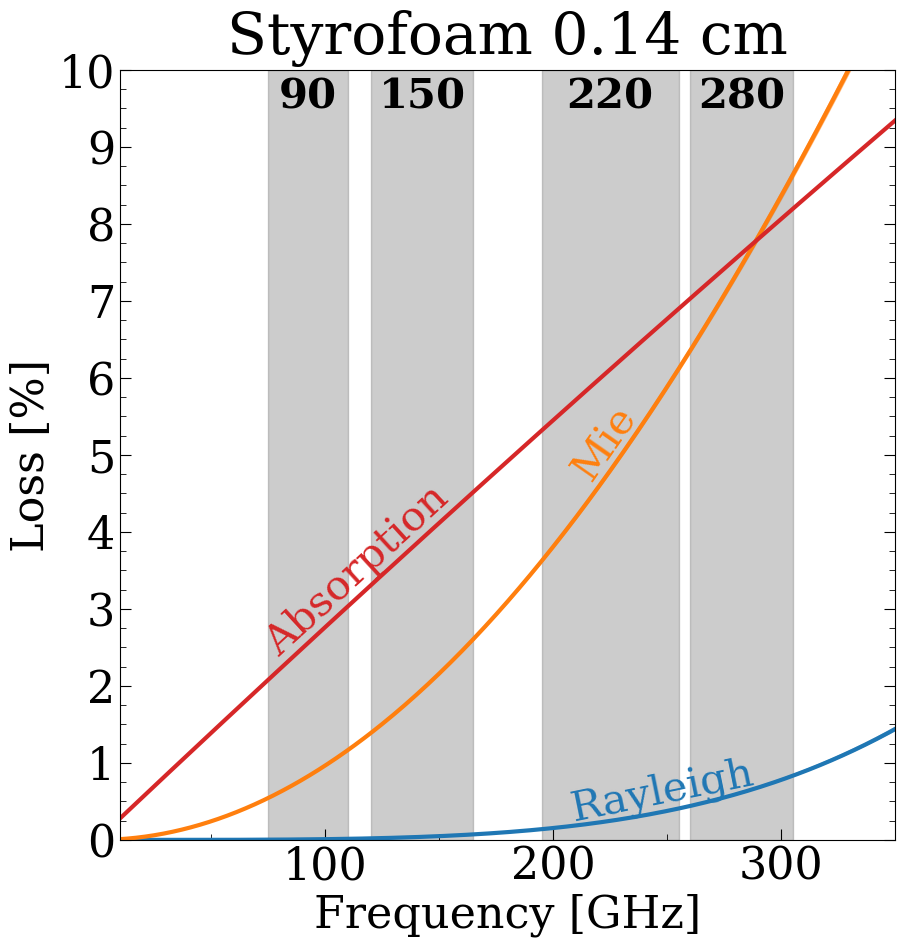

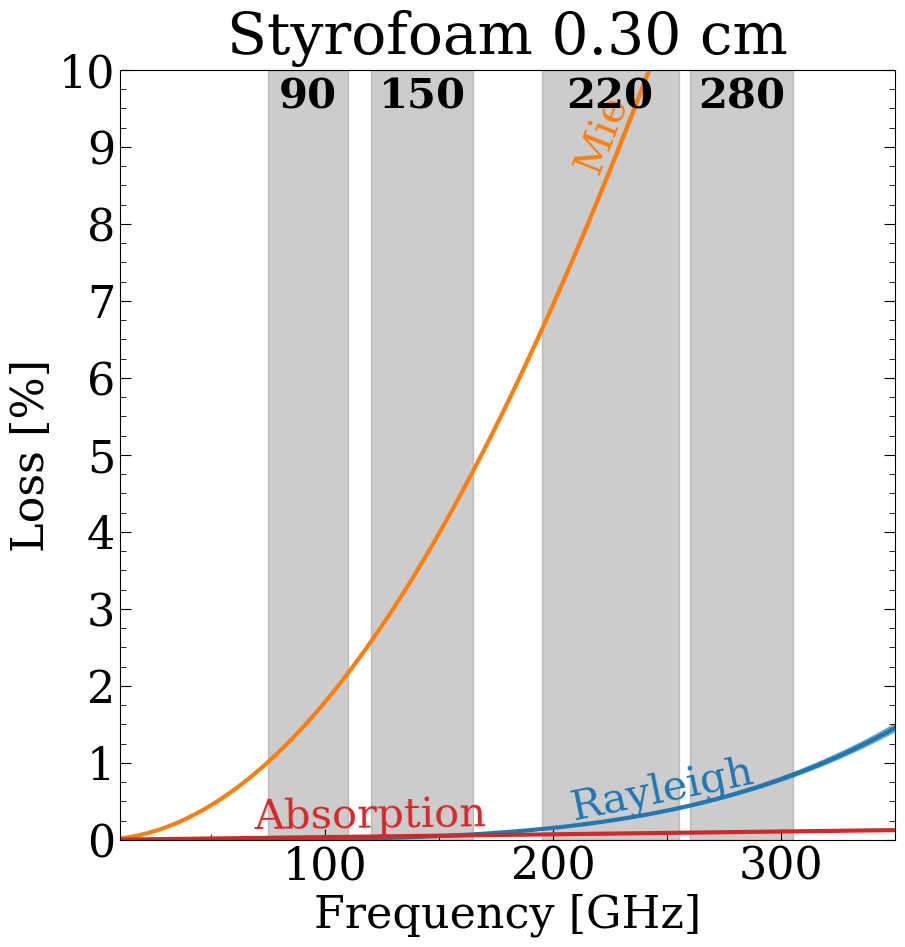

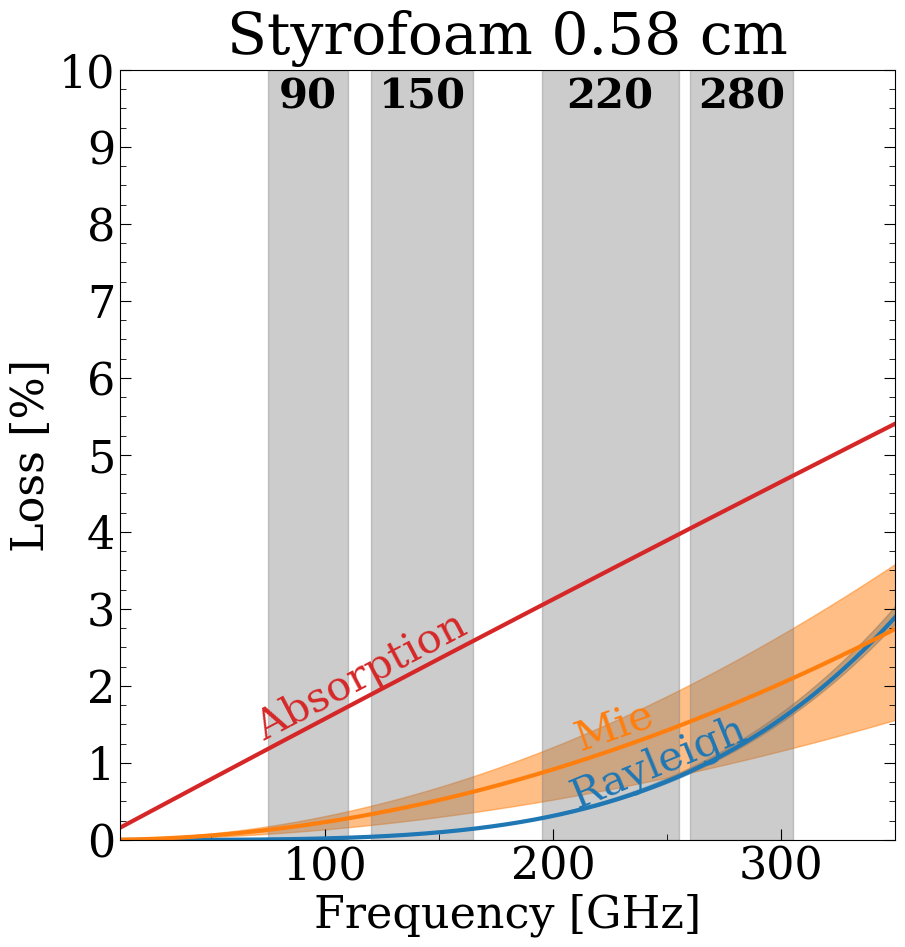

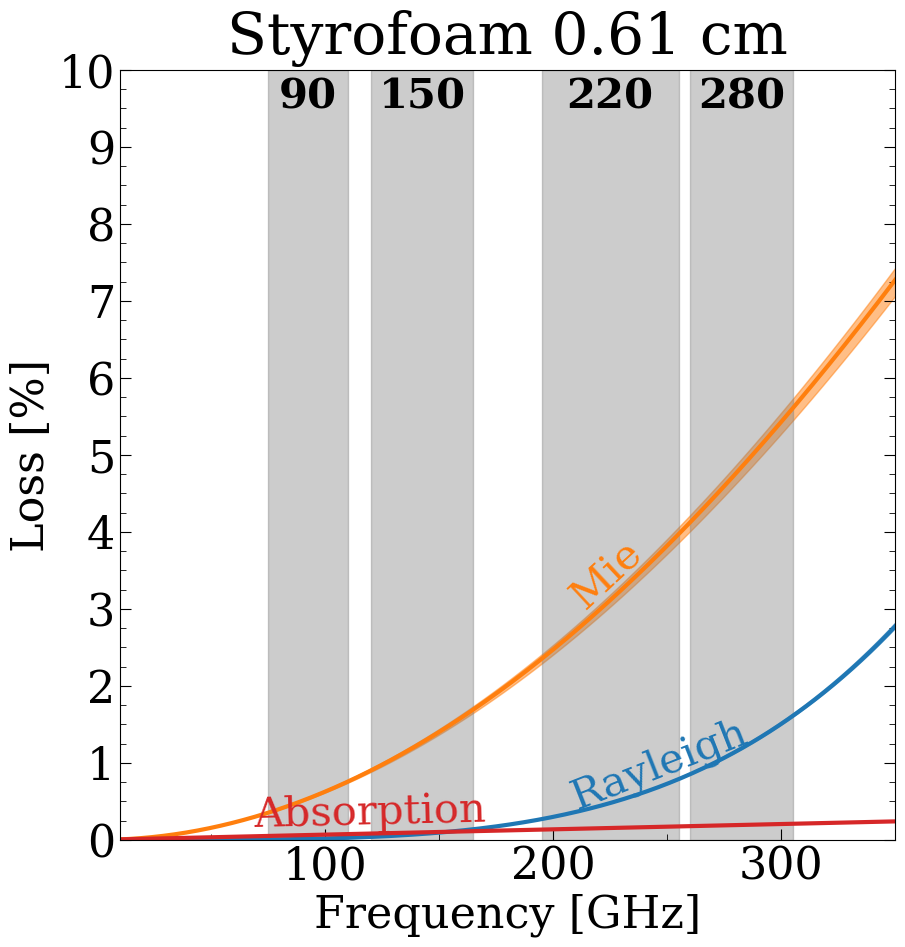

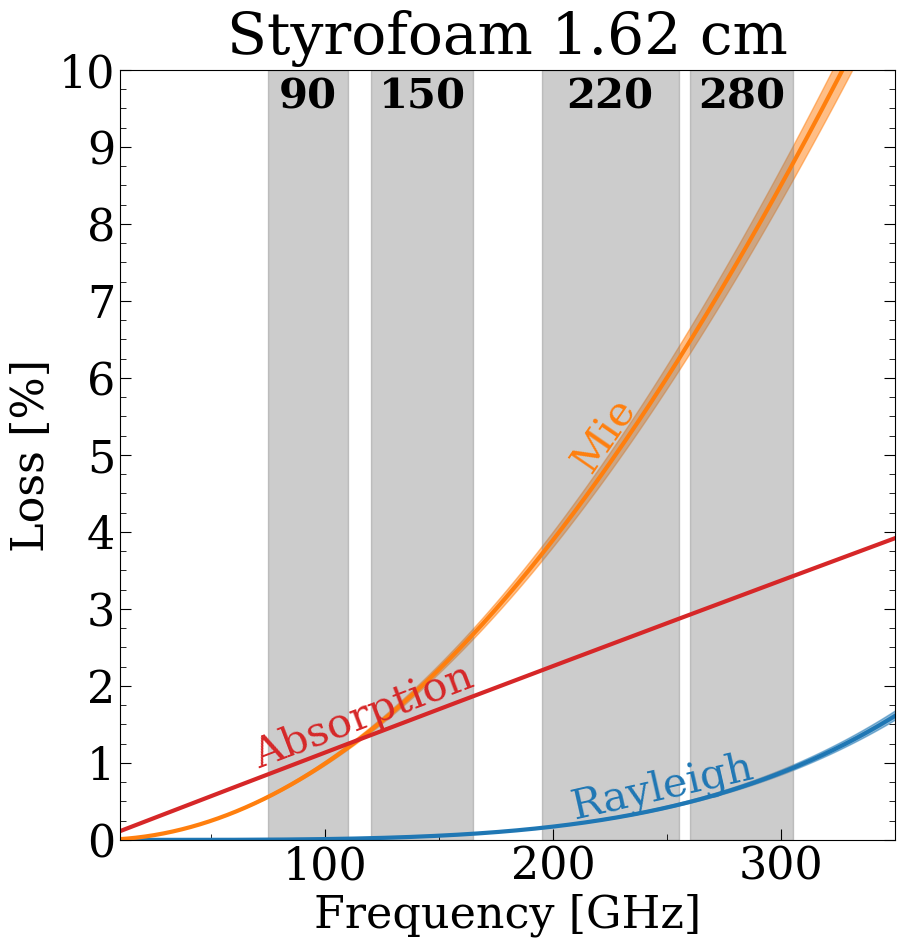

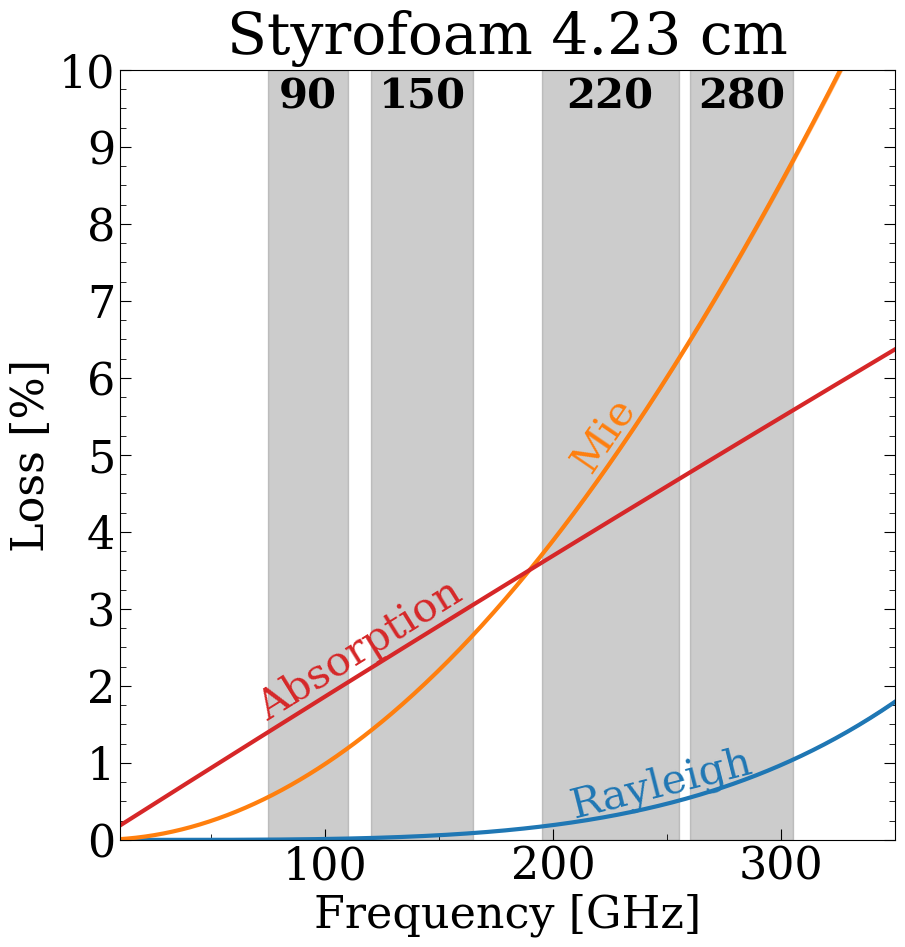

In [88]:
bname = 'Styrofoam_batch'
b = batches[bname]

for sample in b:

    plt.figure(figsize=(10, 10), dpi=100)

    plt.xlim(10, 350)
    plt.ylim(0, 10)

    Abs, Abs_upper, Abs_lower, Abs_color, _ = b[sample]["estimates"]["Abs"].values()
    Ray, Ray_upper, Ray_lower, Ray_color, _ = b[sample]["estimates"]["Ray"].values()
    Mie, Mie_upper, Mie_lower, Mie_color, _ = b[sample]["estimates"]["Mie"].values()

    plt.plot(f, Ray, color=Ray_color, lw=3,  zorder=2)
    plt.plot(f, Mie, color=Mie_color, lw=3, zorder=2)
    plt.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, alpha=0.5, zorder=0)
    plt.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, alpha=0.5, zorder=0)

    plt.plot(f, Abs, color=Abs_color, lw=3, zorder=2)

    fig.canvas.draw()
    for freq, arr, label, color in [
        (230, Mie, 'Mie', Mie_color),
        (250, Ray, 'Rayleigh', Ray_color),
        (120, Abs, 'Absorption', Abs_color)
    ]:
        idx = np.argmin(np.abs(f - freq))
        p0 = plt.gca().transData.transform((f[idx-10], arr[idx-10]))
        p1 = plt.gca().transData.transform((f[idx+10], arr[idx+10]))
        angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
        plt.text(f[idx], arr[idx], label, color=color, fontsize=30,
                    ha='center', va='bottom', rotation=angle, rotation_mode='anchor')
        
        plt.gca().yaxis.set_major_locator(MultipleLocator(1))
        plt.gca().yaxis.set_minor_locator(MultipleLocator(0.25))
        plt.gca().xaxis.set_major_locator(MultipleLocator(100))
        plt.gca().xaxis.set_minor_locator(MultipleLocator(50))
        plt.tick_params(axis='both', which='major', labelsize=32)
        plt.tick_params(axis='y', which='both', left=True, right=True)
        
    for band, (lbound, ubound) in band_windows_full.items():
        if band not in ["90", "150", "220", "280"]:
            continue
        band_center = (lbound + ubound) / 2
        plt.text(band_center, 0.99*plt.gca().get_ylim()[1], band, color='k', ha='center', va='top', fontsize=30, fontweight='bold')
        plt.gca().axvspan(lbound, ubound, alpha=0.4, color='gray', zorder=0)

    plt.xlabel('Frequency [GHz]', fontsize=32)
    plt.ylabel('Loss [%]', fontsize=32)

    plt.title(sample, y=1.01, fontsize=42)
    plt.show()

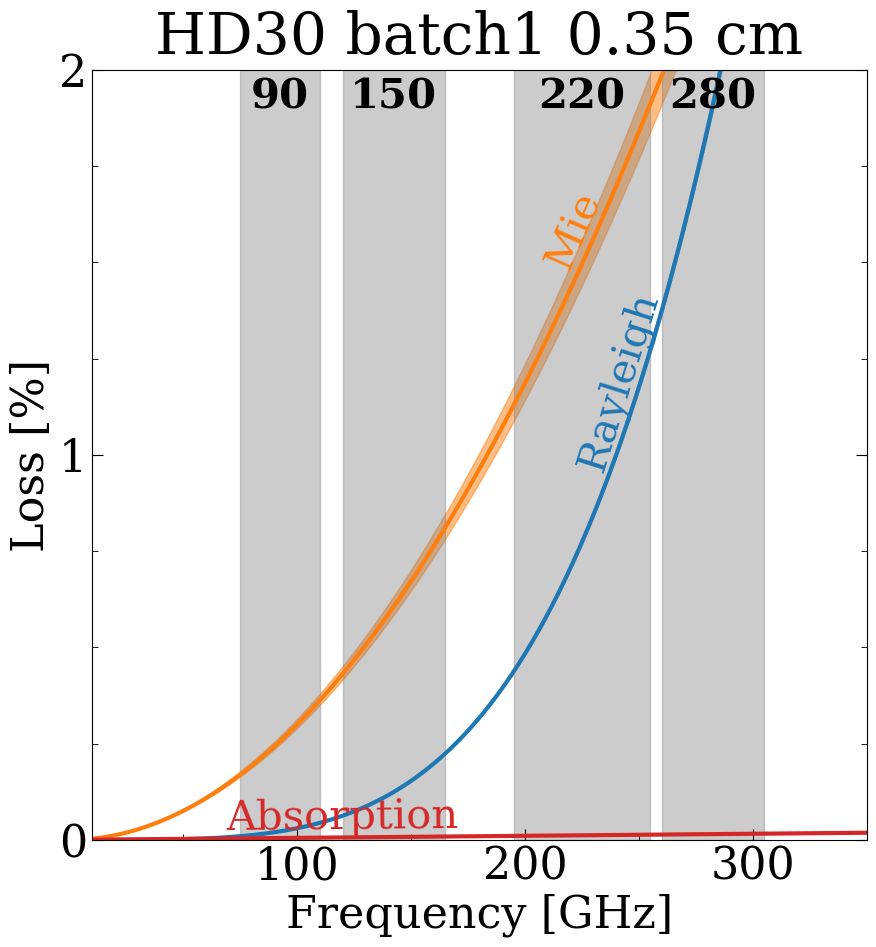

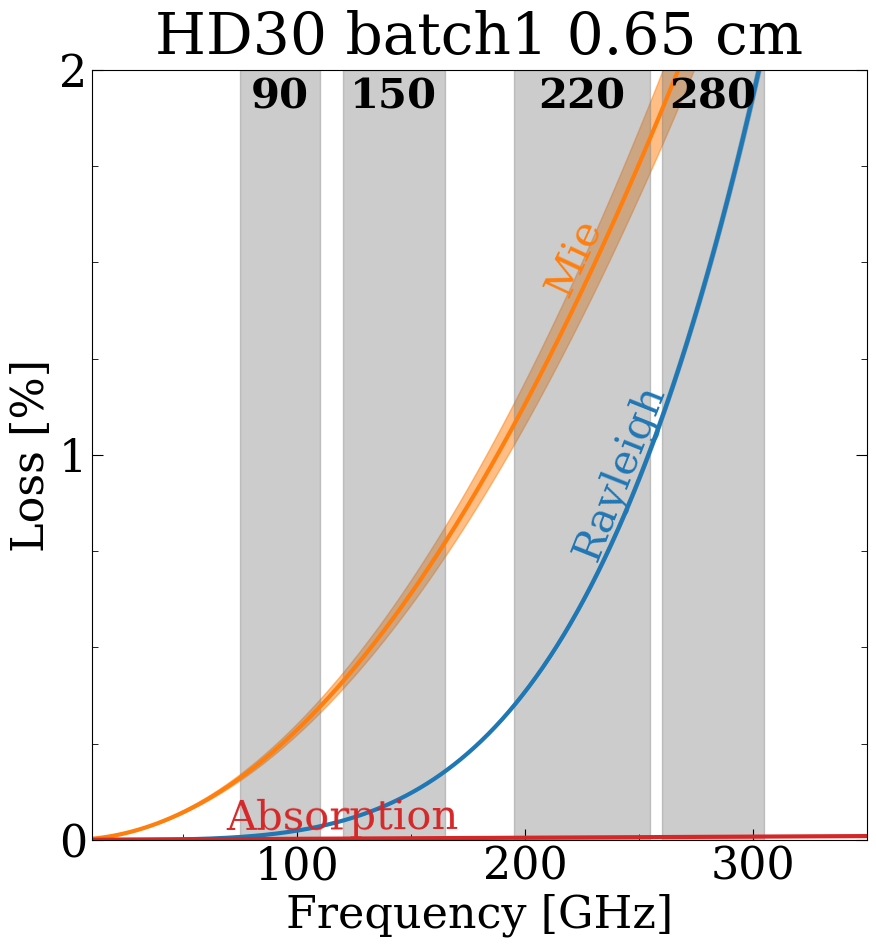

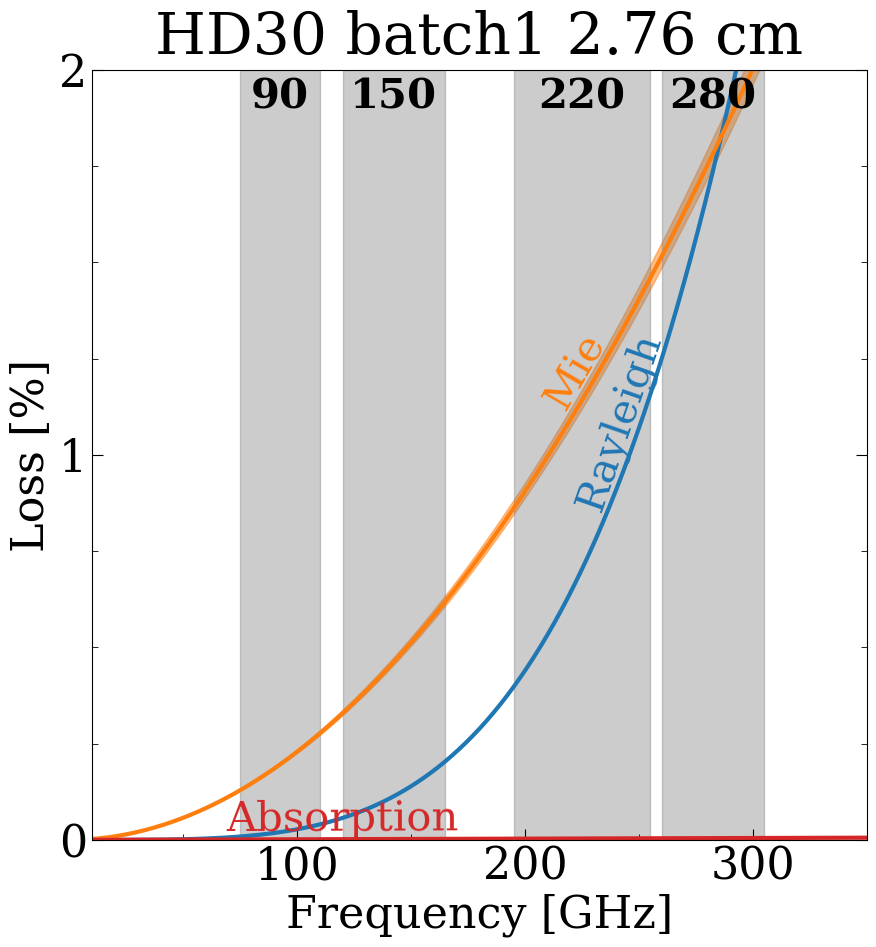

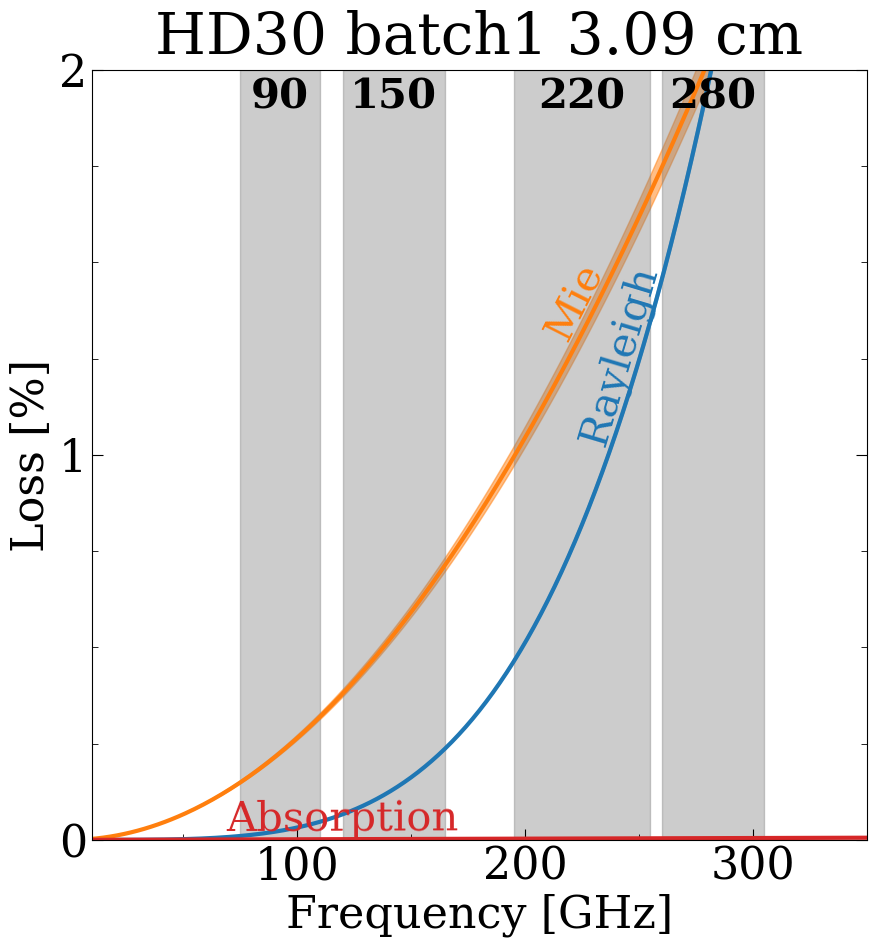

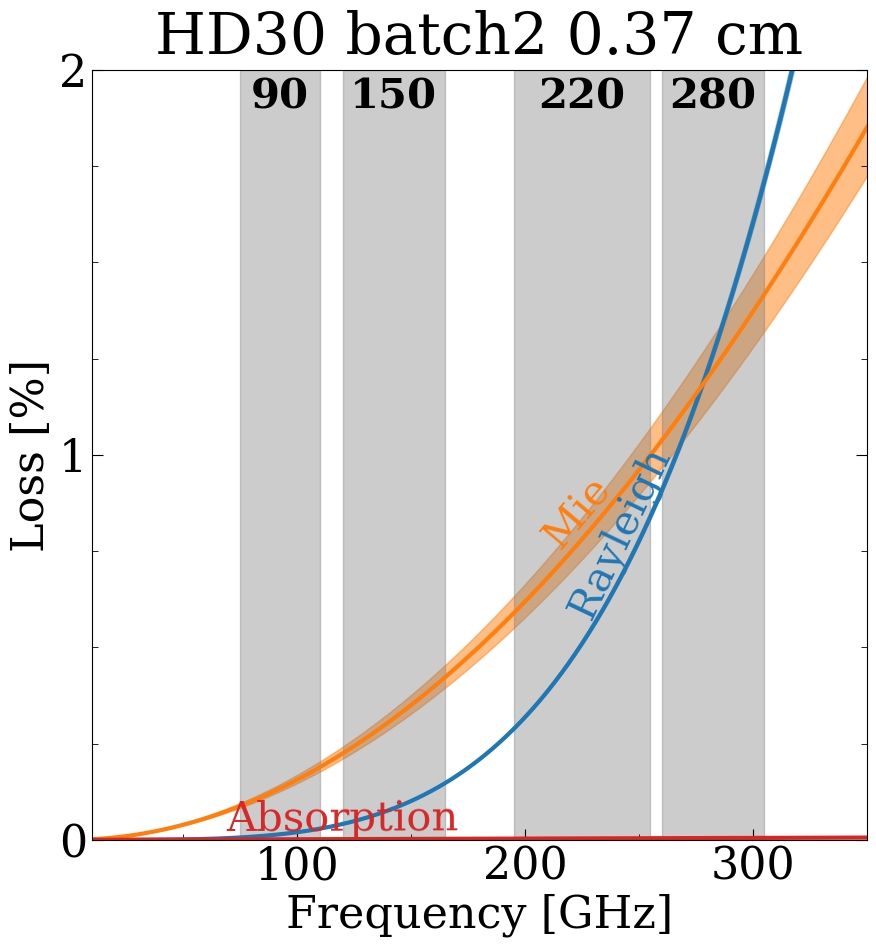

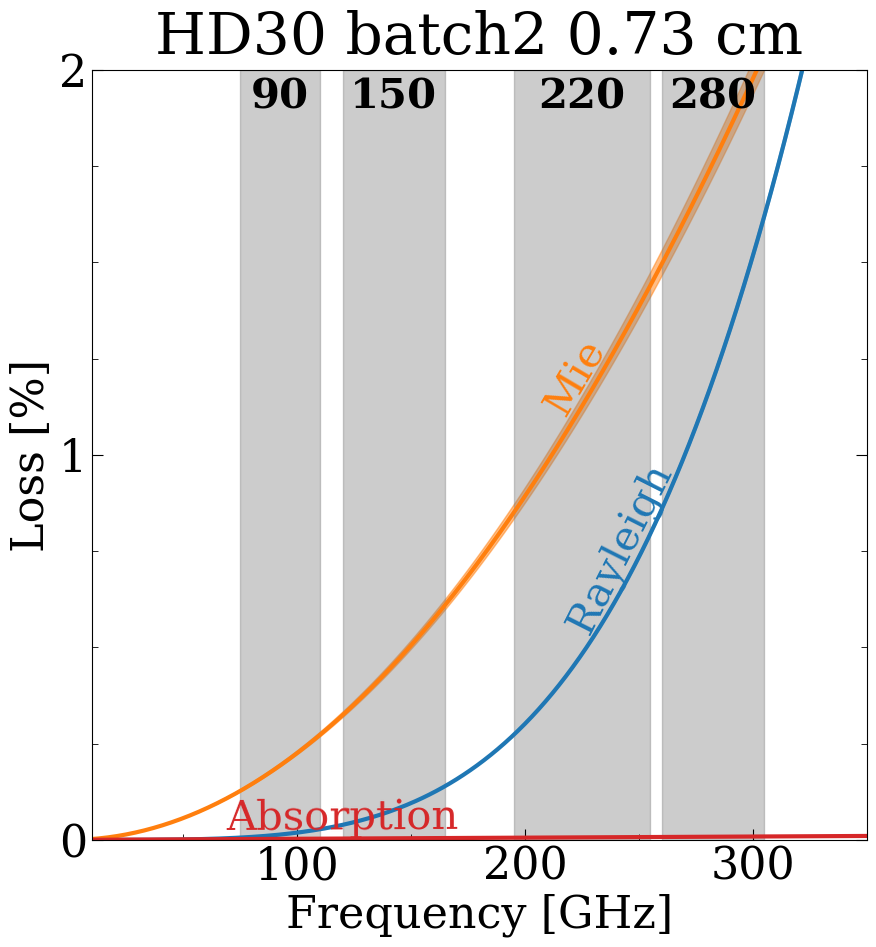

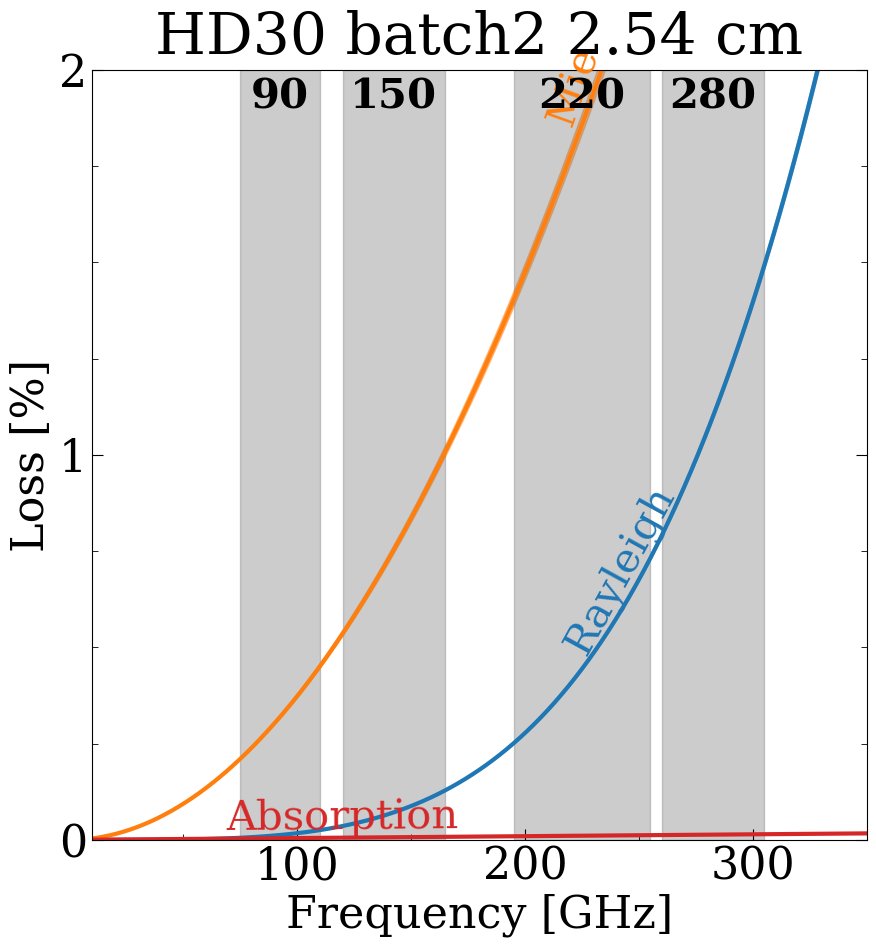

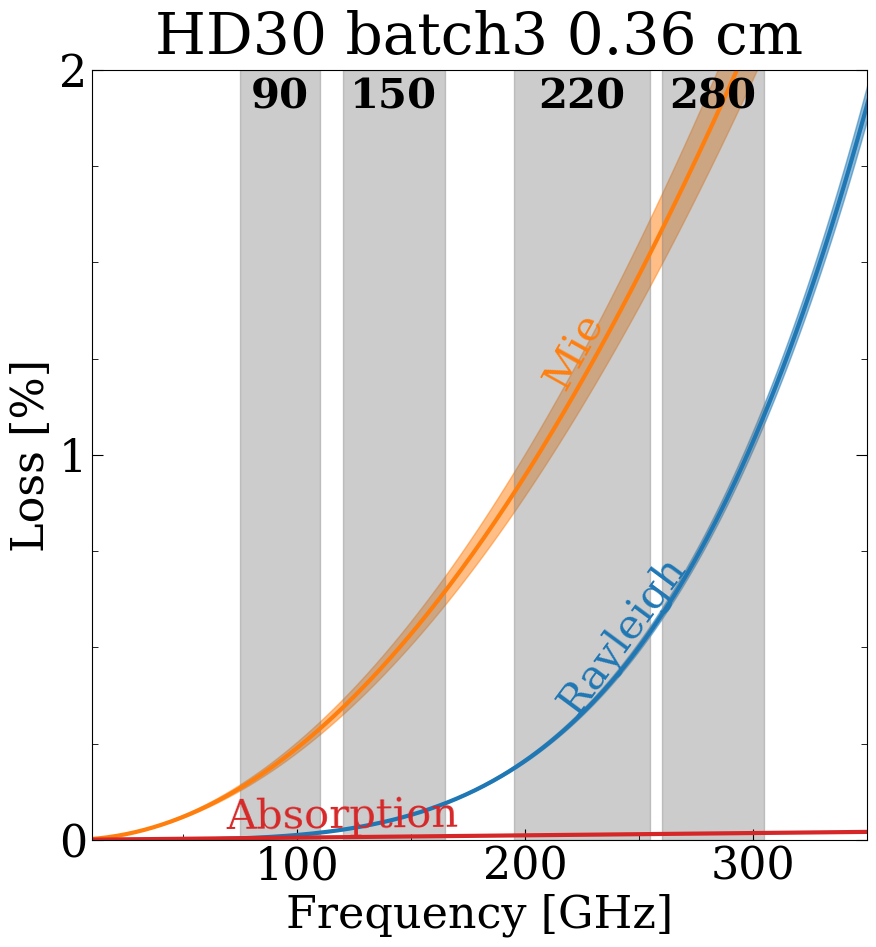

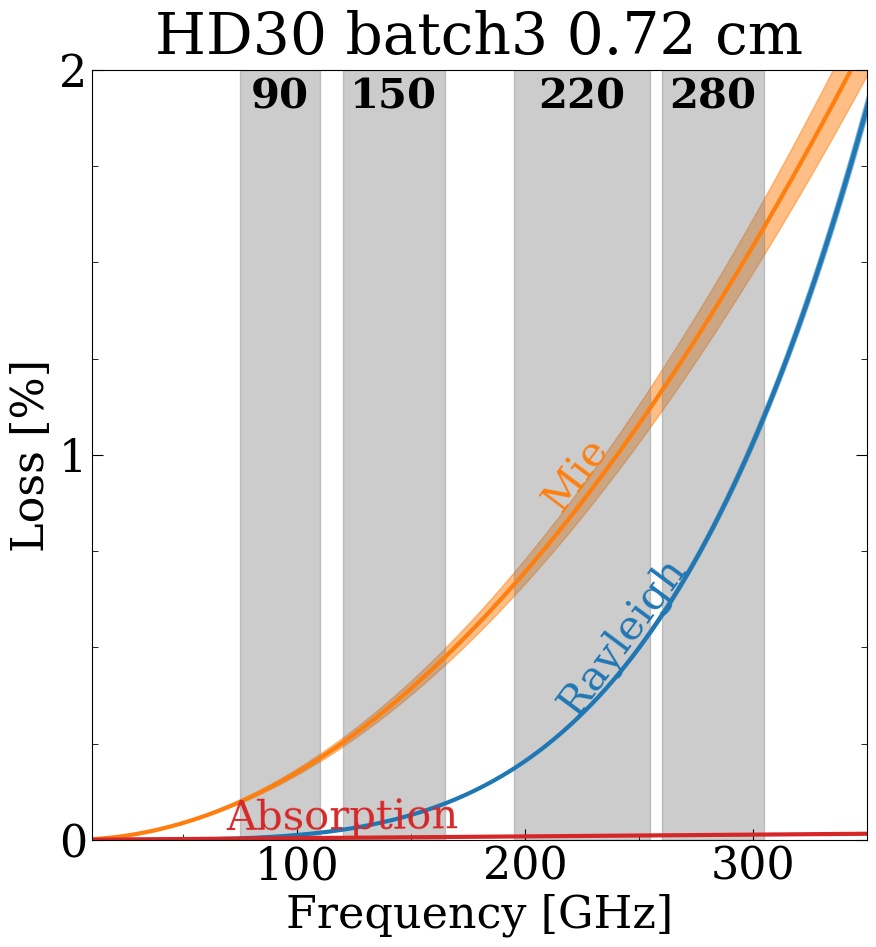

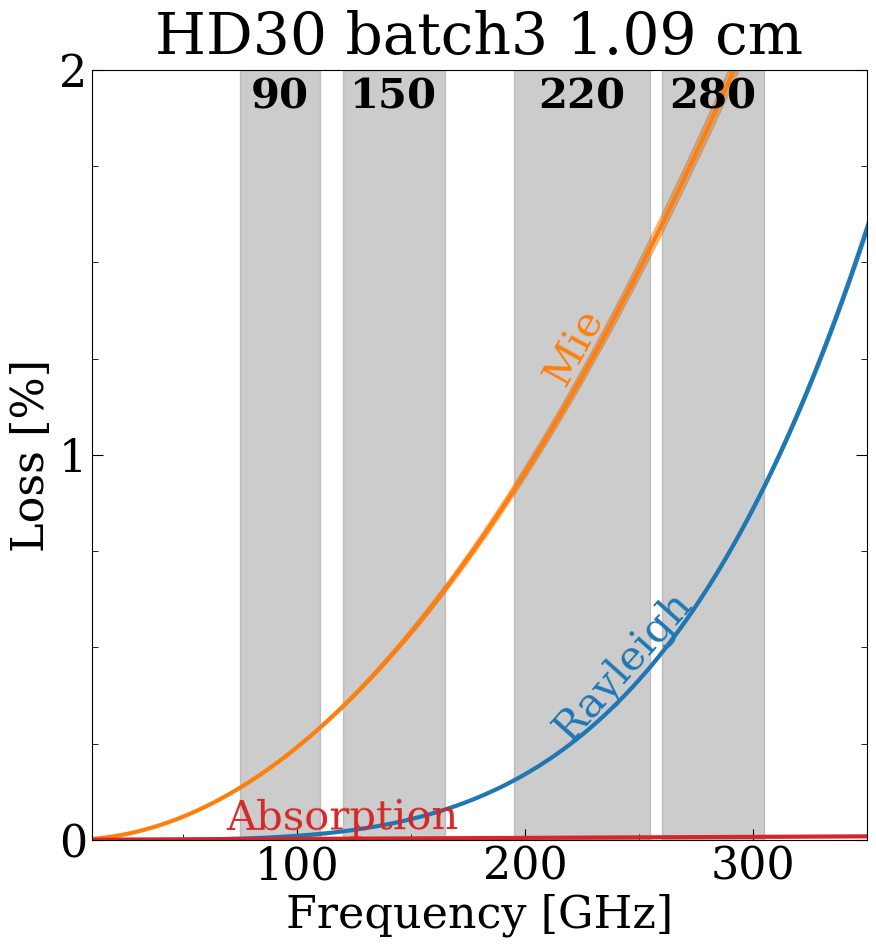

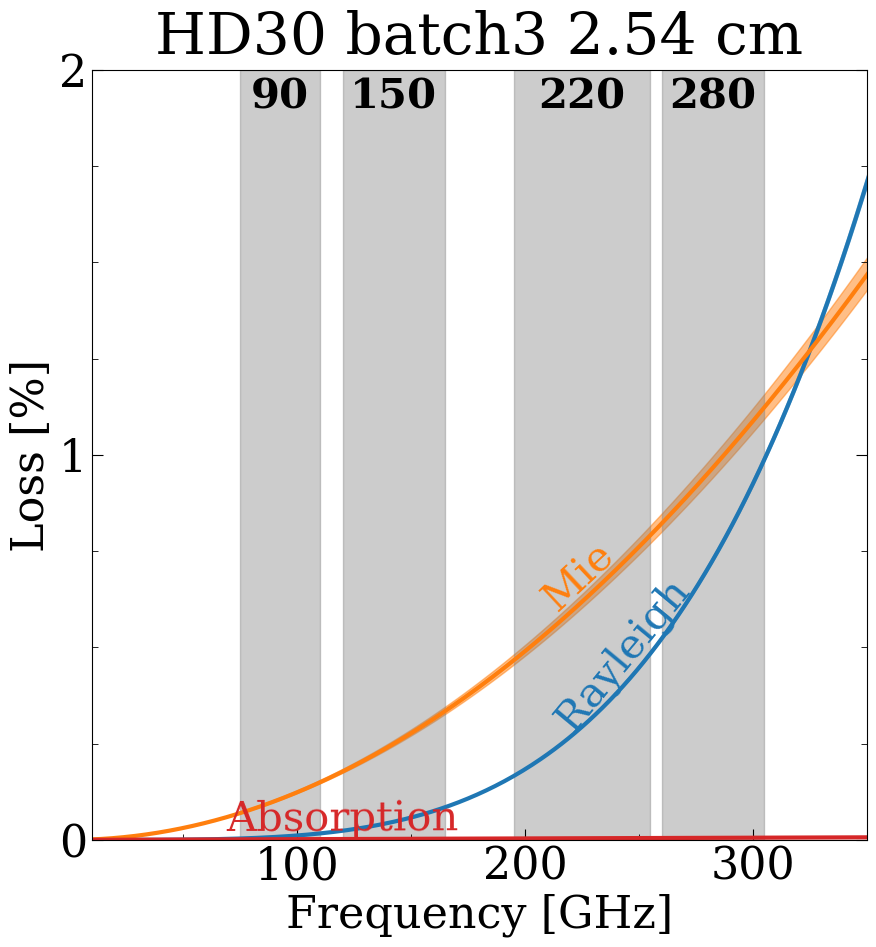

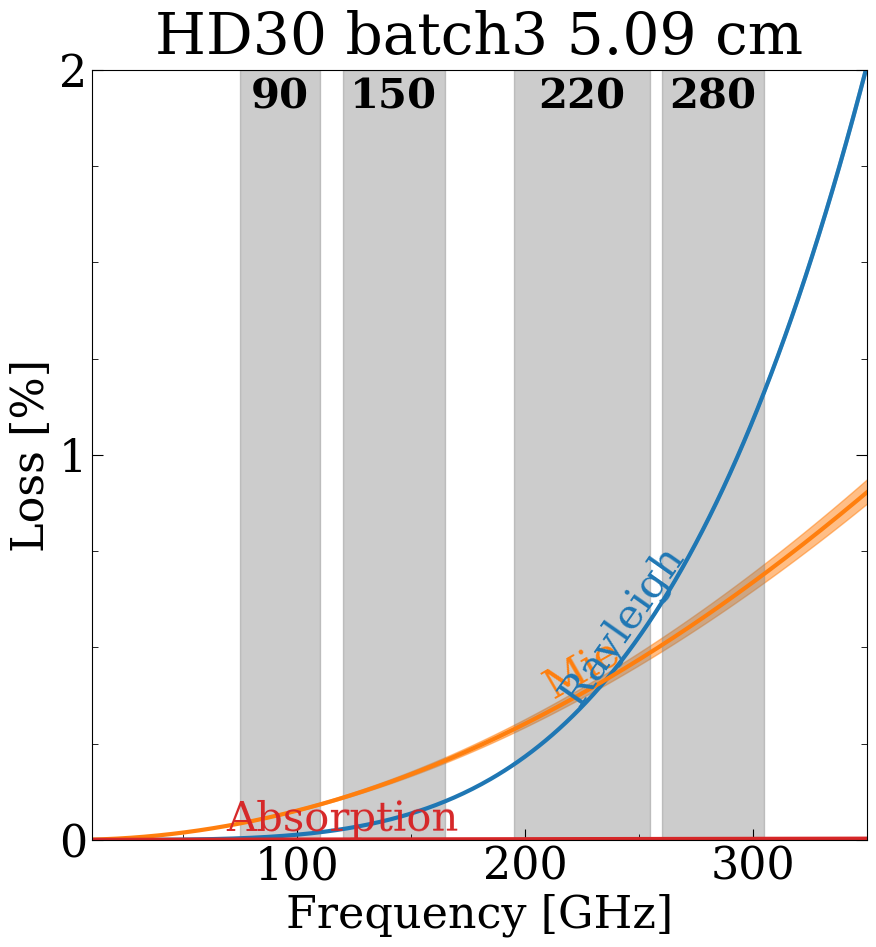

In [89]:
for bname, b in batches.items():
    if bname not in HD30_batches:
        continue

    for sample in b:

        plt.figure(figsize=(10, 10), dpi=100)

        plt.xlim(10, 350)
        plt.ylim(0, 2)

        Abs, Abs_upper, Abs_lower, Abs_color, _ = b[sample]["estimates"]["Abs"].values()
        Ray, Ray_upper, Ray_lower, Ray_color, _ = b[sample]["estimates"]["Ray"].values()
        Mie, Mie_upper, Mie_lower, Mie_color, _ = b[sample]["estimates"]["Mie"].values()

        plt.plot(f, Ray, color=Ray_color, lw=3,  zorder=2)
        plt.plot(f, Mie, color=Mie_color, lw=3, zorder=2)
        plt.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, alpha=0.5, zorder=0)
        plt.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, alpha=0.5, zorder=0)

        plt.plot(f, Abs, color=Abs_color, lw=3, zorder=2)

        fig.canvas.draw()
        for freq, arr, label, color in [
            (230, Mie, 'Mie', Mie_color),
            (250, Ray, 'Rayleigh', Ray_color),
            (120, Abs, 'Absorption', Abs_color)
        ]:
            idx = np.argmin(np.abs(f - freq))
            p0 = plt.gca().transData.transform((f[idx-10], arr[idx-10]))
            p1 = plt.gca().transData.transform((f[idx+10], arr[idx+10]))
            angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
            plt.text(f[idx], arr[idx], label, color=color, fontsize=30,
                        ha='center', va='bottom', rotation=angle, rotation_mode='anchor')
            
            plt.gca().yaxis.set_major_locator(MultipleLocator(1))
            plt.gca().yaxis.set_minor_locator(MultipleLocator(0.25))
            plt.gca().xaxis.set_major_locator(MultipleLocator(100))
            plt.gca().xaxis.set_minor_locator(MultipleLocator(50))
            plt.tick_params(axis='both', which='major', labelsize=32)
            plt.tick_params(axis='y', which='both', left=True, right=True)
            
        for band, (lbound, ubound) in band_windows_full.items():
            if band not in ["90", "150", "220", "280"]:
                continue
            band_center = (lbound + ubound) / 2
            plt.text(band_center, 0.99*plt.gca().get_ylim()[1], band, color='k', ha='center', va='top', fontsize=30, fontweight='bold')
            plt.gca().axvspan(lbound, ubound, alpha=0.4, color='gray', zorder=0)

        plt.xlabel('Frequency [GHz]', fontsize=32)
        plt.ylabel('Loss [%]', fontsize=32)

        plt.title(sample, y=1.01, fontsize=42)
        plt.show()

In [90]:
# from matplotlib.patches import ConnectionPatch

# fig, axes = plt.subplots(2, 2, figsize=(22, 22), sharex=True)
# ax0, ax1, ax2, ax3 = axes.flatten()

# for ax in axes.flatten():
#     ax.set_rasterization_zorder(1)

# ## Styrofoam Batches

# bname = 'Styrofoam_batch'
# b = comb_batches[bname]

# ax0.set_xlim(10, 350)
# ax0.set_ylim(0, 10)

# Abs, Abs_upper, Abs_lower, Abs_color, _ = b["estimates"]["Abs"].values()
# Ray, Ray_upper, Ray_lower, Ray_color, _ = b["estimates"]["Ray"].values()
# Mie, Mie_upper, Mie_lower, Mie_color, _ = b["estimates"]["Mie"].values()

# ax0.plot(f, Ray, color=Ray_color, lw=3,  zorder=2)
# ax0.plot(f, Mie, color=Mie_color, lw=3, zorder=2)
# ax0.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, alpha=0.5, zorder=0)
# ax0.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, alpha=0.5, zorder=0)

# ax0.plot(f, Abs, color=Abs_color, lw=3, zorder=2)

# fig.canvas.draw()
# for freq, arr, label, color in [
#     (230, Mie, 'Mie', Mie_color),
#     (250, Ray, 'Rayleigh', Ray_color),
#     (120, Abs, 'Absorption estimate', Abs_color)
# ]:
#     idx = np.argmin(np.abs(f - freq))
#     p0 = ax0.transData.transform((f[idx-10], arr[idx-10]))
#     p1 = ax0.transData.transform((f[idx+10], arr[idx+10]))
#     angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
#     ax0.text(f[idx], arr[idx], label, color=color, fontsize=30,
#                 ha='center', va='bottom', rotation=angle, rotation_mode='anchor')

# ax0.set_title('Styrofoam', y=1.01, fontsize=42)

# ## HD30 Batches
# j = 0
# linestyles = ['--', '-']

# for bname, b in comb_batches.items():
#     if bname not in ['HD30_batch1', 'HD30_batch3']:
#         continue
#     batch_num = bname.split('_')[-1][-1]

#     ax1.set_xlim(10, 350)
#     ax1.set_ylim(0, 2)

#     Abs, Abs_upper, Abs_lower, Abs_color, _ = b["estimates"]["Abs"].values()
#     Ray, Ray_upper, Ray_lower, Ray_color, _ = b["estimates"]["Ray"].values()
#     Mie, Mie_upper, Mie_lower, Mie_color, _ = b["estimates"]["Mie"].values()

#     ax1.plot(f, Ray, color=Ray_color, lw=3, ls=linestyles[j], zorder=2)
#     ax1.plot(f, Mie, color=Mie_color, lw=3, ls=linestyles[j], zorder=2)
#     ax1.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, alpha=0.5, zorder=0)
#     ax1.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, alpha=0.5, zorder=0)

#     if j == 0:
#         ax1.plot(f, Abs, color=Abs_color, lw=3, zorder=2)

#     fig.canvas.draw()

#     if j == 1:
#         idx = np.argmin(np.abs(f - 295))
#         p0 = ax1.transData.transform((f[idx-10], Mie[idx-10]))
#         p1 = ax1.transData.transform((f[idx+10], Mie[idx+10]))
#         angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
#         ax1.text(f[idx], Mie[idx], f"Mie - batch {batch_num}", color=Mie_color, fontsize=30,
#                 ha='center', va='top', rotation=angle, rotation_mode='anchor')
        
#         idx = np.argmin(np.abs(f - 300))
#         p0 = ax1.transData.transform((f[idx-10], Ray[idx-10]))
#         p1 = ax1.transData.transform((f[idx+10], Ray[idx+10]))
#         angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
#         ax1.text(f[idx], Ray[idx], "Rayleigh", color=Ray_color, fontsize=30,
#                  ha='center', va='bottom', rotation=angle, rotation_mode='anchor')

#         idx = np.argmin(np.abs(f - 250))
#         p0 = ax1.transData.transform((f[idx-10], Abs[idx-10]))
#         p1 = ax1.transData.transform((f[idx+10], Abs[idx+10]))
#         angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
#         ax1.text(f[idx], Abs[idx], "Absorption estimate", color=Abs_color, fontsize=30,
#                  ha='center', va='bottom', rotation=angle, rotation_mode='anchor')
#     else:
#         idx = np.argmin(np.abs(f - 175))
#         p0 = ax1.transData.transform((f[idx-10], Mie[idx-10]))
#         p1 = ax1.transData.transform((f[idx+10], Mie[idx+10]))
#         angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
#         ax1.text(f[idx], Mie[idx], f"Mie - batch {batch_num}", color=Mie_color, fontsize=30,
#              ha='center', va='bottom', rotation=angle, rotation_mode='anchor')
        
#     j += 1

# ax1.set_title('HD30', y=1.01, fontsize=42)

# ## LD24
# bname = 'LD24 batch1 2.60 cm'
# b = comb_batches[bname]
# display_name = DISPLAY_MAP.get(bname, bname)

# ax2.set_xlim(10, 350)
# ax2.set_ylim(0, 2)

# Abs, Abs_upper, Abs_lower, Abs_color, Abs_ls  = b["estimates"]["Abs"].values()
# Ray, Ray_upper, Ray_lower, Ray_color, Ray_ls  = b["estimates"]["Ray"].values()
# Mie, Mie_upper, Mie_lower, Mie_color, Mie_ls  = b["estimates"]["Mie"].values()

# ax2.plot(f, Ray, color=Ray_color, lw=3, linestyle=linestyles[0], zorder=2)
# ax2.plot(f, Mie, color=Mie_color, lw=3, linestyle=linestyles[0], zorder=2)
# ax2.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, edgecolor='none', alpha=0.5, zorder=0)
# ax2.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, edgecolor='none', alpha=0.5, zorder=0)

# fig.canvas.draw()
# for freq, arr, label, color, fs, va in [
#     (175, Mie, 'Mie - batch 1',       Mie_color, 30, 'bottom'),
#     (300, Ray, 'Rayleigh',            Ray_color, 30, 'bottom'),
#     (250, Abs, 'Absorption estimate', Abs_color, 30, 'bottom'),
# ]:
#     idx = np.argmin(np.abs(f - freq))
#     p0 = ax2.transData.transform((f[idx-10], arr[idx-10]))
#     p1 = ax2.transData.transform((f[idx+10], arr[idx+10]))
#     angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
#     ax2.text(freq, arr[idx], label, color=color, fontsize=fs, ha='center', va=va, rotation=angle, rotation_mode='anchor')

# ax2.set_title(bname.split()[0], y=1.01, fontsize=42)

# bname = 'LD24 batch2 0.34 cm'
# b = comb_batches[bname]
# display_name = DISPLAY_MAP.get(bname, bname)

# Abs, Abs_upper, Abs_lower, Abs_color, Abs_ls  = b["estimates"]["Abs"].values()
# Ray, Ray_upper, Ray_lower, Ray_color, Ray_ls  = b["estimates"]["Ray"].values()
# Mie, Mie_upper, Mie_lower, Mie_color, Mie_ls  = b["estimates"]["Mie"].values()

# ax2.plot(f, Abs, color=Abs_color, lw=5, linestyle=linestyles[1], zorder=2)
# ax2.plot(f, Ray, color=Ray_color, lw=3, linestyle=linestyles[1], zorder=2)
# ax2.plot(f, Mie, color=Mie_color, lw=3, linestyle=linestyles[1], zorder=2)
# ax2.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, edgecolor='none', alpha=0.5, zorder=0)
# ax2.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, edgecolor='none', alpha=0.5, zorder=0)

# fig.canvas.draw()
# for freq, arr, label, color, fs, va in [(175, Mie, 'Mie - batch 2', Mie_color, 30, 'top')]:
#     idx = np.argmin(np.abs(f - freq))
#     p0 = ax2.transData.transform((f[idx-10], arr[idx-10]))
#     p1 = ax2.transData.transform((f[idx+10], arr[idx+10]))
#     angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
#     ax2.text(freq, arr[idx], label, color=color, fontsize=fs, ha='center', va=va, rotation=angle, rotation_mode='anchor')

# ## LD15
# bname = 'LD15 batch1 2.65 cm'
# b = comb_batches[bname]

# ax3.set_xlim(10, 350)
# ax3.set_ylim(0, 2.5)

# Abs, Abs_upper, Abs_lower, Abs_color, Abs_ls  = b["estimates"]["Abs"].values()
# Ray, Ray_upper, Ray_lower, Ray_color, Ray_ls  = b["estimates"]["Ray"].values()
# Mie, Mie_upper, Mie_lower, Mie_color, Mie_ls  = b["estimates"]["Mie"].values()

# ax3.plot(f, Abs, color=Abs_color, lw=5, linestyle=linestyles[1], zorder=2)
# ax3.plot(f, Ray, color=Ray_color, lw=3, linestyle=linestyles[1], zorder=2)
# ax3.plot(f, Mie, color=Mie_color, lw=3, linestyle=linestyles[1], zorder=2)
# ax3.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, edgecolor='none', alpha=0.5, zorder=0)
# ax3.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, edgecolor='none', alpha=0.5, zorder=0)

# fig.canvas.draw()
# for freq, arr, label, color, fs, va in [
#     (175, Mie, 'Mie - batch 1',       Mie_color, 30, 'bottom'),
#     (300, Ray, 'Rayleigh',            Ray_color, 30, 'bottom'),
#     (250, Abs, 'Absorption estimate', Abs_color, 30, 'bottom'),
# ]:
#     idx = np.argmin(np.abs(f - freq))
#     p0 = ax3.transData.transform((f[idx-10], arr[idx-10]))
#     p1 = ax3.transData.transform((f[idx+10], arr[idx+10]))
#     angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
#     ax3.text(freq, arr[idx], label, color=color, fontsize=fs, ha='center', va=va, rotation=angle, rotation_mode='anchor', zorder=10)


# bname = 'LD15 batch2 0.30 cm'
# b = comb_batches[bname]

# Abs, Abs_upper, Abs_lower, Abs_color, Abs_ls  = b["estimates"]["Abs"].values()
# Ray, Ray_upper, Ray_lower, Ray_color, Ray_ls  = b["estimates"]["Ray"].values()
# Mie, Mie_upper, Mie_lower, Mie_color, Mie_ls  = b["estimates"]["Mie"].values()

# ax3.plot(f, Ray, color=Ray_color, lw=3, linestyle=linestyles[0], zorder=2)
# ax3.plot(f, Mie, color=Mie_color, lw=3, linestyle=linestyles[0], zorder=2)
# ax3.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, edgecolor='none', alpha=0.5, zorder=0)
# ax3.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, edgecolor='none', alpha=0.5, zorder=0)

# fig.canvas.draw()
# for freq, arr, label, color, fs, va in [(175, Mie, 'Mie - batch 2', Mie_color, 30, 'bottom'),
# ]:
#     idx = np.argmin(np.abs(f - freq))
#     p0 = ax3.transData.transform((f[idx-10], arr[idx-10]))
#     p1 = ax3.transData.transform((f[idx+10], arr[idx+10]))
#     angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
#     ax3.text(freq, arr[idx], label, color=color, fontsize=fs, ha='center', va=va, rotation=angle, rotation_mode='anchor', zorder=10)

# ax3.set_title(bname.split()[0], y=1.01, fontsize=42)

# ## General
# for ax in axes.flatten():
#     ax.yaxis.set_major_locator(MultipleLocator(1))
#     ax.yaxis.set_minor_locator(MultipleLocator(0.25))
#     ax.xaxis.set_major_locator(MultipleLocator(100))
#     ax.xaxis.set_minor_locator(MultipleLocator(50))
#     ax.tick_params(axis='both', which='major', labelsize=32)
#     ax.tick_params(axis='y', which='both', left=True, right=True)
#     for band, (lbound, ubound) in band_windows_full.items():
#         if band not in ["90", "150", "220", "280"]:
#             continue
#         band_center = (lbound + ubound) / 2
#         ax.text(band_center, 0.99*ax.get_ylim()[1], band, color='k', ha='center', va='top', fontsize=30, fontweight='bold')
#         ax.axvspan(lbound, ubound, alpha=0.4, color='gray', zorder=0)

# fig.supxlabel('Frequency [GHz]', fontsize=42, y=0.06)
# fig.supylabel('Loss [%]', fontsize=42, x=0.06)
# plt.subplots_adjust(hspace=0.12, wspace=0.12)

# con = ConnectionPatch(
#     xyA=(0, 2), coordsA=ax1.get_yaxis_transform(),
#     xyB=(1, 2), coordsB=ax0.get_yaxis_transform(),
#     color="k", linewidth=1
# )
# fig.add_artist(con)

# plt.gcf().set_facecolor('white')
# plt.savefig('components.pdf', bbox_inches='tight', facecolor='white')
# plt.show()

In [91]:
# Ray1 = next(iter(comb_batches['HD30_batch1']["estimates"]["Ray"].values()))
# Ray2 = next(iter(comb_batches['HD30_batch2']["estimates"]["Ray"].values()))
# Ray3 = next(iter(comb_batches['HD30_batch3']["estimates"]["Ray"].values()))

# Mie1 = next(iter(comb_batches['HD30_batch1']["estimates"]["Mie"].values()))
# Mie2 = next(iter(comb_batches['HD30_batch2']["estimates"]["Mie"].values()))
# Mie3 = next(iter(comb_batches['HD30_batch3']["estimates"]["Mie"].values()))

# Rays = np.array([Ray1, Ray2, Ray3])
# Mies = np.array([Mie1, Mie2, Mie3])

# idx = np.argmin(np.abs(f - 280))
# min_key = np.argmin(Rays[:, idx])
# max_key = np.argmax(Rays[:, idx])

# min_sigma = (comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Ray"]['upper'][idx] - comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Ray"]['lower'][idx]) / 2
# max_sigma = (comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Ray"]['upper'][idx] - comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Ray"]['lower'][idx]) / 2

# print(f"At 280 GHz, min Rayleigh is Batch {min_key+1} with value {Rays[min_key, idx]:.4f} ± {min_sigma:.4f}, max Rayleigh is Batch {max_key+1} with value {Rays[max_key, idx]:.4f} ± {max_sigma:.4f}, difference: {(Rays[max_key, idx] - Rays[min_key, idx]):.4f} ± {(min_sigma**2 + max_sigma**2)**0.5:.4f}")
      
# min_key = np.argmin(Mies[:, idx])
# max_key = np.argmax(Mies[:, idx])

# min_sigma = (comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Mie"]['upper'][idx] - comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Mie"]['lower'][idx]) / 2
# max_sigma = (comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Mie"]['upper'][idx] - comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Mie"]['lower'][idx]) / 2

# print(f"At 280 GHz, min Mie is Batch {min_key+1} with value {Mies[min_key, idx]:.4f} ± {min_sigma:.4f}, max Mie is Batch {max_key+1} with value {Mies[max_key, idx]:.4f} ± {max_sigma:.4f}, difference: {(Mies[max_key, idx] - Mies[min_key, idx]):.4f} ± {(min_sigma**2 + max_sigma**2)**0.5:.4f}")